In [49]:
# ============== Standard library ==============
import os
import re
# ============== Core scientific stack ==============
import numpy as np
import pandas as pd
from pyproj import Geod
import seaborn as sns
# ============== Matplotlib ==============

# Matplotlib extras
import matplotlib.colors as mcolors
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize, PowerNorm, TwoSlopeNorm, LogNorm

# ============== Geo stack ==============
import geopandas as gpd
import osmnx as ox

# ============== SciPy ==============
from scipy.stats import chi2_contingency, spearmanr, pearsonr

# ============== scikit-learn ==============
# Models / estimators
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
# Pipelines & utilities
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler


# Model selection
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import classification_report

# ============== imbalanced-learn ==============
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

# ============== Statistical modeling additions ==============
import statsmodels.api as sm
from scipy.stats import kruskal
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [50]:
# =========================
# CONFIG
# =========================
# Load the updated dataset 
from sre_parse import CATEGORIES


file_path = "All CGs IL - Final.csv"

FILE_GINOT = "All CGs IL - Final.csv"
ginot = pd.read_csv(FILE_GINOT, encoding="utf-8-sig")
# Clean column names
ginot.columns = ginot.columns.str.strip()

print("Loaded ginot shape:", ginot.shape)
print(ginot.columns.tolist())
# merged file already includes the city-level columns

# --- Columns (all lower-case, after .str.lower()/.str.strip()) ---
CITY = "city"
ID_GINA = "id_gina"
CAT_SPECIAL_LOCATION = "cat_special_location"
FUNDING_CATEGORIES = "funding_categories"
N_CATEGORIES_FUNDING = "num_cat of funding"
N_VISITORS_PER_YEAR = "num_visitors_per_year"
N_ACTIVE_MEMBERS = "num_activ_members"
ACTIVITY = "activity (years)"
SPECIAL_COMMUNITY = "special community (yes/no)"
GARDENTYPE_GREEN = "gardentype"
SEI_GAP = "sei gap"
CITY_AVG_ESHKOL_2021 = "city avg sei 2021"
ESHKOL_2021 = "sei_neighb"
LON_WGS84 = "x_longitude by wgs84"
LAT_WGS84 = "y_latitude by wgs84"
AREA_KM2 = "city area (km2)"
GREEN_AREAS_KM2 = "green areas gis (km2)"
SAT_PARKS_PCT = "satisfaction with parks and green spaces in the residential area %"
CATEGORIES_COMMUNITIES = "categories of the community"
POP_2023 = "city population"

# --- Output folder for figures (set "" to save in project root) ---
FIG_DIR = "output_CGs"
if FIG_DIR:
    os.makedirs(FIG_DIR, exist_ok=True)

def fig_path(filename):
    return os.path.join(FIG_DIR, filename) if FIG_DIR else filename
# merged file already includes the city-level columns

# --- Columns (all lower-case, after .str.lower()/.str.strip()) ---
CITY = "city"
ID_GINA = "id_gina"
CAT_SPECIAL_LOCATION = "cat_special_location"
FUNDING_CATEGORIES = "funding_categories"
N_CATEGORIES_FUNDING = "num_cat of funding"
N_VISITORS_PER_YEAR = "num_visitors_per_year"
N_ACTIVE_MEMBERS = "num_activ_members"
ACTIVITY = "activity (years)"
# Column name used throughout the notebook
SPECIAL_COMMUNITY = "special community (yes/no)"

class SpecialCommunity:
    """Utilities for validating and filtering the special-community field."""

    VALID_VALUES = {"yes", "no"}

    @classmethod
    def normalize(cls, series):
        """Return a normalized yes/no Series."""
        return (
            series.astype("string")
            .str.strip()
            .str.lower()
            .replace({"y": "yes", "n": "no", "true": "yes", "false": "no"})
        )

    @classmethod
    def is_valid(cls, series):
        """Return a boolean mask for valid values."""
        return cls.normalize(series).isin(cls.VALID_VALUES)

    @classmethod
    def filter(cls, dataframe, value="yes"):
        """Return rows matching the requested value."""
        value = str(value).strip().lower()
        if value not in cls.VALID_VALUES:
            raise ValueError(f"value must be one of {sorted(cls.VALID_VALUES)}")

        result = dataframe.copy()
        result[SPECIAL_COMMUNITY] = cls.normalize(result[SPECIAL_COMMUNITY])
        return result[result[SPECIAL_COMMUNITY].eq(value)]
GARDENTYPE_GREEN = "gardentype"
SEI_GAP = "sei gap"
CITY_AVG_ESHKOL_2021 = "city avg sei 2021"
ESHKOL_2021 = "sei_neighb"
LON_WGS84 = "x_longitude by wgs84"
LAT_WGS84 = "y_latitude by wgs84"
AREA_KM2 = "city area (km2)"
GREEN_AREAS_KM2 = "green areas gis (km2)"
SAT_PARKS_PCT = "satisfaction with parks and green spaces in the residential area %"
N_COMMUNITY_GARDENS = "num_community_gardens"
POP_2023 = "city population"

# --- Output folder for figures (set "" to save in project root) ---
FIG_DIR = "output_CGs"

if FIG_DIR:
    os.makedirs(FIG_DIR, exist_ok=True)

def fig_path(filename):
    return os.path.join(FIG_DIR, filename) if FIG_DIR else filename


Loaded ginot shape: (293, 37)
['Department responsible', "GIS's layer of CGs? Points/Polygon/Non", 'City Area (km2)', 'Density for km2', 'Green Areas GIS (Km2)', '# unites of green areas', 'Mean area', 'Satisfaction with parks and green spaces in the residential area %', 'Density in Built Area (Person per Km2)', 'Forest and Woodland (Km2)', 'Parks and gardens (Km2)', 'Culture, Leisure, Vacation, and Sport (Km2)', 'No. Pupils in the city', 'No of Schools in the city', 'Avg Salary', 'City Avg SEI 2021', 'City Population', 'City', 'ID_gina', 'Y_Latitude by WGS84', 'X_Longitude by WGS84', 'green_area_m2_400', 'count no. of green unites within 400m', 'Cat_Special_location', 'Activity (Years)', 'Num_activ_members', 'Num_visitors_per_year', 'area stat no. by lamas 2021', 'SEI_Neighb', 'SEI Gap', 'on_green', 'GARDENTYPE', 'walkable_length(m)_within_400m', 'Funding_Categories', 'Num_Cat of funding', 'Categories of the community', 'Special Community (Yes/No)']


In [51]:
ginot = pd.read_csv(FILE_GINOT)

# Convert column names to lowercase and remove accidental edge spaces
ginot.columns = ginot.columns.str.lower().str.strip()

# Backward compatibility for earlier files where X/Y were paired with the wrong coordinate names.
coordinate_column_renames = {
    "x_latitude by wgs84": LON_WGS84,
    "y_longitude by wgs84": LAT_WGS84,
}
ginot.rename(
    columns={
        old_col: new_col
        for old_col, new_col in coordinate_column_renames.items()
        if old_col in ginot.columns and new_col not in ginot.columns
    },
    inplace=True,
)

# Convert string values in all columns to lowercase
for col in ginot.select_dtypes(include='object').columns:
    ginot[col] = ginot[col].str.lower()

In [52]:
ginot.replace("no data", np.nan, inplace=True)
print(ginot.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 37 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   department responsible                                              292 non-null    object 
 1   gis's layer of cgs? points/polygon/non                              292 non-null    object 
 2   city area (km2)                                                     293 non-null    float64
 3   density for km2                                                     293 non-null    object 
 4   green areas gis (km2)                                               293 non-null    float64
 5   # unites of green areas                                             293 non-null    int64  
 6   mean area                                                           293 non-null    float64
 7   satisfaction with

In [53]:
# Build one city-level dataframe from the merged garden dataset
city_numeric_cols = [
    POP_2023,
    GREEN_AREAS_KM2,
    AREA_KM2,
    SAT_PARKS_PCT,
    CITY_AVG_ESHKOL_2021,
    ESHKOL_2021,
    SEI_GAP,
]

for col in city_numeric_cols:
    if col in ginot.columns:
        ginot[col] = (
            ginot[col]
            .astype("string")
            .str.replace('"', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
        ginot[col] = pd.to_numeric(ginot[col], errors="coerce")

cities = ginot.dropna(subset=[CITY]).drop_duplicates(subset=[CITY]).copy()
cities[N_COMMUNITY_GARDENS] = cities[CITY].map(ginot[CITY].value_counts()).fillna(0).astype(int)
cities = cities[cities[N_COMMUNITY_GARDENS] > 0].copy()

print(cities[[CITY, N_COMMUNITY_GARDENS]].sort_values(by=N_COMMUNITY_GARDENS, ascending=False))

              city  num_community_gardens
81       jerusalem                     71
224  tel aviv-yafo                     69
16      beer sheva                     22
170        netanya                     18
152      kfar sava                     18
192        rehovot                     16
43           haifa                     15
67        herzliya                     14
0           ashdod                     13
214      ramat gan                     10
58           holon                      9
208  rishon lezion                      6
188    petah tikva                      4
39          hadera                      4
13        ashqelon                      1
15      bene beraq                      1
38    beit shemesh                      1
14         bat yam                      1


########################################################

**######### Indicators of engagement to CGs #########**

###########################################################

In [54]:
ginot.groupby(N_VISITORS_PER_YEAR)[N_VISITORS_PER_YEAR].count().sort_values(ascending=False)

num_visitors_per_year
up to 100          70
100 to 500         57
500 to 1,000       41
1,000 to 5,000     30
above 10,000        9
5,000 to 10,000     7
Name: num_visitors_per_year, dtype: int64

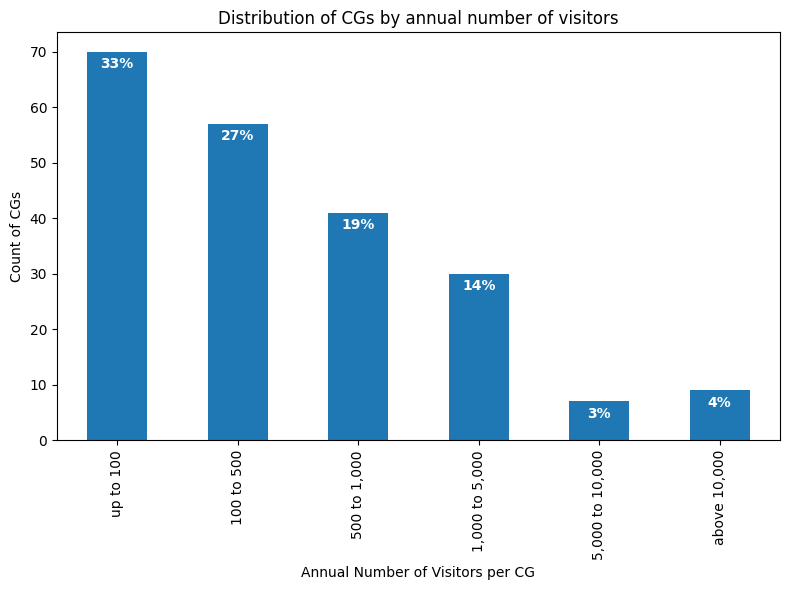

In [55]:
desired_order_visitors = [
    'up to 100',
    '100 to 500',
    '500 to 1,000',
    '1,000 to 5,000',
    '5,000 to 10,000',
    'above 10,000'
]

ginot[N_VISITORS_PER_YEAR].value_counts().reindex(desired_order_visitors).plot(kind='bar')


def rounded_percentages_to_100(counts):
    raw_pct = counts / counts.sum() * 100
    pct = raw_pct.astype(int)
    pct.iloc[np.argsort((raw_pct - pct).to_numpy())[::-1][:100 - pct.sum()]] += 1
    return pct

counts = ginot[N_VISITORS_PER_YEAR].value_counts().reindex(desired_order_visitors).fillna(0)
pct = rounded_percentages_to_100(counts)

ax = counts.plot(kind="bar", figsize=(8, 6))

ax.set_xlabel("Annual Number of Visitors per CG")
ax.set_ylabel("Count of CGs")
ax.set_title("Distribution of CGs by annual number of visitors")


for i, (count, pct) in enumerate(zip(counts, pct)):
    if pd.notna(count):
        ax.text(
            i,
            count - 1,                 # Below the top
            f"{int(pct)}%",
            ha="center",
            va="top",
            color="white",
            fontweight="bold",
            fontsize=10
        )
        

plt.tight_layout()
plt.savefig(fig_path("visitors_distribution.png"), dpi=400, bbox_inches="tight")
plt.show()




In [56]:
ginot.groupby(N_ACTIVE_MEMBERS)[N_ACTIVE_MEMBERS].count().sort_values(ascending=False)

num_activ_members
up to 10    107
10 to 20     76
20 to 30     23
above 40     13
30 to 40      8
Name: num_activ_members, dtype: int64

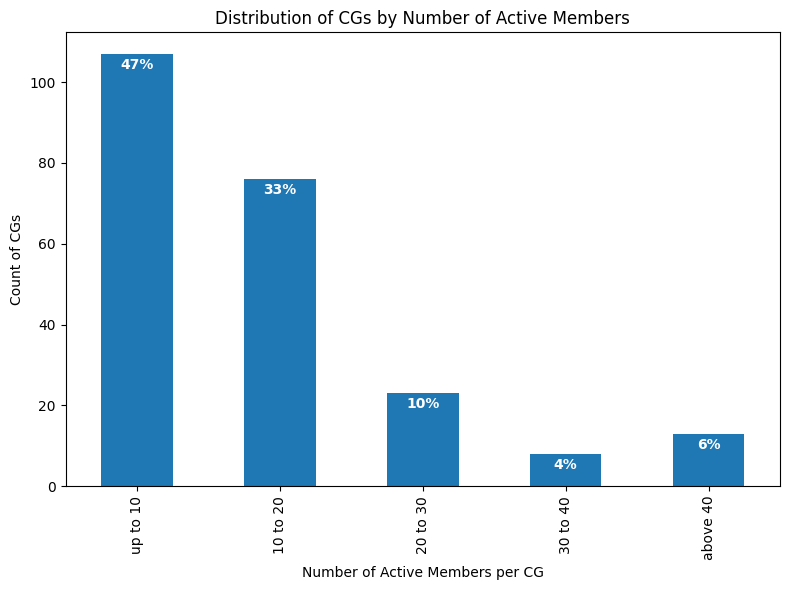

In [57]:
desired_order_active_memebers = [
    'up to 10',
    '10 to 20',
    '20 to 30',
    '30 to 40',
    'above 40',
]

counts = ginot[N_ACTIVE_MEMBERS].value_counts().reindex(desired_order_active_memebers).fillna(0)

def rounded_percentages_to_100(counts):
    total = counts.sum()
    if total == 0:
        return pd.Series(0, index=counts.index, dtype=int)

    raw_pct = counts / total * 100
    raw_pct = raw_pct.fillna(0)
    pct = raw_pct.astype(int)

    remainder = 100 - pct.sum()
    if remainder > 0:
        pct.iloc[np.argsort((raw_pct - pct).to_numpy())[::-1][:remainder]] += 1

    return pct

percentages = rounded_percentages_to_100(counts)

ax = counts.plot(kind='bar', figsize=(8, 6))

ax.set_xlabel("Number of Active Members per CG")
ax.set_ylabel("Count of CGs")
ax.set_title("Distribution of CGs by Number of Active Members")

for i, (count, pct) in enumerate(zip(counts, percentages)):
    if pd.notna(count):
        ax.text(
            i,
            count - 1,                 # Below the top
            f"{int(pct)}%",
            ha="center",
            va="top",
            color="white",
            fontweight="bold",
            fontsize=10
        )

plt.tight_layout()
plt.savefig(fig_path("active_members_distribution.png"), dpi=400, bbox_inches="tight")
plt.show()


**Chi-Square Test**

In [58]:
# Contingency table: active members × annual visitors
members_visitors_table = pd.crosstab(
    ginot[N_ACTIVE_MEMBERS],
    ginot[N_VISITORS_PER_YEAR]
)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(members_visitors_table)

# Results
print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p:.5f}")
print(f"Degrees of freedom: {dof}")


Chi-square statistic: 56.253
p-value: 0.00003
Degrees of freedom: 20


**Chi-Square Test Results**

The test examines whether the number of active members in a garden is associated with the annual number of visitors.


**Results:**

p-value < 0.00003, indicating a highly statistically significant association.

Degrees of freedom: 20.


**Interpretation:**
The number of active members is statistically associated with the number of visitors. In substantive terms, gardens with more active members are more likely to belong to higher visitor categories.


**Spearman correlation**

In [59]:

# Map category values to numeric order
member_order = ['up to 10', '10 to 20', '20 to 30', '30 to 40', 'above 40']
visitor_order = ['up to 100', '100 to 500', '500 to 1,000', '1,000 to 5,000', '5,000 to 10,000', 'above 10,000']

member_map = {v: i for i, v in enumerate(member_order)}
visitor_map = {v: i for i, v in enumerate(visitor_order)}

# Filter missing values
filtered = ginot[
    (ginot[N_VISITORS_PER_YEAR].isin(visitor_order)) &
    (ginot[N_ACTIVE_MEMBERS].isin(member_order))
]

# Convert to numeric orders
x = filtered[N_ACTIVE_MEMBERS].map(member_map)
y = filtered[N_VISITORS_PER_YEAR].map(visitor_map)

# Compute Spearman correlation
corr, pval = spearmanr(x, y)
print(f"Spearman correlation: {corr:.3f}, p-value: {pval:.5f}")


Spearman correlation: 0.400, p-value: 0.00000




**Spearman Correlation Results**

Spearman correlation provide a useful supplementary ordinal association between two ordered variables. It is appropriate here because both active membership and visitor volume are measured as ordered categories rather than continuous values.

The result indicates a moderate positive monotonic association. A coefficient of approximately rho = 0.400 suggests that gardens with higher active-member categories tend also to fall into higher visitor categories. The relationship is not necessarily linear, but its direction is consistent.

The p-value is below 0.00000, indicating that the association is highly statistically significant.

Suggested reporting sentence:

A Spearman rank-order correlation between active-member category and visitor category indicated a statistically significant positive monotonic association (rho = 0.400, p < 0.00000). This suggests that gardens with more active members are more likely to fall into higher visitor categories.

**Heat map with a weighted mean line by category**


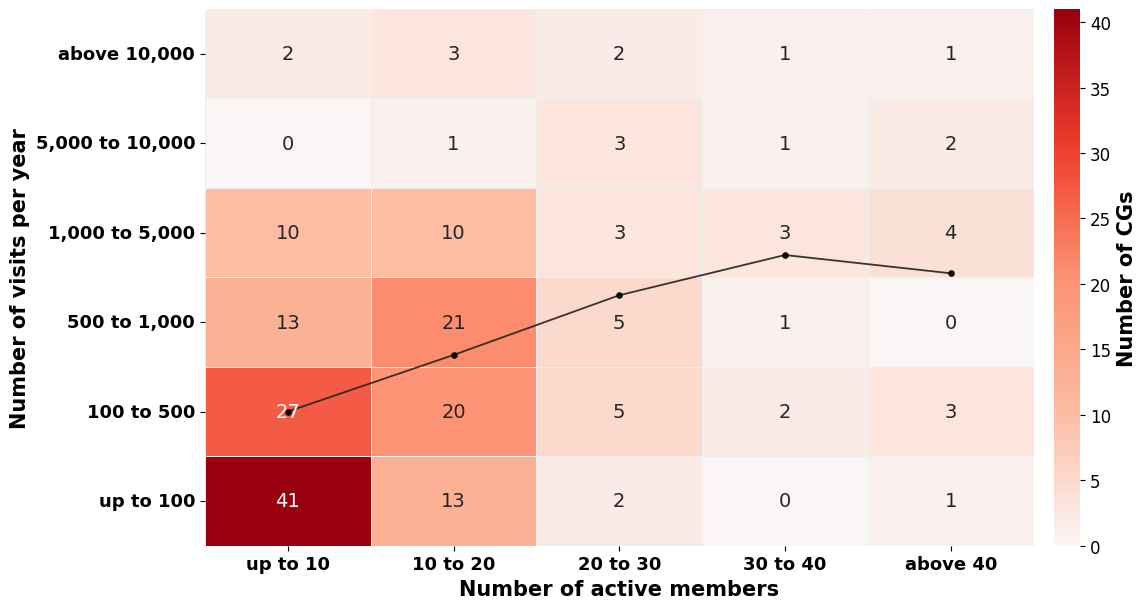

In [60]:
# Ensure output directory exists
os.makedirs(FIG_DIR, exist_ok=True)

# ----------------------------
# 1. Define category order
# ----------------------------
desired_order_visitors = [
    "up to 100",
    "100 to 500",
    "500 to 1,000",
    "1,000 to 5,000",
    "5,000 to 10,000",
    "above 10,000"
]

desired_order_active_memebers = [
    "up to 10",
    "10 to 20",
    "20 to 30",
    "30 to 40",
    "above 40"
]

# ----------------------------
# 2. Build heatmap table
# ----------------------------
heatmap_data = pd.crosstab(
    ginot["num_visitors_per_year"],
    ginot["num_activ_members"]
).reindex(
    index=desired_order_visitors,
    columns=desired_order_active_memebers,
    fill_value=0
)

# Keep original order for weighted-mean calculation
heatmap_original = heatmap_data.copy()

# Reverse rows only for display so the highest visitor category appears at the top
heatmap_data = heatmap_data.iloc[::-1]

# ----------------------------
# 3. Define color palette
# ----------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_heatmap",
    [
        "#faf6f5",  # very light peach
        "#fcbba1",  # light salmon
        "#fc9272",  # soft red
        "#ef3b2c",  # red
        "#99000d"   # dark red
    ]
)

# ----------------------------
# 4. Compute weighted mean line
# ----------------------------
visitor_scores = np.arange(len(desired_order_visitors))

weighted_means = []
valid_x_positions = []

for i, col in enumerate(heatmap_original.columns):
    counts = heatmap_original[col].values
    if counts.sum() > 0:
        weighted_mean = np.average(visitor_scores, weights=counts)
        weighted_means.append(weighted_mean)
        valid_x_positions.append(i)

# Convert weighted means to the displayed heatmap order
n_rows = len(desired_order_visitors)
weighted_means_display = [(n_rows - 1) - y for y in weighted_means]

# ----------------------------
# 5. Plot heatmap
# ----------------------------
fig, ax = plt.subplots(figsize=(12.8, 6.2))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap=custom_cmap,
    linewidths=0.4,
    linecolor="#efefef",
    annot_kws={"fontsize": 14},
    cbar_kws={"label": "Number of CGs", "pad": 0.02},
    ax=ax
)

# Colorbar formatting
cbar = ax.collections[0].colorbar
cbar.set_label("Number of CGs", fontsize=15, fontweight="bold")
cbar.ax.tick_params(labelsize=12)

# ----------------------------
# 6. Add weighted mean line
# ----------------------------
x_positions = np.array(valid_x_positions) + 0.5
y_positions = np.array(weighted_means_display) + 0.5

ax.plot(
    x_positions,
    y_positions,
    color="#222222",
    linewidth=1.3,
    marker="o",
    markersize=3.8,
    markerfacecolor="black",
    markeredgecolor="black",
    alpha=0.9,
    zorder=6
)

# Keep the cell values visible above the line
for text in ax.texts:
    text.set_zorder(10)

# ----------------------------
# 7. Axis labels and tick styling
# ----------------------------
for label in ax.get_xticklabels():
    label.set_fontsize(13)
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontsize(13)
    label.set_fontweight("bold")

ax.set_xlabel("Number of active members", fontsize=15, fontweight="bold")
ax.set_ylabel("Number of visits per year", fontsize=15, fontweight="bold")

# ----------------------------
# 8. Clean frame
# ----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.subplots_adjust(left=0.18, right=0.96)

# ----------------------------
# 9. Save and show
# ----------------------------
plt.savefig(
    fig_path("Number of CGs by visitor and member categories.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

A weighted mean line was calculated for each active-member category, representing the average visitor category weighted by the number of gardens in each cell.

**Weighted mean line calculation**

A weighted mean line was calculated for each active-member category, representing the average visitor category weighted by the number of community gardens in each cell. To compute this line, the six visitor categories were first converted into ordinal numeric scores preserving their ranked order:
0 = “up to 100”,
1 = “100–500”,
2 = “500–1,000”,
3 = “1,000–5,000”,
4 = “5,000–10,000”,
5 = “above 10,000”.

For each active-member category, a weighted average of these visitor-category scores was then computed, using the number of gardens in each cell as weights. This approach ensures that categories with a higher number of gardens contribute proportionally more to the resulting average.

For example, in the “10–20” active members category, the distribution of gardens across visitor categories was 11, 19, 19, 8, 1, and 3, respectively. The weighted mean was therefore calculated as (0×11 + 1×19 + 2×19 + 3×8 + 4×1 + 5×3) divided by (11 + 19 + 19 + 8 + 1 + 3), yielding 100/61 ≈ 1.64.

This value represents the average visitor-category position for community gardens in the “10–20” active members group. The same procedure was applied to all active-member categories, and the resulting weighted means were connected to form the weighted mean line shown in the figure.

**Main Interpretation of the Heat Map**

1. Concentration of small community gardens

2. Positive association between active membership and visitors

3. Limited number of large gardens

4. Evidence of non-linearity

5. Possible threshold effect

The heat map suggests that a shift may occur at approximately 20 active members, beyond which gardens are more likely to attract higher numbers of visitors. This may indicate a threshold effect that warrants further statistical examination.


**number of active members and annual visitors**

Estimate the total number of active members and annual visitors in CGs in Israel's large cities


In [61]:
# Mapping category labels to representative average values
member_avg_map = {
    'up to 10': 5,
    '10 to 20': 15,
    '20 to 30': 25,
    '30 to 40': 35,
    'above 40': 50
}

# Filter rows with valid category values only
valid_members = ginot[ginot[N_ACTIVE_MEMBERS].isin(member_avg_map.keys())].copy()

# Convert categories to numeric average estimates
valid_members['members_estimate'] = valid_members[N_ACTIVE_MEMBERS].map(member_avg_map).astype(int)

# Compute the total estimated number of active members
total_active_members_estimated = valid_members['members_estimate'].sum()

print(f"Estimated total number of active members in community gardens: {total_active_members_estimated}")


Estimated total number of active members in community gardens: 3180


Estimated total number of active members in community gardens: 3200


In [62]:
# Mapping visitor categories to representative average values
visitors_avg_map = {
    'up to 100': 50,
    '100 to 500': 300,
    '500 to 1,000': 750,
    '1,000 to 5,000': 3000,
    '5,000 to 10,000': 7500,
    'above 10,000': 12000
}

# Filter rows with valid category values only
valid_visitors = ginot[ginot[N_VISITORS_PER_YEAR].isin(visitors_avg_map.keys())].copy()

# Convert categories to numeric average estimates
valid_visitors['visitors_estimate'] = valid_visitors[N_VISITORS_PER_YEAR].map(visitors_avg_map).astype(int)

# Compute the total estimated number of visitors
total_visitors_estimated = valid_visitors['visitors_estimate'].sum()

print(f"Estimated total number of annual visitors in community gardens: {total_visitors_estimated}")


Estimated total number of annual visitors in community gardens: 301850


Estimated total number of annual visits in community gardens: 302,000

In [63]:
# =========================
# Define categorical order
# =========================
visitors_order = [
    "up to 100", "100 to 500", "500 to 1,000",
    "1,000 to 5,000", "5,000 to 10,000", "above 10,000"
]

members_order = [
    "up to 10", "10 to 20", "20 to 30", "30 to 40", "above 40"
]

ginot[N_VISITORS_PER_YEAR] = pd.Categorical(
    ginot[N_VISITORS_PER_YEAR], visitors_order, ordered=True
)
ginot[N_ACTIVE_MEMBERS] = pd.Categorical(
    ginot[N_ACTIVE_MEMBERS], members_order, ordered=True
)

# =========================
# Contingency table
# =========================
counts = (
    ginot
    .groupby([N_VISITORS_PER_YEAR, N_ACTIVE_MEMBERS])
    .size()
    .unstack(fill_value=0)
    .iloc[::-1]
)

# =========================
# Chi-square standardized residuals
# =========================
nonzero_rows = counts.sum(axis=1) > 0
nonzero_cols = counts.sum(axis=0) > 0
counts_for_chi2 = counts.loc[nonzero_rows, nonzero_cols]

_, _, _, expected = chi2_contingency(counts_for_chi2)

residuals = pd.DataFrame(0.0, index=counts.index, columns=counts.columns)
residuals.loc[counts_for_chi2.index, counts_for_chi2.columns] = (
    counts_for_chi2 - expected
) / np.sqrt(expected)

# =========================
# Row-wise percentages
# =========================
row_pct = counts.div(counts.sum(axis=1), axis=0) * 100


C:\Users\galia\AppData\Local\Temp\ipykernel_45960\3899314698.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([N_VISITORS_PER_YEAR, N_ACTIVE_MEMBERS])


In [64]:

# =========================
# Define categorical order
# =========================
visitors_order = [
    "up to 100", "100 to 500", "500 to 1,000",
    "1,000 to 5,000", "5,000 to 10,000", "above 10,000"
]

eshkol_order = list(range(1, 11))  # from 1 to 10

# =========================
# Prepare categories
# =========================
ginot = ginot.copy()

ginot[N_VISITORS_PER_YEAR] = pd.Categorical(
    ginot[N_VISITORS_PER_YEAR],
    categories=visitors_order,
    ordered=True
)

ginot[ESHKOL_2021] = pd.to_numeric(ginot[ESHKOL_2021], errors="coerce")
ginot = ginot[ginot[ESHKOL_2021].between(1, 10, inclusive="both")].copy()
ginot[ESHKOL_2021] = ginot[ESHKOL_2021].astype(int)

ginot[ESHKOL_2021] = pd.Categorical(
    ginot[ESHKOL_2021],
    categories=eshkol_order,
    ordered=True
)

# =========================
# Contingency table
# =========================
counts = (
    ginot
    .groupby([N_VISITORS_PER_YEAR, ESHKOL_2021], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=visitors_order, columns=eshkol_order, fill_value=0)
    .iloc[::-1]
)

# =========================
# Remove empty rows/columns for chi-square
# =========================
nonzero_rows = counts.sum(axis=1) > 0
nonzero_cols = counts.sum(axis=0) > 0
counts_for_chi2 = counts.loc[nonzero_rows, nonzero_cols]

# =========================
# Chi-square standardized residuals
# =========================
_, _, _, expected = chi2_contingency(counts_for_chi2)
residuals_small = (counts_for_chi2 - expected) / np.sqrt(expected)

# Expand residuals back to full table for plotting
residuals = pd.DataFrame(
    0.0,
    index=counts.index,
    columns=counts.columns
)
residuals.loc[residuals_small.index, residuals_small.columns] = residuals_small

# =========================
# Row-wise percentages
# =========================
row_sums = counts.sum(axis=1).replace(0, np.nan)
row_pct = counts.div(row_sums, axis=0) * 100
row_pct = row_pct.fillna(0)



####################################################################

**Community gardens in relation to open green areas**

####################################################################


In [65]:
city_ser = ginot.groupby(CITY)[CITY].count().sort_values(ascending=False)
city_names = city_ser.index.tolist()
print(city_names)

['jerusalem', 'tel aviv-yafo', 'beer sheva', 'netanya', 'kfar sava', 'rehovot', 'haifa', 'herzliya', 'ashdod', 'ramat gan', 'holon', 'rishon lezion', 'hadera', 'petah tikva', 'bat yam', 'beit shemesh']


In [66]:
col = GARDENTYPE_GREEN

# Create the new True/False column
ginot["Is_In_Green_Area"] = ginot[col].notna() & ginot[col].astype(str).str.strip().ne("")
# Create a text column instead of boolean
ginot["In_Green_Area_Label"] = ginot["Is_In_Green_Area"].map(
    {True: "Green Area", False: "Outside Formal Green-Area"}
)
ginot[ginot["Is_In_Green_Area"]].count()


department responsible                                                62
gis's layer of cgs? points/polygon/non                                62
city area (km2)                                                       62
density for km2                                                       62
green areas gis (km2)                                                 62
# unites of green areas                                               62
mean area                                                             62
satisfaction with parks and green spaces in the residential area %    62
density in built area (person per km2)                                62
forest and woodland (km2)                                             62
parks and gardens (km2)                                               62
culture, leisure, vacation, and sport (km2)                           62
no. pupils in the city                                                62
no of schools in the city                          

In [67]:
# Prepare numeric city-level columns on the unique cities dataframe
columns_to_convert = [
    POP_2023,
    GREEN_AREAS_KM2
]
columns_to_convert = [col for col in columns_to_convert if col in cities.columns]

for col in columns_to_convert:
    cities[col] = (
        cities[col]
        .astype(str)
        .str.replace('"', '', regex=False)
        .str.replace(',', '', regex=False)
    )
    cities[col] = pd.to_numeric(cities[col], errors='coerce')

In [68]:
cities[N_COMMUNITY_GARDENS] = cities[N_COMMUNITY_GARDENS].fillna(0).astype(int)
cities = cities[cities[N_COMMUNITY_GARDENS] > 0].copy()

# Example display
print(cities[[CITY, N_COMMUNITY_GARDENS]].sort_values(by=N_COMMUNITY_GARDENS, ascending=False))

              city  num_community_gardens
81       jerusalem                     71
224  tel aviv-yafo                     69
16      beer sheva                     22
170        netanya                     18
152      kfar sava                     18
192        rehovot                     16
43           haifa                     15
67        herzliya                     14
0           ashdod                     13
214      ramat gan                     10
58           holon                      9
208  rishon lezion                      6
188    petah tikva                      4
39          hadera                      4
13        ashqelon                      1
15      bene beraq                      1
38    beit shemesh                      1
14         bat yam                      1


ginot shape: (291, 39)
cities shape: (18, 38)

Number of gardens in cities dataframe:
293

Cities:
              city  num_community_gardens
81       jerusalem                     71
224  tel aviv-yafo                     69
16      beer sheva                     22
170        netanya                     18
152      kfar sava                     18
192        rehovot                     16
43           haifa                     15
67        herzliya                     14
0           ashdod                     13
214      ramat gan                     10
58           holon                      9
208  rishon lezion                      6
188    petah tikva                      4
39          hadera                      4
13        ashqelon                      1
15      bene beraq                      1
38    beit shemesh                      1
14         bat yam                      1

Cities included in correlation: 18

Pearson correlation: -0.116
P-value: 0.645


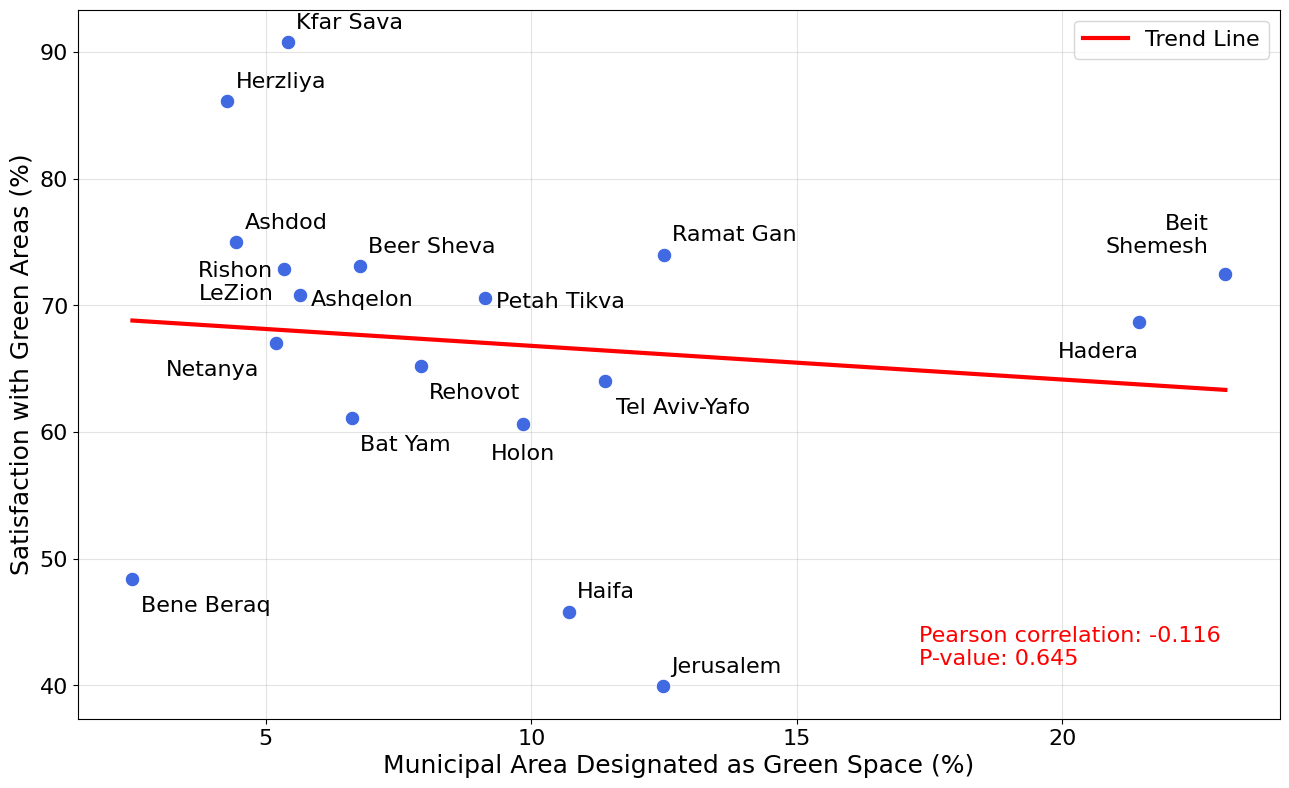

In [69]:
# ============================================================
# GREEN-AREA EXTENT AND SATISFACTION BY CITY
# ============================================================

# Required imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from scipy.stats import pearsonr


# ============================================================
# 1. BASIC DATA CHECKS
# ============================================================

print("ginot shape:", ginot.shape)
print("cities shape:", cities.shape)

print("\nNumber of gardens in cities dataframe:")
print(cities[N_COMMUNITY_GARDENS].sum())

print("\nCities:")
print(
    cities[
        [CITY, N_COMMUNITY_GARDENS]
    ]
    .sort_values(
        N_COMMUNITY_GARDENS,
        ascending=False
    )
)


# ============================================================
# 2. CALCULATE X AND Y VARIABLES
# ============================================================
# GREEN_AREAS_KM2 and AREA_KM2 are both measured in km².
# Their ratio is multiplied by 100 to express the result
# as the percentage of the municipal area designated
# as green space.

cities["green area percent"] = (
    cities[GREEN_AREAS_KM2]
    / cities[AREA_KM2]
) * 100

x = cities["green area percent"]
y = cities[SAT_PARKS_PCT]


# ============================================================
# 3. VALID OBSERVATIONS
# ============================================================

mask = (
    x.notna()
    & y.notna()
    & np.isfinite(x)
    & np.isfinite(y)
)

x_fit = x[mask]
y_fit = y[mask]

print(
    "\nCities included in correlation:",
    len(x_fit)
)


# ============================================================
# 4. PEARSON CORRELATION
# ============================================================

corr, p_value = pearsonr(
    x_fit,
    y_fit
)

print(
    f"\nPearson correlation: {corr:.3f}"
)

print(
    f"P-value: {p_value:.3g}"
)


# ============================================================
# 5. LINEAR TREND
# ============================================================

slope, intercept = np.polyfit(
    x_fit,
    y_fit,
    1
)

# Ordered X values for a clean trend line
x_line = np.linspace(
    x_fit.min(),
    x_fit.max(),
    200
)

y_line = (
    slope * x_line
    + intercept
)


# ============================================================
# 6. CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 8)
)


# ------------------------------------------------------------
# Scatter points
# ------------------------------------------------------------

ax.scatter(
    x_fit,
    y_fit,
    c="royalblue",
    s=110,
    edgecolors="white",
    linewidths=0.7,
    zorder=3
)


# ------------------------------------------------------------
# Trend line
# ------------------------------------------------------------

ax.plot(
    x_line,
    y_line,
    color="red",
    linewidth=3,
    label="Trend Line",
    zorder=2
)


# ============================================================
# 7. PEARSON CORRELATION TEXT
# ============================================================

ax.text(
    0.70,
    0.07,
    (
        f"Pearson correlation: {corr:.3f}\n"
        f"P-value: {p_value:.3g}"
    ),
    transform=ax.transAxes,
    fontsize=16,
    color="red",
    ha="left",
    va="bottom"
)


# ============================================================
# 8. CITY LABELS
# ============================================================

def city_key(value):
    """
    Standardize city names for matching.
    """
    return (
        str(value)
        .strip()
        .lower()
        .replace("’", "'")
    )


# ------------------------------------------------------------
# Publication-ready city names
# ------------------------------------------------------------

city_display_names = {
    "ashdod": "Ashdod",
    "ashqelon": "Ashqelon",
    "bat yam": "Bat Yam",
    "beer sheva": "Beer Sheva",
    "be'er sheva": "Beer Sheva",
    "beit shemesh": "Beit Shemesh",
    "bene beraq": "Bene Beraq",
    "bnei brak": "Bene Beraq",
    "hadera": "Hadera",
    "haifa": "Haifa",
    "herzliya": "Herzliya",
    "holon": "Holon",
    "jerusalem": "Jerusalem",
    "kfar sava": "Kfar Sava",
    "netanya": "Netanya",
    "petah tikva": "Petah Tikva",
    "ramat gan": "Ramat Gan",
    "rehovot": "Rehovot",
    "rishon lezion": "Rishon LeZion",
    "tel aviv": "Tel Aviv-Yafo",
    "tel aviv-yafo": "Tel Aviv-Yafo",
}


# ------------------------------------------------------------
# Manual adjustments for crowded labels
# ------------------------------------------------------------

city_label_adjustments = {

    "tel aviv-yafo": {
        "text": "Tel Aviv-Yafo",
        "xytext": (8, -12),
        "ha": "left",
        "va": "top",
    },

    "tel aviv": {
        "text": "Tel Aviv-Yafo",
        "xytext": (8, -12),
        "ha": "left",
        "va": "top",
    },

    "beit shemesh": {
        "text": "Beit\nShemesh",
        "xytext": (-12, 12),
        "ha": "right",
        "va": "bottom",
    },

    "rishon lezion": {
        "text": "Rishon\nLeZion",
        "xytext": (-8, -10),
        "ha": "right",
        "va": "center",
    },

    "holon": {
        "text": "Holon",
        "xytext": (0, -14),
        "ha": "center",
        "va": "top",
    },

    "hadera": {
        "text": "Hadera",
        "xytext": (0, -14),
        "ha": "right",
        "va": "top",
    },

    "ashqelon": {
        "text": "Ashqelon",
        "xytext": (8, -3),
        "ha": "left",
        "va": "center",
    },

    "petah tikva": {
        "text": "Petah Tikva",
        "xytext": (8, -3),
        "ha": "left",
        "va": "center",
    },

    "netanya": {
        "text": "Netanya",
        "xytext": (-12, -12),
        "ha": "right",
        "va": "top",
    },
}


# Cities with fixed label position
fixed_labels = {
    "jerusalem",
    "haifa",
}


# ------------------------------------------------------------
# Define right-edge threshold relative to data range
# ------------------------------------------------------------

x_range = (
    x_fit.max()
    - x_fit.min()
)

right_edge_threshold = (
    x_fit.max()
    - 0.10 * x_range
)


# ------------------------------------------------------------
# Add exactly one label per city
# ------------------------------------------------------------

for i, city in enumerate(
    cities[CITY]
):

    xi = x.iloc[i]
    yi = y.iloc[i]

    # Skip cities without valid X/Y data
    if (
        pd.isna(xi)
        or pd.isna(yi)
        or not np.isfinite(xi)
        or not np.isfinite(yi)
    ):
        continue

    key = city_key(city)

    name = city_display_names.get(
        key,
        str(city).strip()
    )

    yi_trend = (
        slope * xi
        + intercept
    )


    # --------------------------------------------------------
    # 1. Manually positioned labels
    # --------------------------------------------------------

    if key in city_label_adjustments:

        label_style = (
            city_label_adjustments[key]
        )

        ax.annotate(
            label_style["text"],
            (xi, yi),
            fontsize=16,
            xytext=label_style["xytext"],
            textcoords="offset points",
            ha=label_style["ha"],
            va=label_style["va"],
            zorder=4
        )

        continue


    # --------------------------------------------------------
    # 2. Cities near right edge
    # --------------------------------------------------------

    if xi >= right_edge_threshold:

        ax.annotate(
            name,
            (xi, yi),
            fontsize=16,
            xytext=(-10, 7),
            textcoords="offset points",
            ha="right",
            va="bottom",
            zorder=4
        )

        continue


    # --------------------------------------------------------
    # 3. Jerusalem and Haifa
    # --------------------------------------------------------

    if key in fixed_labels:

        ax.annotate(
            name,
            (xi, yi),
            fontsize=16,
            xytext=(6, 7),
            textcoords="offset points",
            ha="left",
            va="bottom",
            zorder=4
        )

        continue


    # --------------------------------------------------------
    # 4. City below trend line
    # --------------------------------------------------------

    if yi < yi_trend:

        ax.annotate(
            name,
            (xi, yi),
            fontsize=16,
            xytext=(6, -12),
            textcoords="offset points",
            ha="left",
            va="top",
            zorder=4
        )


    # --------------------------------------------------------
    # 5. City above trend line
    # --------------------------------------------------------

    else:

        ax.annotate(
            name,
            (xi, yi),
            fontsize=16,
            xytext=(6, 7),
            textcoords="offset points",
            ha="left",
            va="bottom",
            zorder=4
        )


# ============================================================
# 9. AXES
# ============================================================

ax.set_xlabel(
    "Municipal Area Designated as Green Space (%)",
    fontsize=18
)

ax.set_ylabel(
    "Satisfaction with Green Areas (%)",
    fontsize=18
)

ax.tick_params(
    axis="both",
    labelsize=16
)

ax.grid(
    True,
    alpha=0.35
)


# ============================================================
# 10. LEGEND
# ============================================================

trend_handle = mlines.Line2D(
    [],
    [],
    color="red",
    linewidth=3,
    label="Trend Line"
)

ax.legend(
    handles=[trend_handle],
    loc="upper right",
    fontsize=16
)


# ============================================================
# 11. SAVE + SHOW
# ============================================================

plt.tight_layout()

plt.savefig(
    fig_path(
        "satisfaction_vs_green_area_percent.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Data used for green-area plot: (293, 37)
Columns:
['department responsible', "gis's layer of cgs? points/polygon/non", 'city area (km2)', 'density for km2', 'green areas gis (km2)', '# unites of green areas', 'mean area', 'satisfaction with parks and green spaces in the residential area %', 'density in built area (person per km2)', 'forest and woodland (km2)', 'parks and gardens (km2)', 'culture, leisure, vacation, and sport (km2)', 'no. pupils in the city', 'no of schools in the city', 'avg salary', 'city avg sei 2021', 'city population', 'city', 'id_gina', 'y_latitude by wgs84', 'x_longitude by wgs84', 'green_area_m2_400', 'count no. of green unites within 400m', 'cat_special_location', 'activity (years)', 'num_activ_members', 'num_visitors_per_year', 'area stat no. by lamas 2021', 'sei_neighb', 'sei gap', 'on_green', 'gardentype', 'walkable_length(m)_within_400m', 'funding_categories', 'num_cat of funding', 'categories of the community', 'special community (yes/no)']

Rows removed b

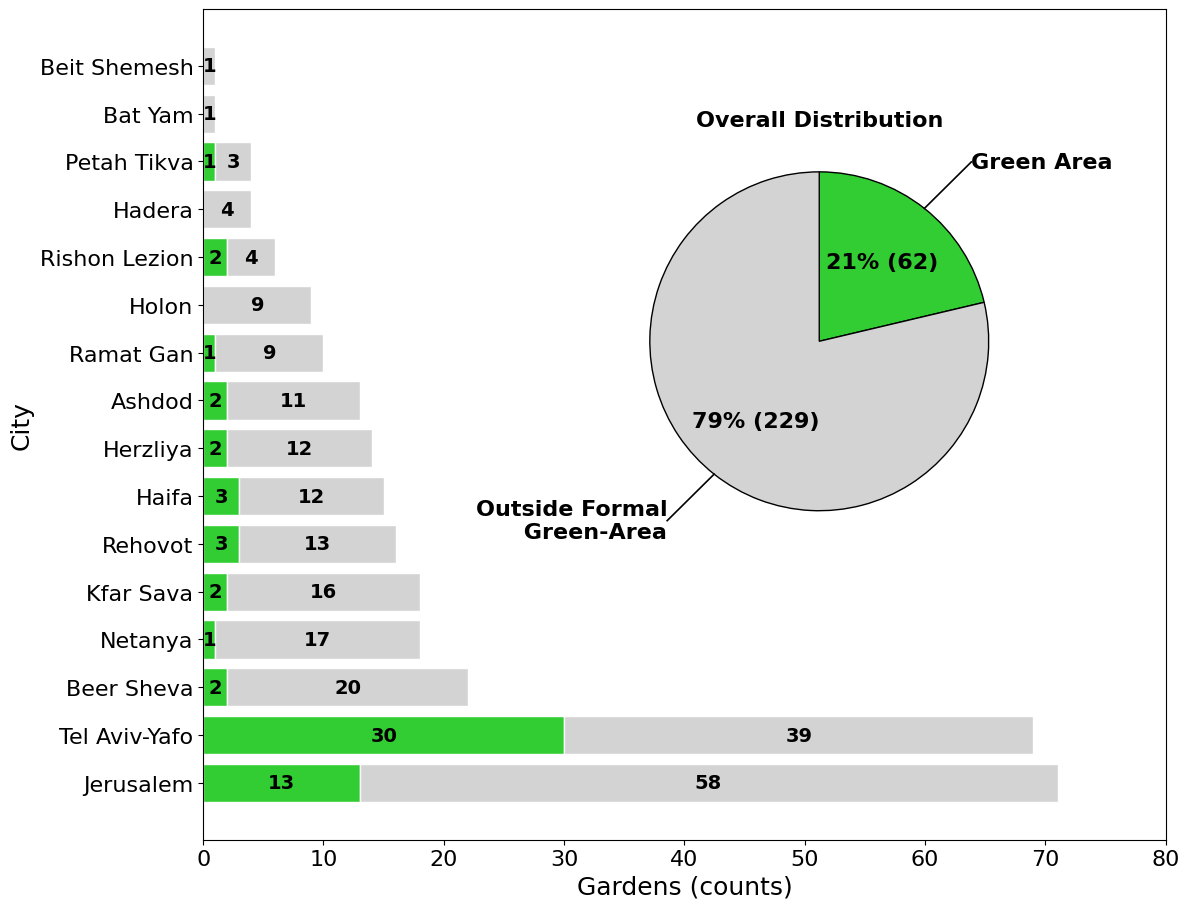

In [70]:
# ============================================
# FIGURE: Community gardens inside / outside formal green areas
# Updated dataset version
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0. File and output settings
# -----------------------------

FILE_GINOT = "All CGs IL - Final.csv"

FIG_DIR = "output_CGs"
os.makedirs(FIG_DIR, exist_ok=True)

def fig_path(filename):
    return os.path.join(FIG_DIR, filename)


# -----------------------------
# 1. Load updated dataset
# -----------------------------

ginot_green_plot = pd.read_csv(FILE_GINOT, encoding="utf-8-sig")

# Normalize column names ONCE
ginot_green_plot.columns = (
    ginot_green_plot.columns
    .str.lower()
    .str.strip()
)

print("Data used for green-area plot:", ginot_green_plot.shape)
print("Columns:")
print(ginot_green_plot.columns.tolist())


# -----------------------------
# 2. Define columns
# -----------------------------

CITY = "city"
GARDENTYPE = "gardentype"
ON_GREEN = "on_green"

required_cols = [CITY, GARDENTYPE, ON_GREEN]
missing_cols = [c for c in required_cols if c not in ginot_green_plot.columns]

if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

# -----------------------------
# 2b. Remove placeholder rows without actual garden coordinates
# -----------------------------

X_COL = "x_longitude by wgs84"
Y_COL = "y_latitude by wgs84"

coord_required = [CITY, X_COL, Y_COL]
missing_coord_cols = [c for c in coord_required if c not in ginot_green_plot.columns]

if missing_coord_cols:
    raise KeyError(f"Missing coordinate columns: {missing_coord_cols}")

missing_values = ["", "nan", "none", "na", "n/a", "non", "no data"]

city_clean = (
    ginot_green_plot[CITY]
    .astype(str)
    .str.strip()
    .str.lower()
)

x_missing = (
    ginot_green_plot[X_COL].isna()
    | ginot_green_plot[X_COL]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(missing_values)
)

y_missing = (
    ginot_green_plot[Y_COL].isna()
    | ginot_green_plot[Y_COL]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(missing_values)
)

rows_to_remove = (
    city_clean.isin([
        "ashkelon",
        "ashqelon",
        "bene beraq",
        "bnei brak",
        "bnei beraq"
    ])
    & x_missing
    & y_missing
)

print("\nRows removed because they are city placeholders without garden coordinates:")
print(ginot_green_plot.loc[rows_to_remove, [CITY, X_COL, Y_COL]])

ginot_green_plot = ginot_green_plot.loc[~rows_to_remove].copy()

print("\nData after removing placeholder rows:", ginot_green_plot.shape)


# -----------------------------
# 3. Define Green / Non Green status
# -----------------------------

gardentype_green = (
    ginot_green_plot[GARDENTYPE].notna()
    & ~ginot_green_plot[GARDENTYPE]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["", "nan", "none", "no data"])
)

on_green_yes = (
    ginot_green_plot[ON_GREEN]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["yes", "y", "true", "1", "green area"])
)

ginot_green_plot["In_Green_Area_Label"] = np.where(
    gardentype_green | on_green_yes,
    "Green Area",
    "Outside Formal Green-Area"
)

print("\nUpdated Green / Non Green counts:")
print(ginot_green_plot["In_Green_Area_Label"].value_counts(dropna=False))


# -----------------------------
# 4. Count gardens per city and category
# -----------------------------

city_counts = (
    ginot_green_plot
    .groupby([CITY, "In_Green_Area_Label"])
    .size()
    .unstack(fill_value=0)
)

city_counts["__total__"] = city_counts.sum(axis=1)
city_counts = city_counts.sort_values("__total__", ascending=False)

plot_df = city_counts.reindex(
    columns=["Green Area", "Outside Formal Green-Area"],
    fill_value=0
).copy()

colors = {
    "Green Area": "limegreen",
    "Outside Formal Green-Area": "lightgray"
}


# -----------------------------
# 5. Create horizontal stacked bar chart
# -----------------------------

n_rows = plot_df.shape[0]
fig, ax = plt.subplots(figsize=(12, max(6, 0.45 * n_rows + 2)))

y_pos = np.arange(n_rows)
left = np.zeros(n_rows, dtype=float)

for col in ["Green Area", "Outside Formal Green-Area"]:
    vals = plot_df[col].values.astype(float)
    ax.barh(
        y_pos,
        vals,
        left=left,
        color=colors[col],
        edgecolor="white",
        label=col
    )
    left += vals


# -----------------------------
# 6. Add numbers inside bars
# -----------------------------

for i, (idx, row) in enumerate(plot_df.iterrows()):
    g = int(row["Green Area"])
    ng = int(row["Outside Formal Green-Area"])

    if g > 0:
        ax.text(
            g / 2,
            i,
            f"{g}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black"
        )

    if ng > 0:
        ax.text(
            g + ng / 2,
            i,
            f"{ng}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black"
        )


# -----------------------------
# 7. Axis settings
# -----------------------------

max_total = plot_df[["Green Area", "Outside Formal Green-Area"]].sum(axis=1).max()
ax.set_xlim(0, max(80, max_total + 5))

ax.set_yticks(y_pos)
ax.set_yticklabels(
    [
        "Beer Sheva" if str(i).lower() == "be'er sheva" else str(i).title()
        for i in plot_df.index
    ],
    fontsize=16
)

ax.set_xlabel("Gardens (counts)", fontsize=18)
ax.set_ylabel("City", fontsize=18)
ax.tick_params(axis="x", labelsize=16)

#ax.legend(fontsize=14, loc="lower right")


# -----------------------------
# 8. Create pie chart inset
# -----------------------------

totals = plot_df[["Green Area", "Outside Formal Green-Area"]].sum()
total_sum = float(totals.sum())

print("\nPIE totals:", totals.to_dict(), " | total_sum:", total_sum)

if total_sum > 0:

    sizes = [
        float(totals["Green Area"]),
        float(totals["Outside Formal Green-Area"])
    ]

    labels = ["Green Area", "Outside Formal\n Green-Area"]

    pie_colors = [
        colors["Green Area"],
        colors["Outside Formal Green-Area"]
    ]

    pie_w, pie_h = 0.44, 0.60
    pie_x0, pie_y0 = 0.42, 0.30

    axins = ax.inset_axes([pie_x0, pie_y0, pie_w, pie_h])

    def make_autopct(vals):
        total = sum(vals)

        def _autopct(pct):
            count = int(round(pct / 100.0 * total))
            return f"{pct:.0f}% ({count})"

        return _autopct

    ret = axins.pie(
        sizes,
        colors=pie_colors,
        autopct=make_autopct(sizes),
        startangle=90,
        counterclock=False,
        pctdistance=0.6,
        textprops={
            "fontsize": 16,
            "color": "black",
            "fontweight": "bold"
        },
        wedgeprops={
            "linewidth": 1,
            "edgecolor": "black"
        }
    )

    wedges = ret[0]

    axins.set_aspect("equal")
    axins.set_title(
        "Overall Distribution",
        fontsize=16,
        fontweight="bold",
        pad=2
    )

    # External labels + connector lines
    r_edge = 1.0
    r_text = 1.35
    pad = 0.06

    for lab, w in zip(labels, wedges):

        ang = (w.theta1 + w.theta2) / 2.0
        ang_rad = np.deg2rad(ang)

        x_edge = r_edge * np.cos(ang_rad)
        y_edge = r_edge * np.sin(ang_rad)

        x_txt = r_text * np.cos(ang_rad)
        y_txt = r_text * np.sin(ang_rad)

        ha = "left" if x_txt >= 0 else "right"
        x_txt += pad if ha == "left" else -pad

        axins.text(
            x_txt,
            y_txt,
            lab,
            ha=ha,
            va="center",
            fontsize=16,
            fontweight="bold",
            color="black"
        )

        axins.plot(
            [x_edge, x_txt],
            [y_edge, y_txt],
            color="black",
            lw=1.2
        )


# -----------------------------
# 9. Final layout and export
# -----------------------------

plt.tight_layout()

plt.savefig(
    fig_path("gardens_in_out_green_areas_updated.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

########
########################################################
########################################################

**#####  Socio-Economic Index  #####**

######################################################
######################################################
#########

The weighted funding score should be interpreted cautiously. For the main analysis, it may be preferable to evaluate whether the number of funding sources is associated with garden outcomes, rather than adding additional weights to selected funding categories.

The following analysis examines funding categories by annual visitor category. A derived variable, `tilted_ncof`, was created by adding one additional point to two funding categories: NGO-related funding and self-funding. This sensitivity measure is compared with the unweighted number of funding categories.


In [71]:
def set_ncof(row):
    
    if pd.isna(row[FUNDING_CATEGORIES]) or pd.isna(row[N_CATEGORIES_FUNDING]):
        #return 0
        return pd.NA
    
    ncof_value = row[N_CATEGORIES_FUNDING]
    fund_cats = row[FUNDING_CATEGORIES]

    if "ngo" in fund_cats:
        ncof_value = ncof_value+1

    if "self-funded" in fund_cats:
        ncof_value = ncof_value+1
        
    return ncof_value

ginot['tilted_ncof'] = ginot.apply(set_ncof, axis=1)

In [72]:
ginot[N_CATEGORIES_FUNDING] = ginot[N_CATEGORIES_FUNDING].replace(0, pd.NA)
comparison = ginot.groupby(N_VISITORS_PER_YEAR)[["tilted_ncof", N_CATEGORIES_FUNDING]].median()
print(comparison)

                       tilted_ncof  num_cat of funding
num_visitors_per_year                                 
up to 100                      1.0                 1.0
100 to 500                     2.0                 2.0
500 to 1,000                   2.0                 2.0
1,000 to 5,000                 2.0                 2.0
5,000 to 10,000                2.0                 2.0
above 10,000                   2.0                 2.0


C:\Users\galia\AppData\Local\Temp\ipykernel_45960\2281434908.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comparison = ginot.groupby(N_VISITORS_PER_YEAR)[["tilted_ncof", N_CATEGORIES_FUNDING]].median()


The right-hand column presents the median number of funding sources by visitor category before the additional weighting was applied. The results suggest that the number of funding sources generally increases with visitor volume, reaching a plateau of approximately two funding sources, with a local peak among gardens with 1,000-5,000 annual visitors.

The middle column presents the median values after applying additional weight to NGO-related and self-funding categories. The same overall pattern remains: higher visitor categories tend to be associated with a larger number of funding sources, reaching a plateau of approximately three funding sources.


The following analysis examines funding patterns by active-member category.


In [73]:
ginot[N_CATEGORIES_FUNDING] = ginot[N_CATEGORIES_FUNDING].replace(0, pd.NA)
comparison = ginot.groupby(N_ACTIVE_MEMBERS)[["tilted_ncof", N_CATEGORIES_FUNDING]].median()
print(comparison)

                   tilted_ncof  num_cat of funding
num_activ_members                                 
up to 10                   1.0                 1.0
10 to 20                   2.0                 2.0
20 to 30                   2.0                 2.0
30 to 40                   2.0                 2.0
above 40                   2.0                 2.0


C:\Users\galia\AppData\Local\Temp\ipykernel_45960\936243506.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comparison = ginot.groupby(N_ACTIVE_MEMBERS)[["tilted_ncof", N_CATEGORIES_FUNDING]].median()


The findings indicate that gardens with more active members tend to have a larger number of funding sources.

Adding extra weight for NGO-related and self-funding categories **does not** materially alter this trend.


Figure saved to: C:\Users\galia\Desktop\CGs Israel Code\output_CGs\CG_SEI_distribution.png


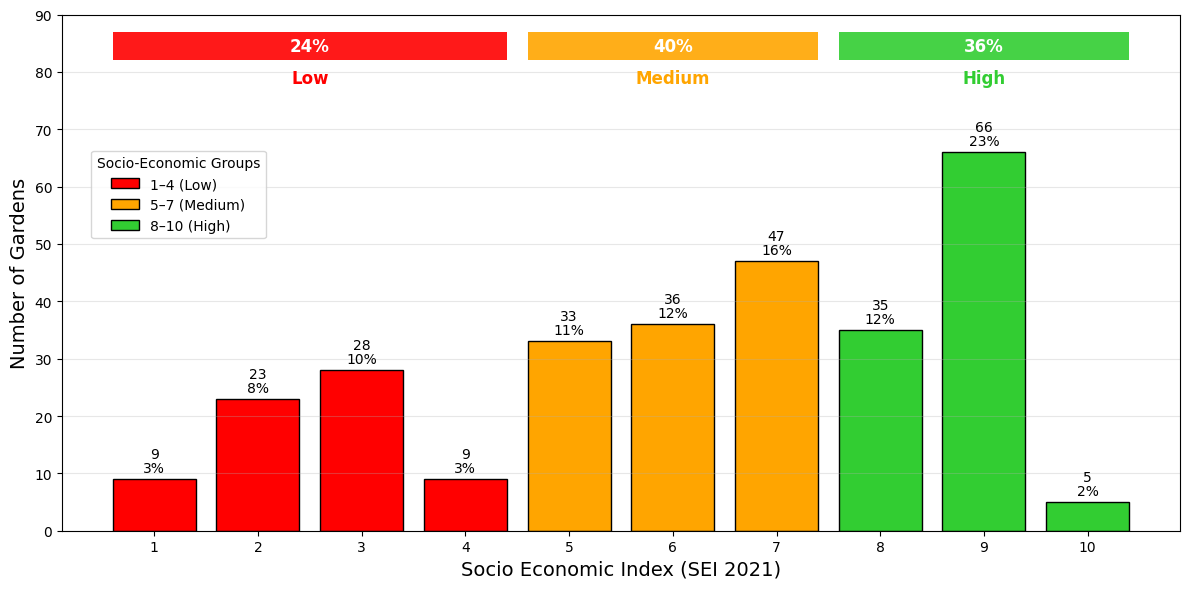

In [74]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

# --------------------------------------------------
# Data
# --------------------------------------------------
sei_clusters = list(range(1, 11))
garden_counts = [9, 23, 28, 9, 33, 36, 47, 35, 66, 5]

total_gardens = sum(garden_counts)
garden_percentages = [
    count / total_gardens * 100
    for count in garden_counts
]

# Colours by aggregated socioeconomic group
bar_colors = [
    "red", "red", "red", "red",                  # SEI 1–4
    "orange", "orange", "orange",                 # SEI 5–7
    "limegreen", "limegreen", "limegreen"         # SEI 8–10
]

# Aggregated groups
group_ranges = [
    {
        "name": "Low",
        "percentage": "24%",
        "start_x": 0.6,
        "width": 3.8,
        "center_x": 2.5,
        "color": "red"
    },
    {
        "name": "Medium",
        "percentage": "40%",
        "start_x": 4.6,
        "width": 2.8,
        "center_x": 6.0,
        "color": "orange"
    },
    {
        "name": "High",
        "percentage": "36%",
        "start_x": 7.6,
        "width": 2.8,
        "center_x": 9.0,
        "color": "limegreen"
    }
]

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    sei_clusters,
    garden_counts,
    color=bar_colors,
    edgecolor="black",
    width=0.8
)

# --------------------------------------------------
# Labels above the individual bars
# --------------------------------------------------
for bar, count, percentage in zip(
    bars,
    garden_counts,
    garden_percentages
):
    x_position = bar.get_x() + bar.get_width() / 2
    y_position = bar.get_height()

    ax.text(
        x_position,
        y_position + 0.7,
        f"{count}\n{percentage:.0f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        linespacing=1.0
    )

# --------------------------------------------------
# Aggregated group ribbons
# --------------------------------------------------
group_bar_y = 82
group_bar_height = 5
group_name_y = 79

for group in group_ranges:
    ribbon = Rectangle(
        (group["start_x"], group_bar_y),
        group["width"],
        group_bar_height,
        facecolor=group["color"],
        edgecolor="none",
        alpha=0.9
    )
    ax.add_patch(ribbon)

    # Percentage inside ribbon
    ax.text(
        group["center_x"],
        group_bar_y + group_bar_height / 2,
        group["percentage"],
        ha="center",
        va="center",
        color="white",
        fontsize=12,
        fontweight="bold"
    )

    # Group name below ribbon
    ax.text(
        group["center_x"],
        group_name_y,
        group["name"],
        ha="center",
        va="center",
        color=group["color"],
        fontsize=12,
        fontweight="bold"
    )

# --------------------------------------------------
# Legend
# --------------------------------------------------
legend_elements = [
    Patch(
        facecolor="red",
        edgecolor="black",
        label="1–4 (Low)"
    ),
    Patch(
        facecolor="orange",
        edgecolor="black",
        label="5–7 (Medium)"
    ),
    Patch(
        facecolor="limegreen",
        edgecolor="black",
        label="8–10 (High)"
    )
]

ax.legend(
    handles=legend_elements,
    title="Socio-Economic Groups",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.75),
    frameon=True
)

# --------------------------------------------------
# Axes and formatting
# --------------------------------------------------
ax.set_xlabel(
    "Socio Economic Index (SEI 2021)",
    fontsize=14
)

ax.set_ylabel(
    "Number of Gardens",
    fontsize=14
)

ax.set_xticks(sei_clusters)

# Increased to 90 to create space above the bars
ax.set_ylim(0, 90)
ax.set_yticks(range(0, 91, 10))

ax.grid(
    axis="y",
    linestyle="-",
    alpha=0.3
)

ax.tick_params(
    axis="both",
    labelsize=10
)

plt.tight_layout()

from pathlib import Path

OUTPUT_DIR = Path("output_CGs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

fig.savefig(
    OUTPUT_DIR / "CG_SEI_distribution.png",
    dpi=400,
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_DIR / "CG_SEI_distribution.pdf",
    bbox_inches="tight",
)

print(
    "Figure saved to:",
    (OUTPUT_DIR / "CG_SEI_distribution.png").resolve()
)

plt.show()

C:\Users\galia\AppData\Local\Temp\ipykernel_45960\3597978773.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


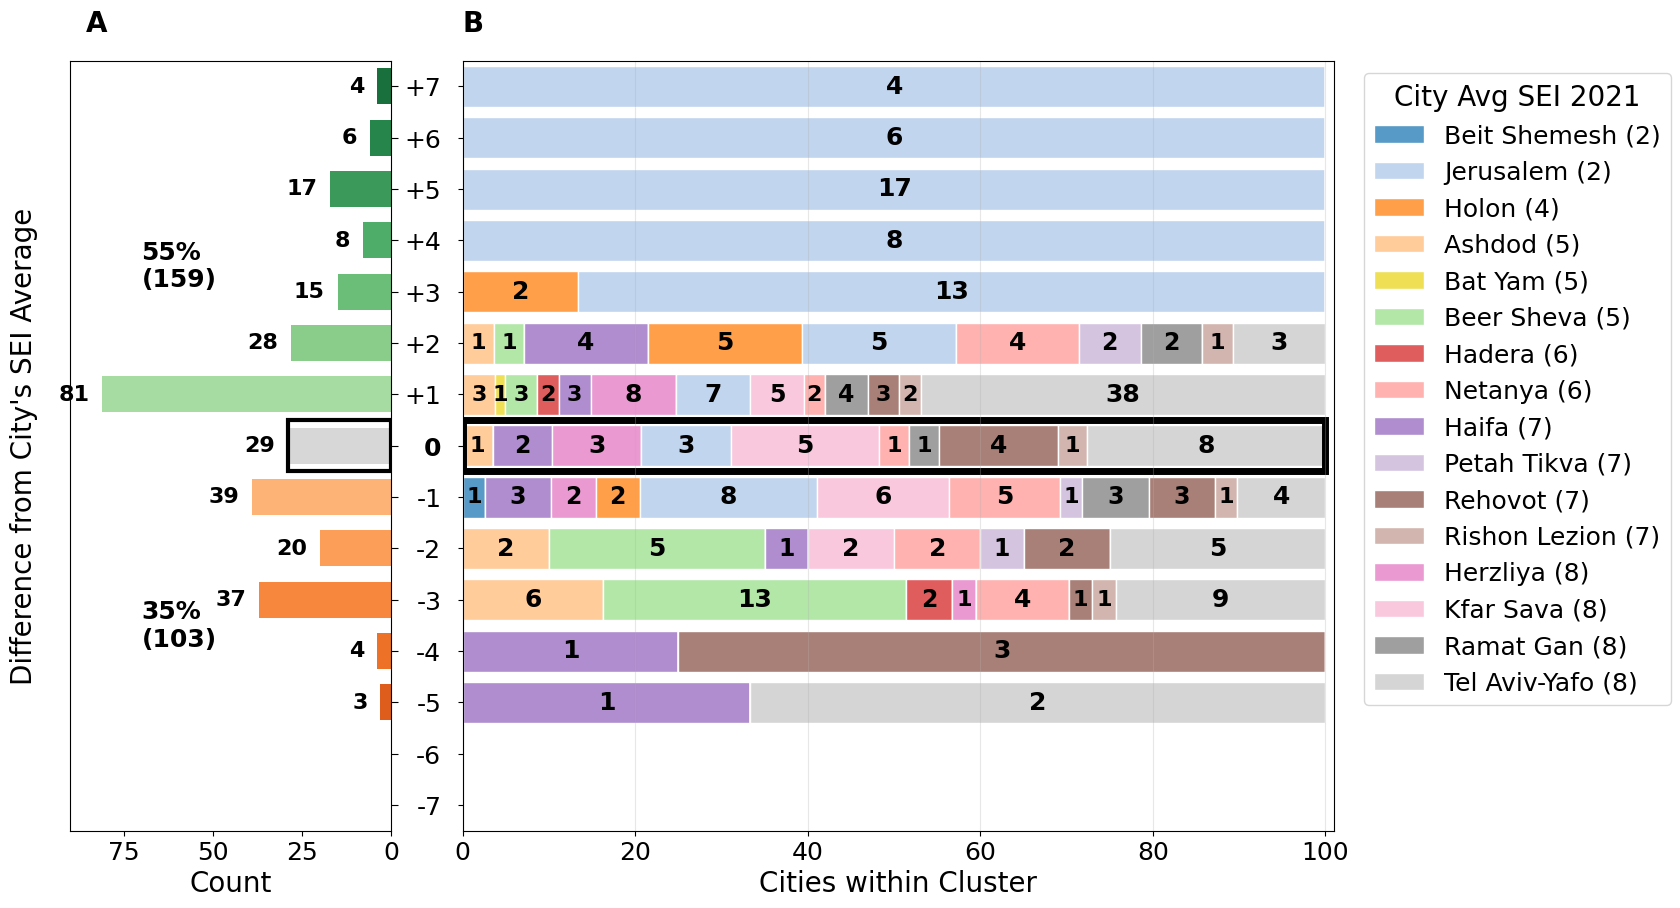

In [75]:
# ===============================================================
# SETTINGS (UPDATED COLUMN NAMES)
# ===============================================================
diff_col = SEI_GAP
city_col = CITY
avg_col  = CITY_AVG_ESHKOL_2021

# Retain this step when the data-processing pipeline standardizes column headers.
# ginot.columns = ginot.columns.astype(str).str.lower().str.strip()

# ===============================================================
# DATA PREPARATION  (Y scale forced to -7..+7)
# ===============================================================
df = ginot[[diff_col, city_col, avg_col]].dropna(subset=[diff_col, city_col]).copy()
df[diff_col] = df[diff_col].astype(int)

# Restrict the plotted domain to the range -7 to +7.
df = df[df[diff_col].between(-7, 7)]

df["city_group"] = df[city_col].astype(str).str.strip()

counts = (
    df.pivot_table(index=diff_col, columns="city_group", aggfunc="size", fill_value=0)
      .reindex(range(-7, 8), fill_value=0)   # -7..+7
)

cities_order = counts.columns.tolist()
city_avg = df.groupby("city_group")[avg_col].mean().reindex(counts.columns)

row_sums = counts.sum(axis=1).replace(0, np.nan)
perc = counts.div(row_sums, axis=0).fillna(0) * 100

# ===============================================================
# MICRO VALUES (Panel A - left)
# ===============================================================
micro_vals = (
    df[diff_col]
    .value_counts()
    .reindex(range(-7, 8), fill_value=0)
    .sort_index()
)

micro_colors = []
for y in micro_vals.index:
    if y < 0:
        norm_val = abs(y) / 8
        micro_colors.append(plt.cm.Oranges(norm_val * 0.7 + 0.3))
    elif y > 0:
        norm_val = y / 8
        micro_colors.append(plt.cm.Greens(norm_val * 0.7 + 0.3))
    else:
        micro_colors.append("lightgray")


# ===============================================================
# City colors are assigned according to the legend order.
# ===============================================================
import pandas as pd  # make sure pandas is available

# Legend sort: by avg SEI (rounded), tie-break alphabetically
def legend_sort_key(c):
    avg_val = city_avg.get(c, np.nan)
    avg_round = int(round(avg_val)) if pd.notna(avg_val) else 999
    return (avg_round, str(c).lower())

sorted_for_legend = sorted(cities_order, key=legend_sort_key)

# Distinct qualitative palette (better separation than a smooth gradient)
def build_distinct_palette(n):
    # The tab20 palette is extended with tab20b and tab20c to provide sufficient distinct colors.
    cmaps = [plt.get_cmap("tab20"), plt.get_cmap("tab20b"), plt.get_cmap("tab20c")]
    colors = []
    for cmap in cmaps:
        colors.extend([cmap(i) for i in range(cmap.N)])
    if n > len(colors):
        raise ValueError(f"Need {n} colors, but only {len(colors)} available. Add more palettes.")
    return colors[:n]

palette = build_distinct_palette(len(sorted_for_legend))

# Apply a modest lightening adjustment to improve visual legibility.
def lighten_rgba(rgba, amount=0.25):
    r, g, b, a = rgba
    return (1 - (1 - r) * (1 - amount),
            1 - (1 - g) * (1 - amount),
            1 - (1 - b) * (1 - amount),
            a)

CITY_COLOR_MAP = {
    city: lighten_rgba(palette[i], amount=0.25)
    for i, city in enumerate(sorted_for_legend)
}

# Example overrides (put any city you want)
CITY_COLOR_MAP["tel aviv"] = mcolors.to_rgba("#D13F8D")   # fuchsia
CITY_COLOR_MAP["bat yam"]  = mcolors.to_rgba("#EEDF54")   # yellow

# ===============================================================
# FIGURE SETUP
# ===============================================================
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[0.35, 0.95], wspace=0.08)

# ===============================================================
# PANEL A — LEFT (Micro-bars)
# ===============================================================
ax2 = fig.add_subplot(gs[0])

# Tick marks on the RIGHT side of Panel A (toward Panel B), without labels
ax2.spines["right"].set_visible(True)
ax2.tick_params(axis="y", which="both",
                right=True, labelright=False,
                direction="out", length=5)

# Reverse the x-axis while preserving the specified upper bound.
xmax_A = 90
ax2.set_xlim(xmax_A, 0)

ax2.set_ylim(-7.5, 7.5)
ax2.set_xlabel("Count", fontsize=20)
ax2.tick_params(axis="x", labelsize=18)

# Hide left-side y ticks/labels on Panel A (Panel B provides y labels)
ax2.tick_params(axis="y", which="both", left=False, labelleft=False)

# Y-axis label (closer)
ax2.set_ylabel("Difference from City's SEI Average", fontsize=20, labelpad=15)
ax2.yaxis.set_label_position("left")
ax2.yaxis.set_label_coords(-0.10, 0.5)

# Panel label
ax2.text(0.05, 1.03, "A", transform=ax2.transAxes,
         fontsize=20, fontweight="bold", ha="left", va="bottom")

# Bar labels at the LEFT end of each bar (toward y-axis title)
pad = xmax_A * 0.04
for y, val, color in zip(micro_vals.index, micro_vals.values, micro_colors):
    if val > 0:
        ax2.barh(y, val, color=color, alpha=0.9, height=0.7)
        ax2.text(min(val + pad, xmax_A - 1), y, str(int(val)),
                 va="center", ha="right", fontsize=16, fontweight="bold")

# Highlight Δ=0
zero_val = int(micro_vals.loc[0])
ax2.add_patch(Rectangle((0, -0.5), zero_val, 1,
                        fill=False, edgecolor="black", linewidth=3))

# Totals text
positive_sum = int(micro_vals[micro_vals.index > 0].sum())
negative_sum = int(micro_vals[micro_vals.index < 0].sum())
total_sum = positive_sum + negative_sum + int(micro_vals.loc[0])
positive_pct = positive_sum / total_sum * 100 if total_sum else 0
negative_pct = negative_sum / total_sum * 100 if total_sum else 0

summary_x = xmax_A - 20  # e.g., 90 -> 70
ax2.text(summary_x, 3.5, f"{positive_pct:.0f}%\n({positive_sum})",
         ha="left", va="center", fontsize=18, fontweight="bold")
ax2.text(summary_x, -3.5, f"{negative_pct:.0f}%\n({negative_sum})",
         ha="left", va="center", fontsize=18, fontweight="bold")

# ===============================================================
# PANEL B — RIGHT (Stacked bars)
# ===============================================================
ax = fig.add_subplot(gs[1], sharey=ax2)

left = np.zeros(len(perc), dtype=float)
y_vals = perc.index.values

# (Stacking order can remain as-is; legend order will be controlled separately)
for city in cities_order:
    w_pct = perc[city].values
    ax.barh(y_vals, w_pct, left=left,
            color=CITY_COLOR_MAP.get(city, "gray"), edgecolor="white", label=city)

    w_abs = counts[city].values
    centers = left + w_pct / 2.0
    for yy, width_pct, cx, n in zip(y_vals, w_pct, centers, w_abs):
        if n > 0:
            fs = 18 if width_pct >= 8 else (17 if width_pct >= 4 else 16)
            ax.text(cx, yy, str(int(n)), ha="center", va="center",
                    fontsize=fs, fontweight="bold")

    left += w_pct

# Highlight Δ=0
ax.add_patch(Rectangle((0, -0.5), 100, 1,
                       fill=False, edgecolor="black", linewidth=5))

ax.set_xlim(0, 101)
ax.set_ylim(-7.5, 7.5)

# --- Y ticks between panels: + for positives, 0 bold, range -7..+7 ---
yticks = list(range(-7, 8))
ytick_labels = [f"+{t}" if t > 0 else str(t) for t in yticks]

ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labels, fontsize=18)
ax.tick_params(axis="y", which="both", left=True, labelleft=True)

# Move Y tick labels slightly left (increase padding from the axis)
ax.tick_params(axis="y", which="both", pad=12)

# Make only "0" bold
for lab in ax.get_yticklabels():
    if lab.get_text() == "0":
        lab.set_fontweight("bold")
    else:
        lab.set_fontweight("normal")

ax.tick_params(axis="x", labelsize=18)
ax.set_xlabel("Cities within Cluster", fontsize=20)
ax.grid(axis="x", alpha=0.3)

ax.text(0, 1.03, "B", transform=ax.transAxes,
        fontsize=20, fontweight="bold", ha="left", va="bottom")

# ===============================================================
# LEGEND ORDER: by increasing city avg (tie-break alphabetically)
# ===============================================================
def _city_sort_key(c):
    avg_val = city_avg.get(c, np.nan)
    avg_round = int(round(avg_val)) if pd.notna(avg_val) else 999
    return (avg_round, c.lower())

# Pandas is required for the following legend-sorting operation.
# import pandas as pd

sorted_for_legend = sorted(cities_order, key=_city_sort_key)

handles = [
    Patch(facecolor=CITY_COLOR_MAP.get(c, "gray"), edgecolor="white",
          label=f"{str(c).title()} ({int(round(city_avg[c]))})")
    for c in sorted_for_legend
]

ax.legend(handles=handles,
          title="City Avg SEI 2021",
          loc="upper left",
          bbox_to_anchor=(1.02, 1),
          fontsize=18, title_fontsize=20)

plt.tight_layout()

# --- Shift ONLY the left panel (ax2) slightly left, keep its width unchanged ---
pos = ax2.get_position()  # [x0, y0, width, height]
dx = 0.015               # try 0.01–0.03 (bigger = more left)
ax2.set_position([pos.x0 - dx, pos.y0, pos.width, pos.height])

plt.savefig(fig_path("CityComposition_FINAL.png"), dpi=300, bbox_inches="tight", pad_inches=0.35)
plt.show()

C:\Users\galia\AppData\Local\Temp\ipykernel_45960\1333055289.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("coolwarm")


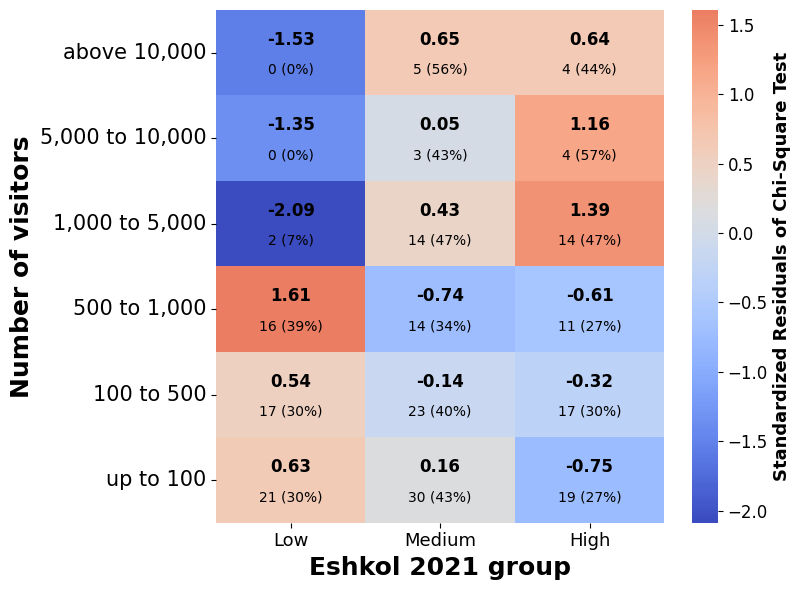

In [76]:


# =========================
# Define categorical order
# =========================
visitors_order = [
    "up to 100", "100 to 500", "500 to 1,000",
    "1,000 to 5,000", "5,000 to 10,000", "above 10,000"
]

eshkol_group_order = ["Low", "Medium", "High"]

groups = {
    "Low":    (1, 4, "red"),
    "Medium": (5, 7, "orange"),
    "High":   (8, 10, "limegreen"),
}

# =========================
# Prepare data
# =========================
ginot = ginot.copy()

ginot[N_VISITORS_PER_YEAR] = pd.Categorical(
    ginot[N_VISITORS_PER_YEAR],
    categories=visitors_order,
    ordered=True
)

ginot[ESHKOL_2021] = pd.to_numeric(ginot[ESHKOL_2021], errors="coerce")
ginot = ginot[ginot[ESHKOL_2021].between(1, 10, inclusive="both")].copy()

# =========================
# Convert raw ESHKOL_2021 to 3 groups
# =========================
def map_eshkol_group(x):
    for group_name, (low, high, _) in groups.items():
        if low <= x <= high:
            return group_name
    return np.nan

ginot["ESHKOL_GROUP"] = ginot[ESHKOL_2021].apply(map_eshkol_group)

ginot["ESHKOL_GROUP"] = pd.Categorical(
    ginot["ESHKOL_GROUP"],
    categories=eshkol_group_order,
    ordered=True
)

# =========================
# Contingency table
# =========================
counts = (
    ginot
    .groupby([N_VISITORS_PER_YEAR, "ESHKOL_GROUP"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=visitors_order, columns=eshkol_group_order, fill_value=0)
    .iloc[::-1]
)

# =========================
# Remove empty rows/columns for chi-square
# =========================
nonzero_rows = counts.sum(axis=1) > 0
nonzero_cols = counts.sum(axis=0) > 0
counts_for_chi2 = counts.loc[nonzero_rows, nonzero_cols]

# =========================
# Chi-square standardized residuals
# =========================
_, _, _, expected = chi2_contingency(counts_for_chi2)
residuals_small = (counts_for_chi2 - expected) / np.sqrt(expected)

residuals = pd.DataFrame(
    0.0,
    index=counts.index,
    columns=counts.columns
)
residuals.loc[residuals_small.index, residuals_small.columns] = residuals_small

# =========================
# Row-wise percentages
# =========================
row_sums = counts.sum(axis=1).replace(0, np.nan)
row_pct = counts.div(row_sums, axis=0) * 100
row_pct = row_pct.fillna(0)

# =========================
# Colormap
# =========================
base_cmap = plt.cm.get_cmap("coolwarm")
light_red_cmap = LinearSegmentedColormap.from_list(
    "coolwarm_lightred",
    base_cmap(np.linspace(0, 0.92, 256))
)

# =========================
# Plot heatmap
# =========================
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    residuals,
    cmap=light_red_cmap,
    center=0,
    ax=ax,
    cbar_kws={"label": "Standardized Residuals of Chi-Square Test"}
)

# =========================
# Manual cell annotations
# =========================
for y in range(residuals.shape[0]):
    for x in range(residuals.shape[1]):
        ax.text(
            x + 0.5, y + 0.35,
            f"{residuals.iloc[y, x]:.2f}",
            ha="center", va="center",
            fontsize=12, fontweight="bold", color="black"
        )

        ax.text(
            x + 0.5, y + 0.70,
            f"{counts.iloc[y, x]} ({row_pct.iloc[y, x]:.0f}%)",
            ha="center", va="center",
            fontsize=10, color="black"
        )

# =========================
# Axis labels and styling
# =========================
ax.set_xlabel("Eshkol 2021 group", fontsize=18, fontweight="bold")
ax.set_ylabel("Number of visitors", fontsize=18, fontweight="bold")

ax.set_xticklabels(ax.get_xticklabels(), fontsize=13, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=15, rotation=0)

# =========================
# Colorbar styling
# =========================
cbar = ax.collections[0].colorbar
cbar.set_label(
    "Standardized Residuals of Chi-Square Test",
    fontsize=13,
    fontweight="bold"
)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(fig_path("chi_square_residuals_heatmap_grouped.png"), dpi=300)
plt.show()

*City color map*


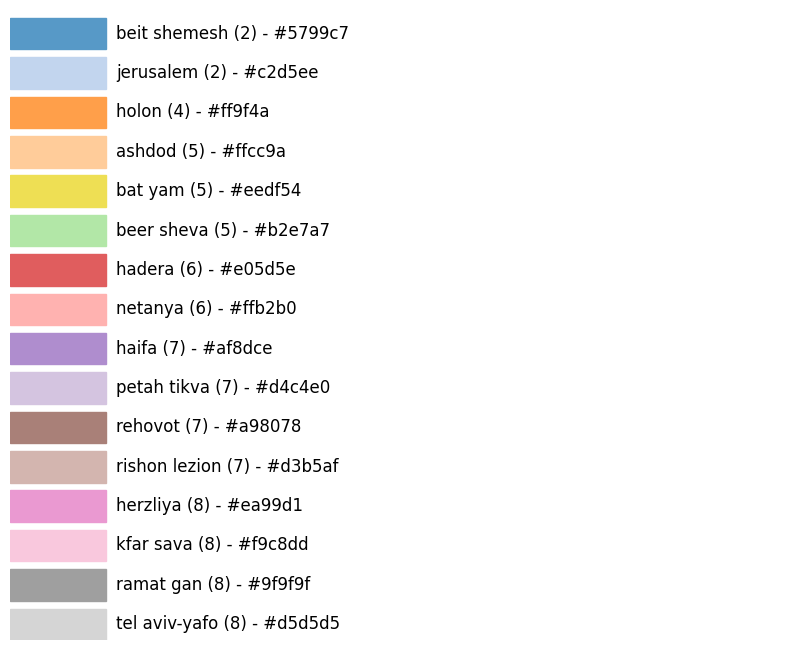

In [77]:
fig_map, ax_map = plt.subplots(figsize=(8, 0.35 * len(sorted_for_legend) + 1))
ax_map.set_axis_off()

for i, c in enumerate(sorted_for_legend):
    y_pos = len(sorted_for_legend) - 1 - i
    ax_map.add_patch(Rectangle((0, y_pos), 1, 0.8, color=CITY_COLOR_MAP[c]))
    ax_map.text(1.1, y_pos + 0.4, f"{c} ({int(round(city_avg[c]))}) - {mcolors.to_hex(CITY_COLOR_MAP[c])}", va="center", fontsize=12)

ax_map.set_xlim(0, 8)
ax_map.set_ylim(0, len(sorted_for_legend))
plt.tight_layout()
plt.show()

################################

**### City Map ###**

###############################

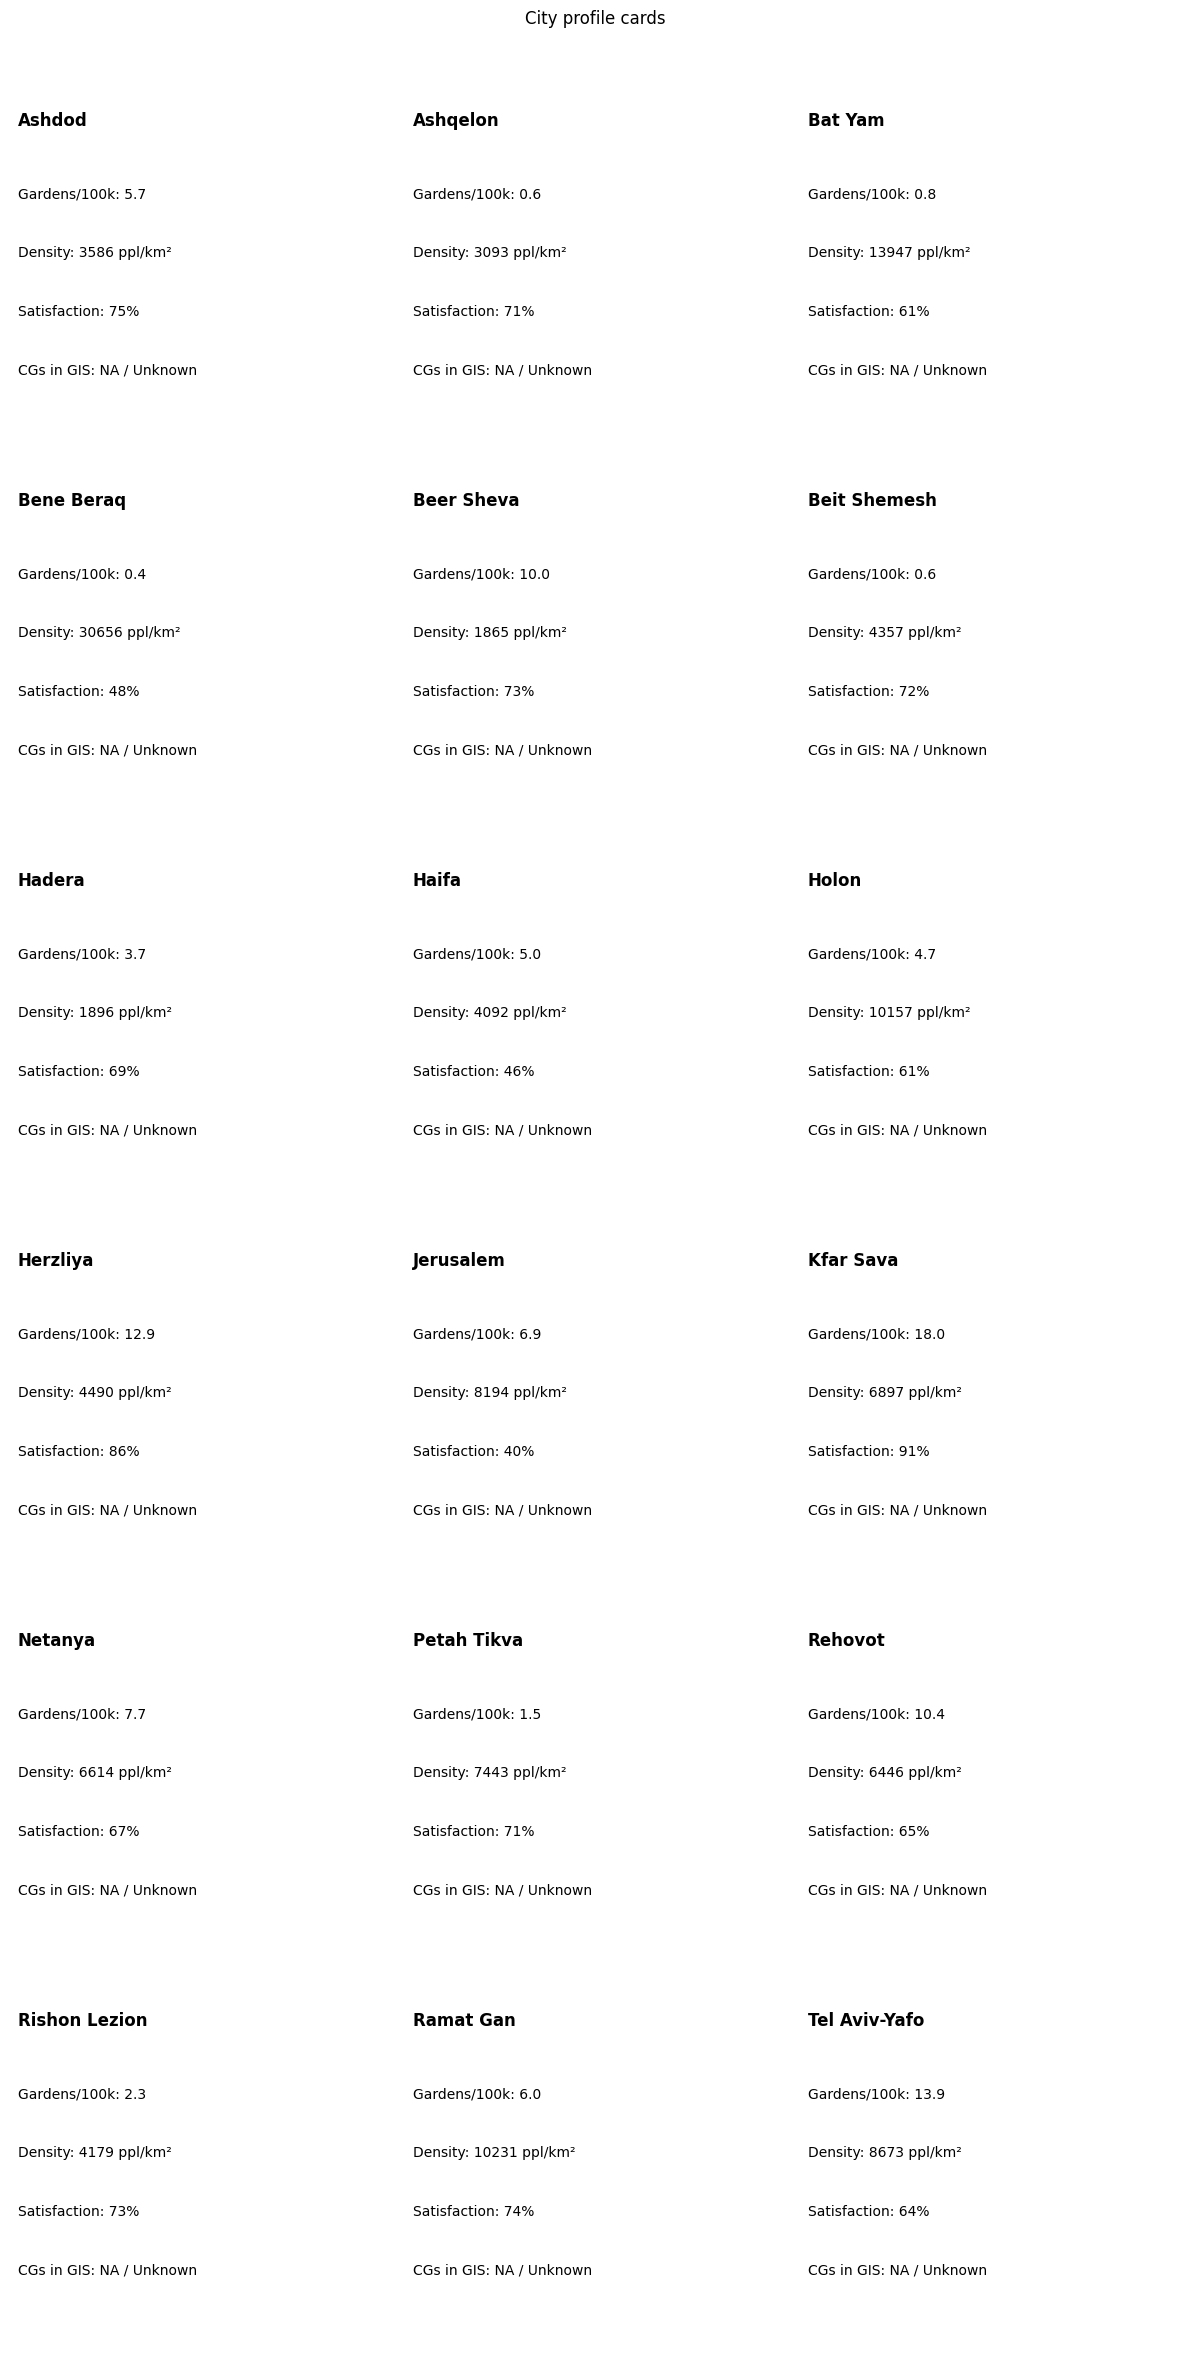

In [78]:

cards = cities.copy()
cards["gardens_per_100k"] = (cards[N_COMMUNITY_GARDENS] / cards[POP_2023])*1e5
cards["density"] = cards[POP_2023] / cards[AREA_KM2]

# Detect GIS column safely
gis_col = "GIS_cat4" if "GIS_cat4" in cards.columns else None

n = len(cards)
cols = 3
rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
axes = np.ravel(axes)

for ax, (_, r) in zip(axes, cards.iterrows()):
    ax.axis("off")
    title = str(r[CITY]).title()
    ax.text(0.02, 0.88, title, fontsize=12, fontweight="bold", transform=ax.transAxes)
    ax.text(0.02, 0.68, f"Gardens/100k: {r['gardens_per_100k']:.1f}", fontsize=10, transform=ax.transAxes)
    ax.text(0.02, 0.52, f"Density: {r['density']:.0f} ppl/km²", fontsize=10, transform=ax.transAxes)
    ax.text(0.02, 0.36, f"Satisfaction: {r[SAT_PARKS_PCT]:.0f}%", fontsize=10, transform=ax.transAxes)

    # Display the GIS classification when available.
    gis_value = r[gis_col] if gis_col else "NA / Unknown"
    ax.text(0.02, 0.20, f"CGs in GIS: {gis_value}", fontsize=10, transform=ax.transAxes)

# Hide unused axes
for k in range(len(cards), len(axes)):
    axes[k].axis("off")

plt.suptitle("City profile cards", y=0.98)
plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig(fig_path("city_profile_cards.png"), dpi=300)
plt.show()


In [79]:
print("shape:", ginot.shape)
print("first cols:", list(ginot.columns)[:15])
lon_col = LON_WGS84
lat_col = LAT_WGS84
city_col = CITY
print(ginot[[lon_col, lat_col, city_col]].head(5))

tmp_lon = pd.to_numeric(ginot[lon_col].astype(str).str.replace(",", ".", regex=False), errors="coerce")
tmp_lat = pd.to_numeric(ginot[lat_col].astype(str).str.replace(",", ".", regex=False), errors="coerce")
print("lon median(abs):", tmp_lon.abs().median(), "lat median(abs):", tmp_lat.abs().median())
print("bbox ok:", ((tmp_lon.between(34,36.5) & tmp_lat.between(29,33.5)).sum()))
print("bbox swapped ok:", ((tmp_lat.between(34,36.5) & tmp_lon.between(29,33.5)).sum()))

shape: (291, 41)
first cols: ['department responsible', "gis's layer of cgs? points/polygon/non", 'city area (km2)', 'density for km2', 'green areas gis (km2)', '# unites of green areas', 'mean area', 'satisfaction with parks and green spaces in the residential area %', 'density in built area (person per km2)', 'forest and woodland (km2)', 'parks and gardens (km2)', 'culture, leisure, vacation, and sport (km2)', 'no. pupils in the city', 'no of schools in the city', 'avg salary']
   x_longitude by wgs84  y_latitude by wgs84    city
0             34.648075            31.807079  ashdod
1             34.651707            31.810674  ashdod
2             34.654679            31.805601  ashdod
3             34.653029            31.807056  ashdod
4             34.659931            31.797589  ashdod
lon median(abs): 34.83153958 lat median(abs): 32.04640261
bbox ok: 291
bbox swapped ok: 0


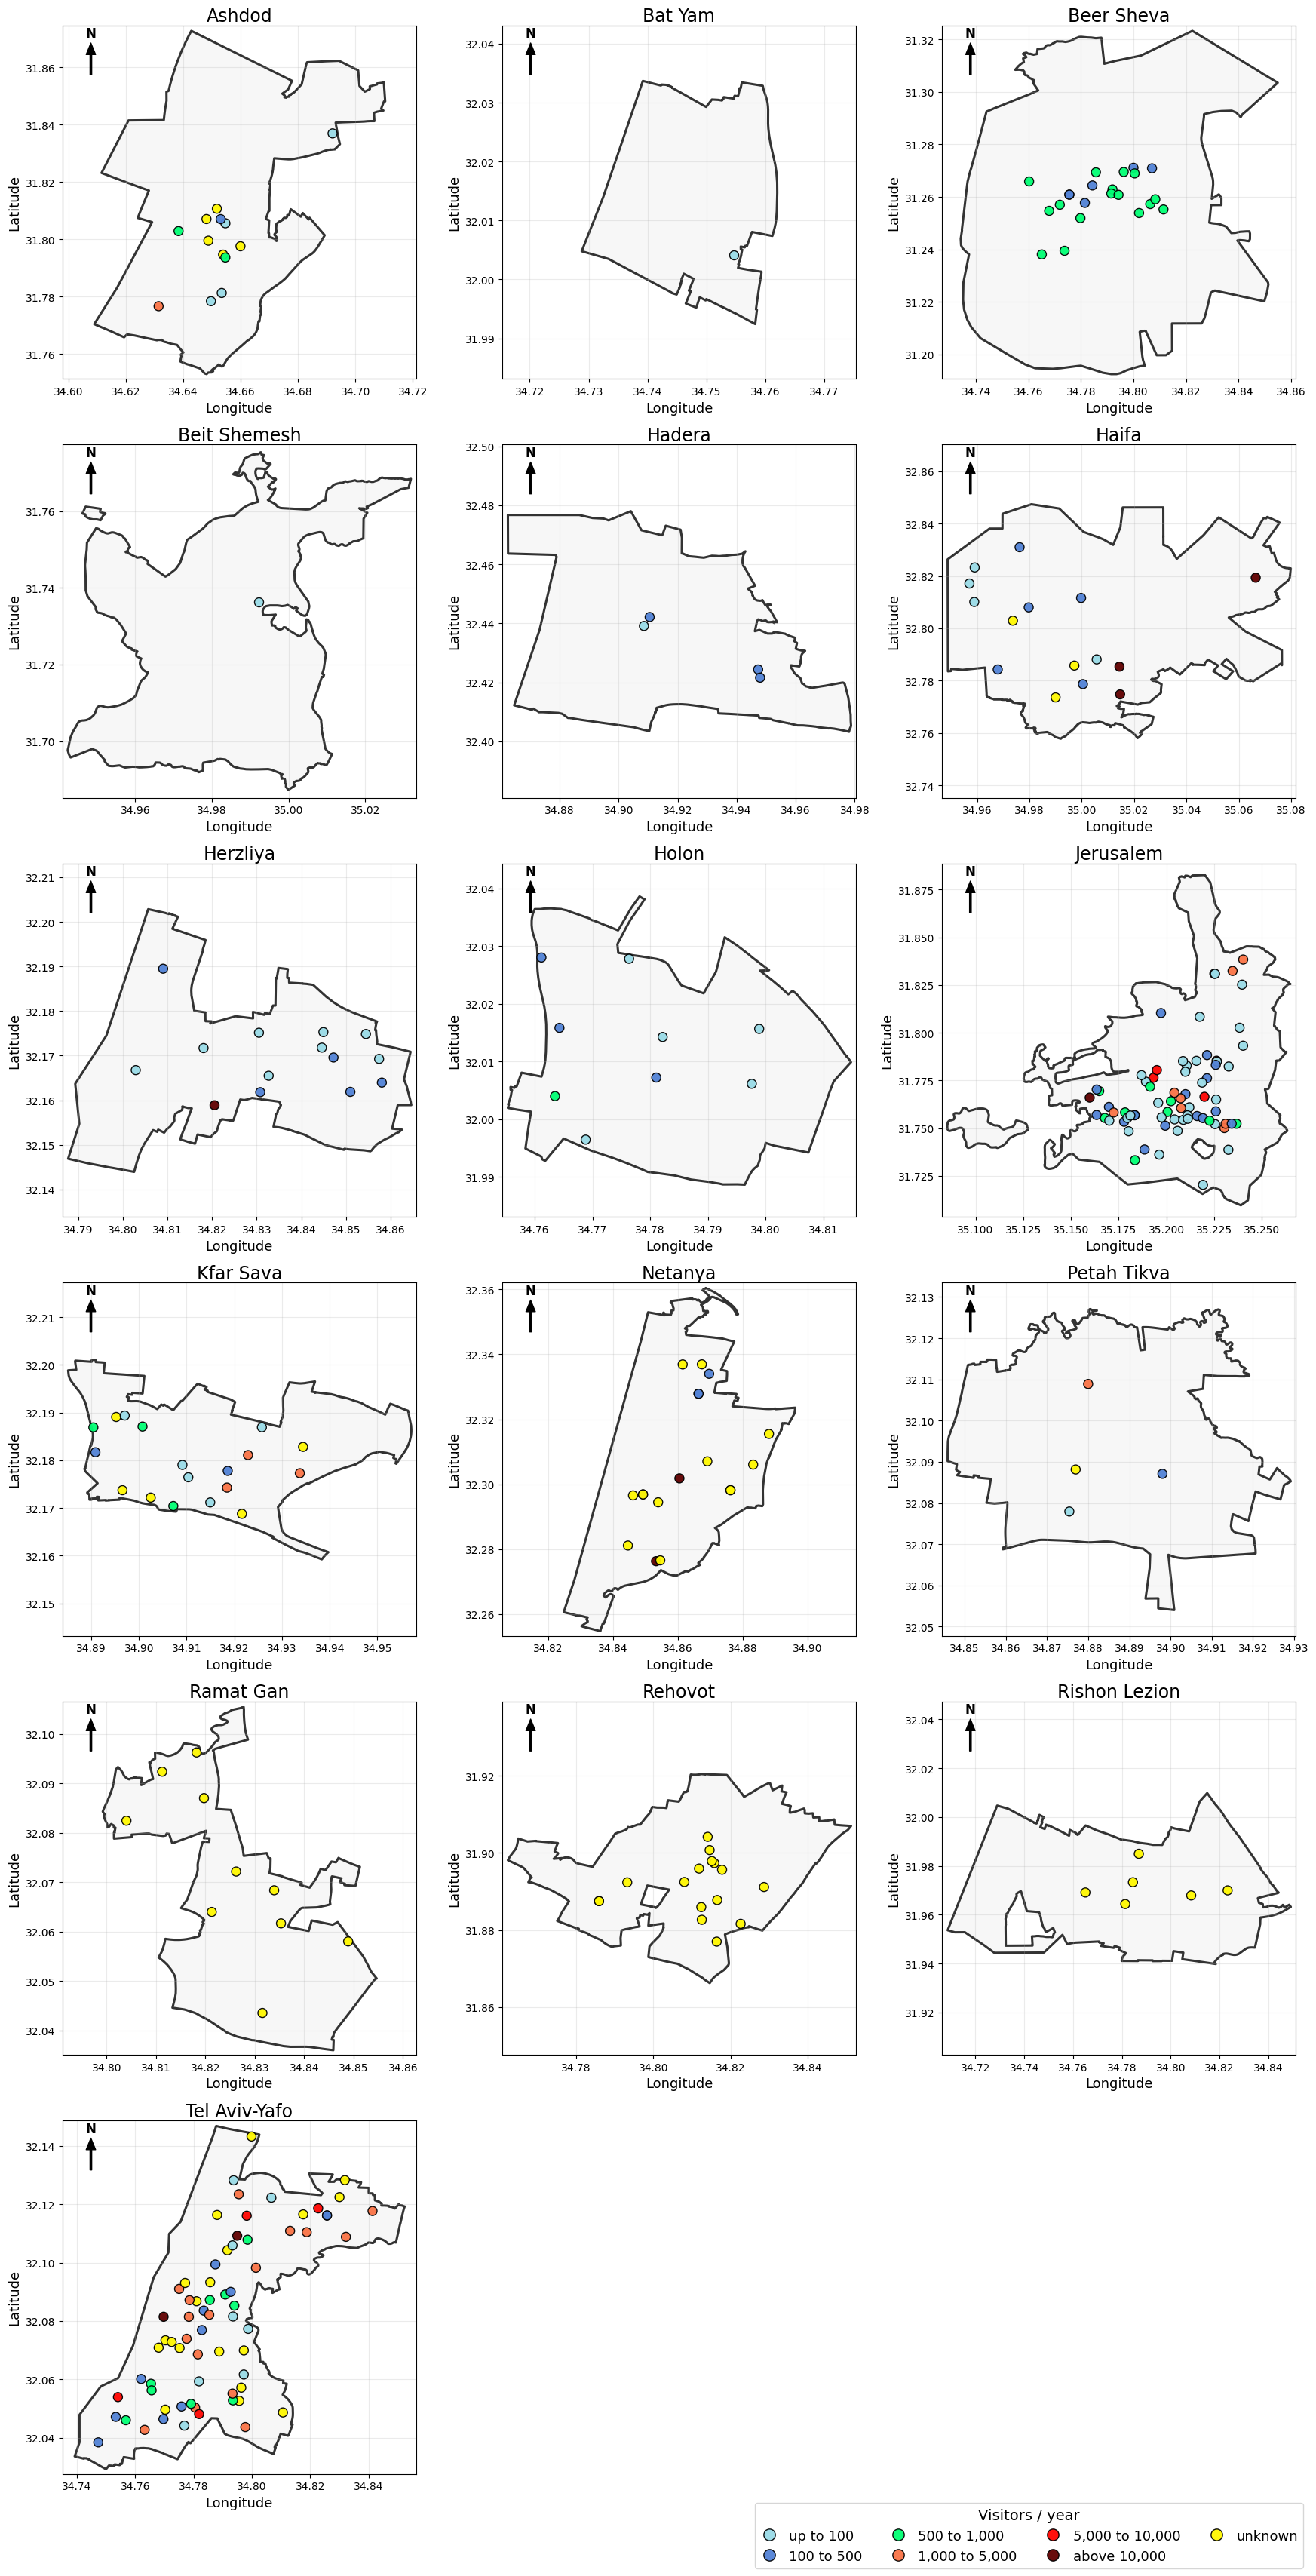

In [80]:
# -------- Tunables --------
PANEL_SIZE_INCH    = 6
SIDE_PAD_FACTOR    = 1.03
MIN_SIDE_DEG       = 0.06
POINT_SIZE         = 75
BOUNDARY_LW        = 2.2

# North arrow
ARROW_POS_FRAC     = (0.08, 0.86)
ARROW_FIXED_LEN_KM = 4.0
ARROW_STYLE = dict(facecolor="black", edgecolor="black",
                   width=1.6, headwidth=9, headlength=11)

# -------- Columns / palette --------
lon_col  = LON_WGS84
lat_col  = LAT_WGS84
city_col = CITY
vis_col  = N_VISITORS_PER_YEAR

order = ["up to 100","100 to 500","500 to 1,000","1,000 to 5,000","5,000 to 10,000","above 10,000","unknown"]
PALETTE = {
    "up to 100": "#99DBE7", "100 to 500": "#5282d6", "500 to 1,000": "#00ff73",
    "1,000 to 5,000": "#fa7346", "5,000 to 10,000": "#FF0400", "above 10,000": "#600000",
    "unknown": "#fff700",
}

# -------- Data prep (robust) --------
for col in [lon_col, lat_col]:
    ginot[col] = (ginot[col].astype(str)
                            .str.replace(",", ".", regex=False)
                            .str.strip())
    ginot[col] = pd.to_numeric(ginot[col], errors="coerce")

ok = ginot[lon_col].between(34.0, 36.5) & ginot[lat_col].between(29.0, 33.5)
ok_swapped = ginot[lat_col].between(34.0, 36.5) & ginot[lon_col].between(29.0, 33.5)

if ok.sum() < ok_swapped.sum():
    ginot[lon_col], ginot[lat_col] = ginot[lat_col].copy(), ginot[lon_col].copy()
    ok = ok_swapped

df = ginot.loc[ok].copy()
if df.empty:
    raise ValueError("No valid points after cleaning coordinates (check lon/lat columns or values).")

# visitors -> string/categorical (assumes already binned into the 'order' labels)
if vis_col in df.columns:
    df[vis_col] = df[vis_col].astype("string").fillna("unknown")
else:
    df[vis_col] = "unknown"

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df[lon_col], df[lat_col]), crs=4326)
gdf[vis_col] = pd.Categorical(gdf[vis_col], categories=order, ordered=True)

# city normalization + display names
NAME_FIX = {
    "herzliya":"Herzliya","הרצליה":"Herzliya",
    "kfar-sava":"Kfar Sava","כפר-סבא":"Kfar Saba",
    "beit-shemesh":"Beit Shemesh",
    "בת-ים":"Bat Yam",
    "tel aviv":"Tel Aviv-Yafo","תל אביב-יפו":"Tel Aviv-Yafo"
}
norm = lambda s: str(s).strip().lower().replace("־","-").replace("–","-").replace("—","-")
gdf["_city_norm"] = gdf[city_col].astype(str).map(norm)
gdf["_city_q"]    = gdf[city_col].astype(str).map(lambda x: NAME_FIX.get(norm(x), x))

# Preserve the existing city-level DataFrame defined earlier in the notebook.
city_list = (
    gdf[["_city_norm","_city_q",city_col]]
      .dropna(subset=[city_col])
      .drop_duplicates()
      .sort_values(city_col)
      .to_dict("records")
)
if len(city_list) == 0:
    raise ValueError("No cities found in data (city column empty after filtering).")

# -------- Boundary cache --------
CACHE_DIR, CACHE_GPKG = "cache", os.path.join("cache","city_boundaries.gpkg")
os.makedirs(CACHE_DIR, exist_ok=True)

def load_cache():
    if os.path.exists(CACHE_GPKG):
        try:
            cg = gpd.read_file(CACHE_GPKG)
            if cg.crs is None:
                cg = cg.set_crs(4326, allow_override=True)
            if cg.crs.to_epsg() != 4326:
                cg = cg.to_crs(4326)
            return cg
        except Exception:
            pass
    return gpd.GeoDataFrame(columns=["_city_norm","city_label","geometry"], geometry="geometry", crs=4326)

def save_cache(cg):
    cg.to_file(CACHE_GPKG, driver="GPKG")

cache_g = load_cache()

def fetch_boundary_for_city(sub_points, label_for_query):
    centroid = sub_points.unary_union.centroid
    center_xy = (centroid.y, centroid.x)

    try:
        g = ox.features_from_point(center_xy, tags={"boundary":"administrative"}, dist=25000).to_crs(4326)
        g = g[~g.geometry.is_empty & g.geometry.notna()]
    except Exception:
        g = gpd.GeoDataFrame(columns=["geometry"], geometry="geometry", crs=4326)

    if g.empty:
        return None

    if "admin_level" in g.columns:
        for lvl in ("8","7","6"):
            cand = g[g["admin_level"].astype(str).str.contains(rf"\b{lvl}\b", na=False)]
            if not cand.empty:
                g = cand.copy()
                break

    # prefer polygons containing the centroid
    g = g[g.geometry.apply(lambda geom: geom.contains(centroid) or geom.covers(centroid))]

    if g.empty:
        g["dist"] = g.geometry.distance(centroid)
        g = g.sort_values("dist").head(5)

    def score_row(row):
        geom = row.geometry
        inside = sub_points.within(geom) | sub_points.geometry.apply(lambda p: geom.buffer(0).covers(p))
        frac = float(inside.sum()) / len(sub_points)
        area = gpd.GeoSeries([geom], crs=4326).to_crs(3857).area.iloc[0]
        return pd.Series({"frac": frac, "area": float(area)})

    g = g.join(g.apply(score_row, axis=1)).sort_values(by=["frac","area"], ascending=[False, True])
    return g.iloc[0].geometry

needed = {c["_city_norm"]: c for c in city_list}
have = set(cache_g["_city_norm"].tolist()) if "_city_norm" in cache_g.columns else set()

for c_norm, rec in needed.items():
    if c_norm in have:
        continue
    sub = gdf[gdf["_city_norm"] == c_norm]
    if sub.empty:
        continue
    geom = fetch_boundary_for_city(sub, rec["_city_q"]) or sub.unary_union.convex_hull.buffer(0.001)
    cache_g.loc[len(cache_g)] = {"_city_norm": c_norm, "city_label": rec[city_col], "geometry": geom}

save_cache(cache_g)

# -------- Per-city square extent --------
meta = []
for rec in city_list:
    poly_series = cache_g.loc[cache_g["_city_norm"] == rec["_city_norm"], "geometry"]
    if poly_series.empty:
        continue
    poly = poly_series.iloc[0]
    xmin, ymin, xmax, ymax = poly.bounds
    w, h = xmax - xmin, ymax - ymin
    side_i = max(w, h)
    side_i = max(side_i * SIDE_PAD_FACTOR, MIN_SIDE_DEG)
    cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
    meta.append({"_city_norm": rec["_city_norm"], "label": rec[city_col], "poly": poly,
                 "cx": cx, "cy": cy, "side": side_i})

if len(meta) == 0:
    raise ValueError("meta is empty: no boundaries found/created for any city.")

# -------- North arrow --------
GEOD = Geod(ellps="WGS84")

def add_north_arrow_geo(ax, xlim, ylim):
    xmin, xmax = xlim
    ymin, ymax = ylim
    x0 = xmin + ARROW_POS_FRAC[0] * (xmax - xmin)
    y0 = ymin + ARROW_POS_FRAC[1] * (ymax - ymin)
    lon1, lat1, _ = GEOD.fwd(x0, y0, 0.0, ARROW_FIXED_LEN_KM * 1000.0)

    margin = 0.05 * (ymax - ymin)
    if lat1 > ymax - margin:
        t = (ymax - margin - y0) / (lat1 - y0) if (lat1 - y0) != 0 else 1.0
        lon1 = x0 + t * (lon1 - x0)
        lat1 = ymax - margin

    ax.annotate("", xy=(lon1, lat1), xytext=(x0, y0), xycoords="data",
                arrowprops=ARROW_STYLE, zorder=3)
    ax.text(lon1, lat1 + 0.008 * (ymax - ymin), "N",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

# -------- Plot --------
n = len(meta)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(PANEL_SIZE_INCH * ncols, PANEL_SIZE_INCH * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, m in zip(axes, meta):
    poly, cx, cy, side_i = m["poly"], m["cx"], m["cy"], m["side"]
    half = side_i / 2.0
    xlim = (cx - half, cx + half)
    ylim = (cy - half, cy + half)

    gpd.GeoSeries([poly], crs=4326).plot(ax=ax, color="#f7f7f7",
                                         edgecolor="#333", linewidth=BOUNDARY_LW, zorder=1)

    sub = gdf[gdf["_city_norm"] == m["_city_norm"]]
    ax.scatter(sub[lon_col], sub[lat_col], s=POINT_SIZE,
               c=sub[vis_col].map(PALETTE), edgecolors="black", alpha=0.95, zorder=2)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    add_north_arrow_geo(ax, xlim, ylim)

    ax.set_title(str(m["label"]).title(), fontsize=17, pad=4)
    ax.set_xlabel("Longitude", fontsize=13)
    ax.set_ylabel("Latitude", fontsize=13)
    ax.grid(alpha=0.25)

for k in range(len(meta), len(axes)):
    axes[k].axis("off")

# -------- Legend --------
present = [lab for lab in order if lab in gdf[vis_col].unique().tolist()]
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=PALETTE[lab], markeredgecolor="black",
           label=lab, markersize=11, alpha=0.95)
    for lab in present
]

fig.legend(
    handles=handles,
    title="Visitors / year",
    loc="lower right",
    ncol=4,
    bbox_to_anchor=(0.98, 0.03),
    prop={"size": 13},
    title_fontsize=14,
    handlelength=1.3
)

plt.tight_layout(rect=[0.01, 0.05, 0.99, 0.98])
plt.savefig(fig_path("city_maps_by_city.png"), dpi=300)
plt.show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Derived variable: nearby gathering centers

In [81]:
# Identify the relevant column name.
loc_col = next(c for c in ginot.columns if CAT_SPECIAL_LOCATION in c.lower())

# List of meeting point locations (only what you requested)
GATHER_CENTERS = {
    "community center",
    "neighborhood", "neighborhood garden",
    "senior center", "youth center", "youth movement",
    "absorption center",
    "religious center",
    "library", "museum",
    "university",
    "school", "kindergarten", "school_or_kg", "school or kg",
    "sports facility",
    "post office",
    "promenade",
    "bar",
    "bomb shelter",
    "historic site",
    "soup kitchen",
}

# Function to normalize a list from each cell
def normalize_to_list(x):
    if pd.isna(x): 
        return []
    s = str(x).lower().strip()
    s = s.replace("_", " ").replace("-", " ")
    parts = [re.sub(r"\s+", " ", p.strip()) for p in s.split(",")]
    return [p for p in parts if p]

tags_series = ginot[loc_col].apply(normalize_to_list)

# Function that returns how many meeting point terms appeared
def count_gather_centers(tags):
    return sum(1 for t in tags if t in GATHER_CENTERS)

ginot["gathering_centers_count"] = tags_series.apply(count_gather_centers)

# Control
print(ginot["gathering_centers_count"].value_counts().sort_index())

# Gardent that is whithin 3 gathering centers
print("\nGardens within 3 gathering centers:")
pd.set_option('display.max_colwidth', None) 
print(ginot.loc[ginot["gathering_centers_count"] == 3,[ID_GINA, CITY, CAT_SPECIAL_LOCATION]])

# Gardent that is whithin 4 gathering centers
print("\nGardens within 4 gathering centers:")
print(ginot.loc[ginot["gathering_centers_count"] == 4,[ID_GINA, CITY, CAT_SPECIAL_LOCATION]])


gathering_centers_count
0    291
Name: count, dtype: int64

Gardens within 3 gathering centers:
Empty DataFrame
Columns: [id_gina, city, cat_special_location]
Index: []

Gardens within 4 gathering centers:
Empty DataFrame
Columns: [id_gina, city, cat_special_location]
Index: []


## Added section — descriptive tables only

This section was added without changing the original plots or the original modeling cells.


In [82]:
# ============================================
#  ADDED SECTION: DESCRIPTIVE STATISTICS (tables only)
# ============================================

# Ordered categories used in the added descriptive tables
visitors_order_added = [
    "up to 100", "100 to 500", "500 to 1,000",
    "1,000 to 5,000", "5,000 to 10,000", "above 10,000"
]

members_order_added = [
    "up to 10", "10 to 20", "20 to30", "30 to 40", "above 40"
]

activity_map_added = {
    "0-1 years": 0,
    "1-3 years": 1,
    "3-7 years": 2,
    "above 7 years": 3
}

member_map_added = {
    "up to 10": 0,
    "10 to 20": 1,
    "20 to 30": 2,
    "30 to 40": 3,
    "above 40": 4
}

desc_df = ginot.copy()
desc_df[CITY] = desc_df[CITY].astype("string").str.strip().str.lower()

# When city-level variables are absent from the garden-level table, merge selected city-level variables for descriptive reporting.
if 'cities' in globals():
    cities_desc = cities.copy()
    cities_desc[CITY] = cities_desc[CITY].astype("string").str.strip().str.lower()
    candidate_city_cols_added = [
        CITY,
        POP_2023,
        AREA_KM2,
        GREEN_AREAS_KM2,
        SAT_PARKS_PCT,
        N_COMMUNITY_GARDENS,
        CITY_AVG_ESHKOL_2021,
    ]
    city_cols_available_added = [c for c in candidate_city_cols_added if c in cities_desc.columns]
    if city_cols_available_added:
        city_subset_added = cities_desc[city_cols_available_added].drop_duplicates(subset=[CITY]).copy()
        desc_df = desc_df.merge(city_subset_added, on=CITY, how="left", suffixes=("", "_citydesc"))

# Derived city features
if (GREEN_AREAS_KM2 in desc_df.columns) and (AREA_KM2 in desc_df.columns):
    desc_df["city_green_share_added"] = (
        pd.to_numeric(desc_df[GREEN_AREAS_KM2], errors="coerce") /
        (pd.to_numeric(desc_df[AREA_KM2], errors="coerce") * 1_000_000)
    )

if (POP_2023 in desc_df.columns) and (AREA_KM2 in desc_df.columns):
    desc_df["city_pop_density_added"] = (
        pd.to_numeric(desc_df[POP_2023], errors="coerce") /
        pd.to_numeric(desc_df[AREA_KM2], errors="coerce")
    )

if (N_COMMUNITY_GARDENS in desc_df.columns) and (POP_2023 in desc_df.columns):
    desc_df["city_cgs_per_100k_added"] = (
        pd.to_numeric(desc_df[N_COMMUNITY_GARDENS], errors="coerce") /
        pd.to_numeric(desc_df[POP_2023], errors="coerce")
    ) * 100_000

# Ordered outcomes for tables
desc_df["visitors_ord_added"] = pd.Categorical(
    desc_df[N_VISITORS_PER_YEAR].astype("string").str.strip().str.lower(),
    categories=visitors_order_added,
    ordered=True
)

desc_df["members_ord_added"] = pd.Categorical(
    desc_df[N_ACTIVE_MEMBERS].astype("string").str.strip().str.lower(),
    categories=members_order_added,
    ordered=True
)

# Table 1 headline counts
summary_counts_added = pd.DataFrame({
    "metric": [
        "Total gardens",
        "Gardens with visitors data",
        "Gardens with active-members data",
        "Unique cities represented"
    ],
    "value": [
        len(desc_df),
        desc_df["visitors_ord_added"].notna().sum(),
        desc_df["members_ord_added"].notna().sum(),
        desc_df[CITY].nunique(dropna=True)
    ]
})
print("Table 1 headline counts")
display(summary_counts_added)

# Outcome distributions
visitors_dist_added = (
    desc_df["visitors_ord_added"]
    .value_counts(dropna=True)
    .reindex(visitors_order_added, fill_value=0)
    .rename("n")
    .to_frame()
)
visitors_dist_added["pct"] = (visitors_dist_added["n"] / visitors_dist_added["n"].sum() * 100).round(1)

members_dist_added = (
    desc_df["members_ord_added"]
    .value_counts(dropna=True)
    .reindex(members_order_added, fill_value=0)
    .rename("n")
    .to_frame()
)
members_dist_added["pct"] = (members_dist_added["n"] / members_dist_added["n"].sum() * 100).round(1)

print("Visitors distribution (6 categories)")
display(visitors_dist_added)

print("Active members distribution (5 categories)")
display(members_dist_added)

if ACTIVITY in desc_df.columns:
    activity_dist_added = (
        desc_df[ACTIVITY].astype("string").str.strip().str.lower()
        .value_counts(dropna=True)
        .rename_axis("activity_category")
        .rename("n")
        .to_frame()
    )
    activity_dist_added["pct"] = (activity_dist_added["n"] / activity_dist_added["n"].sum() * 100).round(1)
    print("Activity distribution")
    display(activity_dist_added)

# Numeric descriptive table with mean + median + IQR + spread
numeric_desc_added = pd.DataFrame(index=desc_df.index)
numeric_desc_added["garden_sei"] = pd.to_numeric(desc_df[ESHKOL_2021], errors="coerce")
numeric_desc_added["sei_gap"] = pd.to_numeric(desc_df[SEI_GAP], errors="coerce")
numeric_desc_added["gathering_centers_count"] = pd.to_numeric(desc_df.get("gathering_centers_count"), errors="coerce")
numeric_desc_added["members_score"] = pd.to_numeric(
    desc_df[N_ACTIVE_MEMBERS].astype("string").str.strip().str.lower().map(member_map_added),
    errors="coerce"
)
numeric_desc_added["activity_score"] = pd.to_numeric(
    desc_df[ACTIVITY].astype("string").str.strip().str.lower().map(activity_map_added),
    errors="coerce"
)

# Main paper-friendly funding measure: raw number of funding categories
if N_CATEGORIES_FUNDING in desc_df.columns:
    numeric_desc_added["funding_score"] = pd.to_numeric(desc_df[N_CATEGORIES_FUNDING], errors="coerce")
if "tilted_ncof" in desc_df.columns:
    numeric_desc_added["funding_score_tilted_sensitivity"] = pd.to_numeric(desc_df["tilted_ncof"], errors="coerce")
if CATEGORIES_COMMUNITIES in desc_df.columns:
    numeric_desc_added["communities_score"] = pd.to_numeric(desc_df[CATEGORIES_COMMUNITIES], errors="coerce")

optional_added_cols = [
    SAT_PARKS_PCT,
    CITY_AVG_ESHKOL_2021,
    "city_green_share_added",
    "city_pop_density_added",
    "city_cgs_per_100k_added",
]
for col in optional_added_cols:
    if col in desc_df.columns:
        out_name = col.replace("_added", "")
        numeric_desc_added[out_name] = pd.to_numeric(desc_df[col], errors="coerce")

descriptive_table_added = pd.DataFrame({
    "non_missing_n": numeric_desc_added.notna().sum(),
    "mean": numeric_desc_added.mean(numeric_only=True),
    "median": numeric_desc_added.median(numeric_only=True),
    "q1": numeric_desc_added.quantile(0.25, numeric_only=True),
    "q3": numeric_desc_added.quantile(0.75, numeric_only=True),
    "std": numeric_desc_added.std(numeric_only=True),
    "min": numeric_desc_added.min(numeric_only=True),
    "max": numeric_desc_added.max(numeric_only=True),
}).round(3)

print("Descriptive statistics for numeric variables (Table 1 style)")
descriptive_table_added.to_csv(fig_path("data_descriptive_statistics.csv"))
display(descriptive_table_added)



Table 1 headline counts


,metric,value
0,Total gardens,291
1,Gardens with visitors data,214
2,Gardens with active-members data,204
3,Unique cities represented,16


Visitors distribution (6 categories)


,n,pct
visitors_ord_added,,
up to 100,70,32.7
100 to 500,57,26.6
"500 to 1,000",41,19.2
"1,000 to 5,000",30,14.0
"5,000 to 10,000",7,3.3
"above 10,000",9,4.2


Active members distribution (5 categories)


,n,pct
members_ord_added,,
up to 10,107,52.5
10 to 20,76,37.3
20 to30,0,0.0
30 to 40,8,3.9
above 40,13,6.4


Activity distribution


,n,pct
activity_category,,
above 7 years,166,59.5
3-7 years,65,23.3
1-3 years,38,13.6
0-1 years,10,3.6


Descriptive statistics for numeric variables (Table 1 style)


,non_missing_n,mean,median,q1,q3,std,min,max
garden_sei,291,6.216,7.0,5.0,8.0,2.464,1.0,10.0
sei_gap,291,0.488,1.0,-1.0,2.0,2.502,-5.0,7.0
gathering_centers_count,291,0.0,0.0,0.0,0.0,0.0,0.0,0.0
members_score,227,0.872,1.0,0.0,1.0,1.104,0.0,4.0
activity_score,279,2.387,3.0,2.0,3.0,0.853,0.0,3.0
funding_score,291,1.773,2.0,1.0,2.0,0.772,1.0,5.0
funding_score_tilted_sensitivity,291,1.773,2.0,1.0,2.0,0.772,1.0,5.0
communities_score,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
satisfaction with parks and green spaces in the residential area %,291,61.93,64.0,45.8,73.1,15.562,39.9,90.8
city avg sei 2021,291,5.729,7.0,4.0,8.0,2.412,2.0,8.0


The first table summarizes the data distribution, including the number of represented cities, the amount of usable data after cleaning, and the amount of data before cleaning.


The following three tables report the distributions of the analytical features in both counts and percentages.


The final table provides descriptive statistics for each feature, including missing values, mean, median, quartiles, minimum, and maximum.


## Added section — revised statistical modeling (MAIN INFERENTIAL BLOCK)

This is the main inferential workflow to use for the paper.

Use this block as the primary analysis:
- descriptive tables
- modeling table after city merge
- bivariate statistics and multicollinearity
- main ordered-logit model
- sensitivity analyses
- secondary ordered-logit model for active members

The older ML cells above remain untouched for traceability, but they are not the primary inferential analysis.


In [83]:
# ============================================
#  ADDED SECTION: BUILD ONE MODELING TABLE (garden + city)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

visitors_order_stat = [
    "up to 100",
    "100 to 500",
    "500 to 1,000",
    "1,000 to 5,000",
    "5,000 to 10,000",
    "above 10,000"
]

members_order_stat = [
    "up to 10",
    "10 to 20",
    "20 to 30",
    "30 to 40",
    "above 40"
]

activity_map_stat = {
    "0-1 years": 0,
    "1-3 years": 1,
    "3-7 years": 2,
    "above 7 years": 3
}

ginot_model_stat = ginot.copy()
cities_model_stat = cities.copy()

ginot_model_stat[CITY] = ginot_model_stat[CITY].astype("string").str.strip().str.lower()
cities_model_stat[CITY] = cities_model_stat[CITY].astype("string").str.strip().str.lower()

candidate_city_cols_stat = [
    CITY,
    POP_2023,
    AREA_KM2,
    GREEN_AREAS_KM2,
    SAT_PARKS_PCT,
    N_COMMUNITY_GARDENS,
    CITY_AVG_ESHKOL_2021
]
city_cols_available_stat = [c for c in candidate_city_cols_stat if c in cities_model_stat.columns]
city_subset_stat = cities_model_stat[city_cols_available_stat].drop_duplicates(subset=[CITY]).copy()

model_df_stat = ginot_model_stat.merge(
    city_subset_stat,
    on=CITY,
    how="left",
    suffixes=("", "_cityfile")
)

if (GREEN_AREAS_KM2 in model_df_stat.columns) and (AREA_KM2 in model_df_stat.columns):
    model_df_stat["city_green_share"] = (
        pd.to_numeric(model_df_stat[GREEN_AREAS_KM2], errors="coerce") /
        (pd.to_numeric(model_df_stat[AREA_KM2], errors="coerce") * 100)
    )

if (POP_2023 in model_df_stat.columns) and (AREA_KM2 in model_df_stat.columns):
    model_df_stat["city_pop_density"] = (
        pd.to_numeric(model_df_stat[POP_2023], errors="coerce") /
        pd.to_numeric(model_df_stat[AREA_KM2], errors="coerce")
    )

if (N_COMMUNITY_GARDENS in model_df_stat.columns) and (POP_2023 in model_df_stat.columns):
    model_df_stat["city_cgs_per_100k"] = (
        pd.to_numeric(model_df_stat[N_COMMUNITY_GARDENS], errors="coerce") /
        pd.to_numeric(model_df_stat[POP_2023], errors="coerce")
    ) * 100_000

model_df_stat["visitors_ord"] = pd.Categorical(
    model_df_stat[N_VISITORS_PER_YEAR].astype("string").str.strip().str.lower(),
    categories=visitors_order_stat,
    ordered=True
)

model_df_stat["members_ord"] = pd.Categorical(
    model_df_stat[N_ACTIVE_MEMBERS].astype("string").str.strip().str.lower(),
    categories=members_order_stat,
    ordered=True
)

model_df_stat["garden_sei"] = pd.to_numeric(model_df_stat[ESHKOL_2021], errors="coerce")
model_df_stat["sei_gap"] = pd.to_numeric(model_df_stat[SEI_GAP], errors="coerce")
model_df_stat["members_score"] = model_df_stat["members_ord"].cat.codes.replace(-1, np.nan)
model_df_stat["activity_score"] = model_df_stat[ACTIVITY].astype("string").str.strip().str.lower().map(activity_map_stat)
model_df_stat["gathering_centers_count"] = pd.to_numeric(model_df_stat.get("gathering_centers_count"), errors="coerce")
model_df_stat["has_gathering_center"] = (model_df_stat["gathering_centers_count"].fillna(0) > 0).astype(float)

# Main paper-friendly funding measure
model_df_stat["funding_score"] = pd.to_numeric(model_df_stat.get(N_CATEGORIES_FUNDING), errors="coerce")

# Sensitivity version only
model_df_stat["funding_score_tilted"] = pd.to_numeric(model_df_stat.get("tilted_ncof"), errors="coerce")
model_df_stat["communities_score"] = pd.to_numeric(model_df_stat.get("Special Community (Yes/No)"), errors="coerce")

for col in ["city_green_share", "city_pop_density", "city_cgs_per_100k", SAT_PARKS_PCT, CITY_AVG_ESHKOL_2021]:
    if col in model_df_stat.columns:
        model_df_stat[col] = pd.to_numeric(model_df_stat[col], errors="coerce")

candidate_predictors_stat = [
    "garden_sei",
    "sei_gap",
    "activity_score",
    "gathering_centers_count",
    "has_gathering_center",
    "funding_score",
    "communities_score",
    "city_green_share",
    "city_pop_density",
    "city_cgs_per_100k",
    SAT_PARKS_PCT,
]
candidate_predictors_stat = [c for c in candidate_predictors_stat if c in model_df_stat.columns]

missing_cols_stat = [N_VISITORS_PER_YEAR, N_ACTIVE_MEMBERS] + candidate_predictors_stat
missing_table_stat = pd.DataFrame({
    "missing_n": model_df_stat[missing_cols_stat].isna().sum(),
    "missing_pct": (model_df_stat[missing_cols_stat].isna().mean() * 100).round(1),
    "non_missing_n": model_df_stat[missing_cols_stat].notna().sum(),
}).sort_values(["missing_pct", "missing_n"], ascending=False)

print("Missingness table for added statistical modeling section")
display(missing_table_stat)

complete_case_mask_stat = model_df_stat["visitors_ord"].notna()
for c in candidate_predictors_stat:
    complete_case_mask_stat &= model_df_stat[c].notna()

analysis_df_stat = model_df_stat.loc[
    complete_case_mask_stat,
    [CITY, "visitors_ord", "members_ord"] + candidate_predictors_stat + ["funding_score_tilted"]
].copy()

analysis_df_stat["visitors_code"] = analysis_df_stat["visitors_ord"].cat.codes
analysis_df_stat["members_code"] = analysis_df_stat["members_ord"].cat.codes

print("Statistical modeling table shape:", model_df_stat.shape)
print("Complete-case rows for primary model:", len(analysis_df_stat))
print("analysis_df_stat shape:", analysis_df_stat.shape)
print("analysis_df_stat columns:")
print(analysis_df_stat.columns.tolist())

# Included vs excluded table for complete-case bias assessment
model_df_stat["included_primary_complete_case"] = complete_case_mask_stat.astype(int)
compare_rows_stat = []

for var in [CITY, ESHKOL_2021, SEI_GAP, ACTIVITY, N_VISITORS_PER_YEAR, N_ACTIVE_MEMBERS]:
    if var not in model_df_stat.columns:
        continue

    inc = model_df_stat.loc[model_df_stat["included_primary_complete_case"] == 1, var]
    exc = model_df_stat.loc[model_df_stat["included_primary_complete_case"] == 0, var]

    compare_rows_stat.append({
        "variable": var,
        "included_n": inc.notna().sum(),
        "excluded_n": exc.notna().sum(),
        "included_top_values": str(inc.astype("string").value_counts(dropna=True).head(3).to_dict()),
        "excluded_top_values": str(exc.astype("string").value_counts(dropna=True).head(3).to_dict()),
    })

included_vs_excluded_stat = pd.DataFrame(compare_rows_stat)
print("Included vs excluded descriptive comparison for the primary complete-case sample")
display(included_vs_excluded_stat)

# ============================================
#  Spearman correlation matrix with wrapped labels
# ============================================

corr_predictors_stat = [
    c for c in [
        "garden_sei",
        "sei_gap",
        "activity_score",
        "gathering_centers_count",
        "funding_score",
        "communities_score",
        "city_green_share",
        "city_pop_density",
        "city_cgs_per_100k",
        SAT_PARKS_PCT,
    ]
    if c in analysis_df_stat.columns
]

print("corr_predictors_stat:")
print(corr_predictors_stat)

corr_input_stat = analysis_df_stat[corr_predictors_stat].copy()
print("corr_input_stat shape:", corr_input_stat.shape)

corr_mat_stat = corr_input_stat.corr(method="spearman")
print("Spearman correlation matrix")
print(corr_mat_stat)


Missingness table for added statistical modeling section


,missing_n,missing_pct,non_missing_n
communities_score,291,100.0,0
num_visitors_per_year,77,26.5,214
num_activ_members,64,22.0,227
activity_score,12,4.1,279
garden_sei,0,0.0,291
sei_gap,0,0.0,291
gathering_centers_count,0,0.0,291
has_gathering_center,0,0.0,291
funding_score,0,0.0,291
city_green_share,0,0.0,291


Statistical modeling table shape: (291, 61)
Complete-case rows for primary model: 0
analysis_df_stat shape: (0, 17)
analysis_df_stat columns:
['city', 'visitors_ord', 'members_ord', 'garden_sei', 'sei_gap', 'activity_score', 'gathering_centers_count', 'has_gathering_center', 'funding_score', 'communities_score', 'city_green_share', 'city_pop_density', 'city_cgs_per_100k', 'satisfaction with parks and green spaces in the residential area %', 'funding_score_tilted', 'visitors_code', 'members_code']
Included vs excluded descriptive comparison for the primary complete-case sample


,variable,included_n,excluded_n,included_top_values,excluded_top_values
0,city,0,291,{},"{'jerusalem': 71, 'tel aviv-yafo': 69, 'beer sheva': 22}"
1,sei_neighb,0,291,{},"{'9': 66, '7': 47, '6': 36}"
2,sei gap,0,291,{},"{'1.0': 81, '-1.0': 39, '-3.0': 37}"
3,activity (years),0,279,{},"{'above 7 years': 166, '3-7 years': 65, '1-3 years': 38}"
4,num_visitors_per_year,0,214,{},"{'up to 100': 70, '100 to 500': 57, '500 to 1,000': 41}"
5,num_activ_members,0,227,{},"{'up to 10': 107, '10 to 20': 76, '20 to 30': 23}"


corr_predictors_stat:
['garden_sei', 'sei_gap', 'activity_score', 'gathering_centers_count', 'funding_score', 'communities_score', 'city_green_share', 'city_pop_density', 'city_cgs_per_100k', 'satisfaction with parks and green spaces in the residential area %']
corr_input_stat shape: (0, 10)
Spearman correlation matrix
                                                                    garden_sei  \
garden_sei                                                                 NaN   
sei_gap                                                                    NaN   
activity_score                                                             NaN   
gathering_centers_count                                                    NaN   
funding_score                                                              NaN   
communities_score                                                          NaN   
city_green_share                                                           NaN   
city_pop_density       

The first table reports the distribution of missing values, both as counts and percentages.


The second table compares the most frequent values retained in the analytical sample with the most frequent values excluded from it.


In [84]:
# ============================================
#  ADDED SECTION: BIVARIATE STATS + MULTICOLLINEARITY
#  Robust version for updated dataset
# ============================================

import numpy as np
import pandas as pd

from scipy.stats import spearmanr, kruskal
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor

# In Jupyter, display already exists.
# This fallback prevents errors if running outside notebook.
try:
    display
except NameError:
    def display(x):
        print(x)


# ------------------------------------------------
# 0. Basic checks
# ------------------------------------------------

required_objects = [
    "analysis_df_stat",
    "model_df_stat",
    "candidate_predictors_stat",
    "SAT_PARKS_PCT",
    "ACTIVITY",
    "N_VISITORS_PER_YEAR"
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(f"Missing required objects: {missing_objects}")

print("analysis_df_stat shape:", analysis_df_stat.shape)
print("model_df_stat shape:", model_df_stat.shape)


# ------------------------------------------------
# 1. Bivariate Spearman correlations
# ------------------------------------------------

rows_stat = []
skipped_spearman_stat = []

for col in candidate_predictors_stat:

    if col not in analysis_df_stat.columns:
        skipped_spearman_stat.append({
            "predictor": col,
            "reason": "column not found in analysis_df_stat",
            "n": 0
        })
        continue

    if "visitors_code" not in analysis_df_stat.columns:
        raise KeyError("visitors_code is missing from analysis_df_stat")

    sub_stat = analysis_df_stat[[col, "visitors_code"]].copy()

    # Convert both variables to numeric
    sub_stat[col] = pd.to_numeric(sub_stat[col], errors="coerce")
    sub_stat["visitors_code"] = pd.to_numeric(sub_stat["visitors_code"], errors="coerce")

    sub_stat = sub_stat.replace([np.inf, -np.inf], np.nan).dropna()

    # Need enough observations
    if len(sub_stat) < 3:
        skipped_spearman_stat.append({
            "predictor": col,
            "reason": "fewer than 3 valid observations",
            "n": len(sub_stat)
        })
        continue

    # Predictor must vary
    if sub_stat[col].nunique(dropna=True) < 2:
        skipped_spearman_stat.append({
            "predictor": col,
            "reason": "constant predictor",
            "n": len(sub_stat)
        })
        continue

    # Outcome must vary
    if sub_stat["visitors_code"].nunique(dropna=True) < 2:
        skipped_spearman_stat.append({
            "predictor": col,
            "reason": "constant visitors_code",
            "n": len(sub_stat)
        })
        continue

    rho_stat, p_stat = spearmanr(sub_stat[col], sub_stat["visitors_code"])

    rows_stat.append({
        "predictor": col,
        "spearman_rho": rho_stat,
        "p_value": p_stat,
        "n": len(sub_stat)
    })


bivariate_spearman_stat = pd.DataFrame(
    rows_stat,
    columns=["predictor", "spearman_rho", "p_value", "n"]
)

if not bivariate_spearman_stat.empty:
    bivariate_spearman_stat = bivariate_spearman_stat.sort_values(
        ["p_value", "spearman_rho"],
        ascending=[True, False]
    )

print("\nBivariate Spearman results")
display(bivariate_spearman_stat)

if skipped_spearman_stat:
    skipped_spearman_df_stat = pd.DataFrame(skipped_spearman_stat)
    print("\nSkipped Spearman variables")
    display(skipped_spearman_df_stat)


# ------------------------------------------------
# 2. Kruskal-Wallis across visitor groups
# ------------------------------------------------

kruskal_predictors_stat = [
    c for c in [
        "garden_sei",
        "sei_gap",
        "activity_score",
        "gathering_centers_count",
        "funding_score",
        "communities_score",
        "city_pop_density",
        "city_cgs_per_100k",
        SAT_PARKS_PCT
    ]
    if c in analysis_df_stat.columns
]

kruskal_rows_stat = []
skipped_kruskal_stat = []

for col in kruskal_predictors_stat:

    if "visitors_ord" not in analysis_df_stat.columns:
        raise KeyError("visitors_ord is missing from analysis_df_stat")

    sub = analysis_df_stat[[col, "visitors_ord"]].copy()

    # Convert predictor to numeric
    sub[col] = pd.to_numeric(sub[col], errors="coerce")

    # Clean missing and infinite values
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna(subset=[col, "visitors_ord"])

    # Need enough observations
    if len(sub) < 10:
        skipped_kruskal_stat.append({
            "predictor": col,
            "reason": "fewer than 10 valid observations",
            "n": len(sub)
        })
        continue

    # Predictor must vary overall
    if sub[col].nunique(dropna=True) < 2:
        skipped_kruskal_stat.append({
            "predictor": col,
            "reason": "all predictor values are identical",
            "n": len(sub)
        })
        continue

    # Keep only visitor groups that actually appear
    groups = [
        g[col].values
        for _, g in sub.groupby("visitors_ord", observed=True)
        if len(g) > 0
    ]

    # Need at least two non-empty visitor groups
    if len(groups) < 2:
        skipped_kruskal_stat.append({
            "predictor": col,
            "reason": "fewer than 2 non-empty visitor groups",
            "n": len(sub)
        })
        continue

    # Extra protection: Kruskal fails if all numbers are identical
    all_values = np.concatenate(groups)

    if pd.Series(all_values).nunique(dropna=True) < 2:
        skipped_kruskal_stat.append({
            "predictor": col,
            "reason": "all values identical across groups",
            "n": len(sub)
        })
        continue

    try:
        h_stat, p_stat = kruskal(*groups)

        kruskal_rows_stat.append({
            "predictor": col,
            "kruskal_H": h_stat,
            "p_value": p_stat,
            "n": len(sub),
            "n_groups": len(groups)
        })

    except ValueError as e:
        skipped_kruskal_stat.append({
            "predictor": col,
            "reason": str(e),
            "n": len(sub)
        })


kruskal_table_stat = pd.DataFrame(
    kruskal_rows_stat,
    columns=["predictor", "kruskal_H", "p_value", "n", "n_groups"]
)

if not kruskal_table_stat.empty:
    kruskal_table_stat = kruskal_table_stat.sort_values("p_value")
    print("\nKruskal-Wallis results across visitor categories")
    display(kruskal_table_stat)
else:
    print("\nNo Kruskal-Wallis tests were run.")

if skipped_kruskal_stat:
    skipped_kruskal_df_stat = pd.DataFrame(skipped_kruskal_stat)
    print("\nSkipped Kruskal-Wallis variables")
    display(skipped_kruskal_df_stat)


# ------------------------------------------------
# 3. Chi-square for ACTIVITY vs visitors
# ------------------------------------------------

if ACTIVITY in model_df_stat.columns and N_VISITORS_PER_YEAR in model_df_stat.columns:

    ct_activity_stat = pd.crosstab(
        model_df_stat[ACTIVITY].astype("string").str.strip().str.lower(),
        model_df_stat[N_VISITORS_PER_YEAR].astype("string").str.strip().str.lower(),
        dropna=True
    )

    # Remove empty rows and empty columns
    ct_activity_stat = ct_activity_stat.loc[
        ct_activity_stat.sum(axis=1) > 0,
        ct_activity_stat.sum(axis=0) > 0
    ]

    print("\nACTIVITY x visitors contingency table")
    display(ct_activity_stat)

    if ct_activity_stat.shape[0] >= 2 and ct_activity_stat.shape[1] >= 2:

        try:
            chi2_stat, chi2_p_stat, dof_stat, expected_stat = chi2_contingency(ct_activity_stat)

            expected_df_stat = pd.DataFrame(
                expected_stat,
                index=ct_activity_stat.index,
                columns=ct_activity_stat.columns
            )

            print(
                f"\nChi-square for ACTIVITY vs visitors: "
                f"chi2={chi2_stat:.3f}, df={dof_stat}, p={chi2_p_stat:.4f}"
            )

            print("\nExpected frequencies")
            display(expected_df_stat)

            low_expected_n = int((expected_df_stat < 5).sum().sum())
            total_cells_n = expected_df_stat.size

            print(f"\nCells with expected frequency < 5: {low_expected_n} out of {total_cells_n}")

            if low_expected_n > 0:
                print(
                    "Warning: Some expected frequencies are below 5. "
                    "Interpret chi-square cautiously or consider collapsing adjacent categories."
                )

        except ValueError as e:
            print("\nChi-square skipped because scipy raised this error:")
            print(e)

    else:
        print("\nChi-square skipped: table has fewer than 2 non-empty rows or columns.")

else:
    print("\nChi-square skipped: ACTIVITY or N_VISITORS_PER_YEAR column not found.")


# ------------------------------------------------
# 4. Spearman correlation matrix among predictors
# ------------------------------------------------

corr_predictors_stat = [
    c for c in [
        "garden_sei",
        "sei_gap",
        "activity_score",
        "gathering_centers_count",
        "funding_score",
        "communities_score",
        "city_green_share",
        "city_pop_density",
        "city_cgs_per_100k",
        SAT_PARKS_PCT
    ]
    if c in analysis_df_stat.columns
]

corr_input_stat = analysis_df_stat[corr_predictors_stat].copy()
corr_input_stat = corr_input_stat.apply(pd.to_numeric, errors="coerce")
corr_input_stat = corr_input_stat.replace([np.inf, -np.inf], np.nan)

# Drop columns with no variation before correlation matrix
constant_corr_cols_stat = [
    c for c in corr_input_stat.columns
    if corr_input_stat[c].nunique(dropna=True) <= 1
]

if constant_corr_cols_stat:
    print("\nDropped from correlation matrix because constant:")
    print(constant_corr_cols_stat)

corr_input_nonconstant_stat = corr_input_stat.drop(columns=constant_corr_cols_stat)

if corr_input_nonconstant_stat.shape[1] >= 2:
    corr_mat_stat = corr_input_nonconstant_stat.corr(method="spearman")

    print("\nSpearman correlation matrix among predictors")
    display(corr_mat_stat)
else:
    corr_mat_stat = pd.DataFrame()
    print("\nCorrelation matrix skipped: fewer than 2 non-constant predictors.")


# ------------------------------------------------
# 5. VIF multicollinearity diagnostics
# ------------------------------------------------

vif_df_stat = analysis_df_stat[corr_predictors_stat].copy()

vif_df_stat = (
    vif_df_stat
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)

drop_vif_cols_stat = [
    c for c in vif_df_stat.columns
    if vif_df_stat[c].nunique(dropna=True) <= 1
]

if drop_vif_cols_stat:
    print("\nDropped from VIF because constant:")
    print(drop_vif_cols_stat)
    vif_df_stat = vif_df_stat.drop(columns=drop_vif_cols_stat)

print("\nVIF input shape after cleaning:", vif_df_stat.shape)

if vif_df_stat.shape[1] >= 2 and vif_df_stat.shape[0] > vif_df_stat.shape[1]:

    vif_rows_stat = []

    for i, variable in enumerate(vif_df_stat.columns):
        try:
            vif_value = variance_inflation_factor(
                vif_df_stat.to_numpy(dtype=float),
                i
            )
        except Exception as e:
            vif_value = np.nan
            print(f"VIF failed for {variable}: {e}")

        vif_rows_stat.append({
            "variable": variable,
            "VIF": vif_value
        })

    vif_table_stat = (
        pd.DataFrame(vif_rows_stat)
        .sort_values("VIF", ascending=False)
    )

    print("\nVIF table")
    display(vif_table_stat)

    high_vif_stat = vif_table_stat[vif_table_stat["VIF"] > 5]

    if not high_vif_stat.empty:
        print("\nVariables with VIF > 5")
        display(high_vif_stat)

else:
    vif_table_stat = pd.DataFrame(columns=["variable", "VIF"])
    print("\nVIF table skipped: not enough finite rows/columns after cleaning.")


# ------------------------------------------------
# 6. Summary of skipped variables
# ------------------------------------------------

print("\nSummary")
print("Spearman tests run:", len(bivariate_spearman_stat))
print("Kruskal-Wallis tests run:", len(kruskal_table_stat))
print("Predictors used in correlation matrix:", list(corr_input_nonconstant_stat.columns))
print("Predictors used in VIF:", list(vif_df_stat.columns))

analysis_df_stat shape: (0, 17)
model_df_stat shape: (291, 62)

Bivariate Spearman results


,predictor,spearman_rho,p_value,n



Skipped Spearman variables


,predictor,reason,n
0,garden_sei,fewer than 3 valid observations,0
1,sei_gap,fewer than 3 valid observations,0
2,activity_score,fewer than 3 valid observations,0
3,gathering_centers_count,fewer than 3 valid observations,0
4,has_gathering_center,fewer than 3 valid observations,0
5,funding_score,fewer than 3 valid observations,0
6,communities_score,fewer than 3 valid observations,0
7,city_green_share,fewer than 3 valid observations,0
8,city_pop_density,fewer than 3 valid observations,0
9,city_cgs_per_100k,fewer than 3 valid observations,0



No Kruskal-Wallis tests were run.

Skipped Kruskal-Wallis variables


...


ACTIVITY x visitors contingency table


num_visitors_per_year,"1,000 to 5,000",100 to 500,"5,000 to 10,000","500 to 1,000","above 10,000",up to 100
activity (years),,,,,,
0-1 years,0,4,0,1,1,2
1-3 years,4,10,1,5,0,6
3-7 years,9,11,1,8,1,18
above 7 years,16,32,5,27,7,44



Chi-square for ACTIVITY vs visitors: chi2=11.384, df=15, p=0.7249

Expected frequencies


num_visitors_per_year,"1,000 to 5,000",100 to 500,"5,000 to 10,000","500 to 1,000","above 10,000",up to 100
activity (years),,,,,,
0-1 years,1.089202,2.140845,0.262911,1.539906,0.338028,2.629108
1-3 years,3.539906,6.957746,0.854460,5.004695,1.098592,8.544601
3-7 years,6.535211,12.845070,1.577465,9.239437,2.028169,15.774648
above 7 years,17.835681,35.056338,4.305164,25.215962,5.535211,43.051643



Cells with expected frequency < 5: 12 out of 24

Dropped from correlation matrix because constant:
['garden_sei', 'sei_gap', 'activity_score', 'gathering_centers_count', 'funding_score', 'communities_score', 'city_green_share', 'city_pop_density', 'city_cgs_per_100k', 'satisfaction with parks and green spaces in the residential area %']

Correlation matrix skipped: fewer than 2 non-constant predictors.

Dropped from VIF because constant:
['garden_sei', 'sei_gap', 'activity_score', 'gathering_centers_count', 'funding_score', 'communities_score', 'city_green_share', 'city_pop_density', 'city_cgs_per_100k', 'satisfaction with parks and green spaces in the residential area %']

VIF input shape after cleaning: (0, 0)

VIF table skipped: not enough finite rows/columns after cleaning.

Summary
Spearman tests run: 0
Kruskal-Wallis tests run: 0
Predictors used in correlation matrix: []
Predictors used in VIF: []


The first table reports Spearman correlations for each variable, including both the direction and magnitude of the association and the corresponding p-value. Smaller p-values indicate stronger statistical evidence against the null hypothesis of no association. Spearman correlation is appropriate because it evaluates monotonic relationships.


The second table reports Kruskal-Wallis tests, which evaluate whether the distribution of each predictor differs across visitor categories.


The heat map presents Spearman correlations among the predictors. Strong correlations may indicate redundancy between variables and should be considered when deciding whether predictors should be removed, combined, or interpreted jointly. For example, in this correlation matrix, city population density and the share of green area exhibit a high monotonic association.


The final table presents variance inflation factors (VIFs), which assess overlap among predictors.

A VIF of 1 indicates no multicollinearity.

Values up to approximately 5 are generally considered acceptable.

Values above 10 indicate potentially problematic multicollinearity.


The results indicate substantial overlap among some predictors, suggesting that the final model should avoid retaining all highly collinear variables simultaneously.


In [85]:
# ============================================
#  ADDED SECTION: BIVARIATE STATS + MULTICOLLINEARITY
#  Robust version for updated dataset
# ============================================

import numpy as np
import pandas as pd

from scipy.stats import spearmanr, kruskal
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor

# In Jupyter, display already exists.
# This fallback prevents errors if running outside notebook.
try:
    display
except NameError:
    def display(x):
        print(x)


# ------------------------------------------------
# 0. Basic checks
# ------------------------------------------------

required_objects = [
    "analysis_df_stat",
    "model_df_stat",
    "candidate_predictors_stat",
    "SAT_PARKS_PCT",
    "ACTIVITY",
    "N_VISITORS_PER_YEAR"
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(f"Missing required objects: {missing_objects}")

print("analysis_df_stat shape:", analysis_df_stat.shape)
print("model_df_stat shape:", model_df_stat.shape)


# ------------------------------------------------
# 1. Bivariate Spearman correlations
# ------------------------------------------------

rows_stat = []
skipped_spearman_stat = []

for col in candidate_predictors_stat:

    if col not in analysis_df_stat.columns:
        skipped_spearman_stat.append({
            "predictor": col,
            "reason": "column not found in analysis_df_stat",
            "n": 0
        })
        continue

    if "visitors_code" not in analysis_df_stat.columns:
        raise KeyError("visitors_code is missing from analysis_df_stat")

    sub_stat = analysis_df_stat[[col, "visitors_code"]].copy()

    # Convert both variables to numeric
    sub_stat[col] = pd.to_numeric(sub_stat[col], errors="coerce")
    sub_stat["visitors_code"] = pd.to_numeric(sub_stat["visitors_code"], errors="coerce")

    sub_stat = sub_stat.replace([np.inf, -np.inf], np.nan).dropna()

    # Need enough observations
    if len(sub_stat) < 3:
        skipped_spearman_stat.append({
            "predictor": col,
            "reason": "fewer than 3 valid observations",
            "n": len(sub_stat)
        })
        continue

    # Predictor must vary
    if sub_stat[col].nunique(dropna=True) < 2:
        skipped_spearman_stat.append({
            "predictor": col,
            "reason": "constant predictor",
            "n": len(sub_stat)
        })
        continue

    # Outcome must vary
    if sub_stat["visitors_code"].nunique(dropna=True) < 2:
        skipped_spearman_stat.append({
            "predictor": col,
            "reason": "constant visitors_code",
            "n": len(sub_stat)
        })
        continue

    rho_stat, p_stat = spearmanr(sub_stat[col], sub_stat["visitors_code"])

    rows_stat.append({
        "predictor": col,
        "spearman_rho": rho_stat,
        "p_value": p_stat,
        "n": len(sub_stat)
    })


bivariate_spearman_stat = pd.DataFrame(
    rows_stat,
    columns=["predictor", "spearman_rho", "p_value", "n"]
)

if not bivariate_spearman_stat.empty:
    bivariate_spearman_stat = bivariate_spearman_stat.sort_values(
        ["p_value", "spearman_rho"],
        ascending=[True, False]
    )

print("\nBivariate Spearman results")
display(bivariate_spearman_stat)

if skipped_spearman_stat:
    skipped_spearman_df_stat = pd.DataFrame(skipped_spearman_stat)
    print("\nSkipped Spearman variables")
    display(skipped_spearman_df_stat)


# ------------------------------------------------
# 2. Kruskal-Wallis across visitor groups
# ------------------------------------------------

kruskal_predictors_stat = [
    c for c in [
        "garden_sei",
        "sei_gap",
        "activity_score",
        "gathering_centers_count",
        "funding_score",
        "communities_score",
        "city_pop_density",
        "city_cgs_per_100k",
        SAT_PARKS_PCT
    ]
    if c in analysis_df_stat.columns
]

kruskal_rows_stat = []
skipped_kruskal_stat = []

for col in kruskal_predictors_stat:

    if "visitors_ord" not in analysis_df_stat.columns:
        raise KeyError("visitors_ord is missing from analysis_df_stat")

    sub = analysis_df_stat[[col, "visitors_ord"]].copy()

    # Convert predictor to numeric
    sub[col] = pd.to_numeric(sub[col], errors="coerce")

    # Clean missing and infinite values
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna(subset=[col, "visitors_ord"])

    # Need enough observations
    if len(sub) < 10:
        skipped_kruskal_stat.append({
            "predictor": col,
            "reason": "fewer than 10 valid observations",
            "n": len(sub)
        })
        continue

    # Predictor must vary overall
    if sub[col].nunique(dropna=True) < 2:
        skipped_kruskal_stat.append({
            "predictor": col,
            "reason": "all predictor values are identical",
            "n": len(sub)
        })
        continue

    # Keep only visitor groups that actually appear
    groups = [
        g[col].values
        for _, g in sub.groupby("visitors_ord", observed=True)
        if len(g) > 0
    ]

    # Need at least two non-empty visitor groups
    if len(groups) < 2:
        skipped_kruskal_stat.append({
            "predictor": col,
            "reason": "fewer than 2 non-empty visitor groups",
            "n": len(sub)
        })
        continue

    # Extra protection: Kruskal fails if all numbers are identical
    all_values = np.concatenate(groups)

    if pd.Series(all_values).nunique(dropna=True) < 2:
        skipped_kruskal_stat.append({
            "predictor": col,
            "reason": "all values identical across groups",
            "n": len(sub)
        })
        continue

    try:
        h_stat, p_stat = kruskal(*groups)

        kruskal_rows_stat.append({
            "predictor": col,
            "kruskal_H": h_stat,
            "p_value": p_stat,
            "n": len(sub),
            "n_groups": len(groups)
        })

    except ValueError as e:
        skipped_kruskal_stat.append({
            "predictor": col,
            "reason": str(e),
            "n": len(sub)
        })


kruskal_table_stat = pd.DataFrame(
    kruskal_rows_stat,
    columns=["predictor", "kruskal_H", "p_value", "n", "n_groups"]
)

if not kruskal_table_stat.empty:
    kruskal_table_stat = kruskal_table_stat.sort_values("p_value")
    print("\nKruskal-Wallis results across visitor categories")
    display(kruskal_table_stat)
else:
    print("\nNo Kruskal-Wallis tests were run.")

if skipped_kruskal_stat:
    skipped_kruskal_df_stat = pd.DataFrame(skipped_kruskal_stat)
    print("\nSkipped Kruskal-Wallis variables")
    display(skipped_kruskal_df_stat)


# ------------------------------------------------
# 3. Chi-square for ACTIVITY vs visitors
# ------------------------------------------------

if ACTIVITY in model_df_stat.columns and N_VISITORS_PER_YEAR in model_df_stat.columns:

    ct_activity_stat = pd.crosstab(
        model_df_stat[ACTIVITY].astype("string").str.strip().str.lower(),
        model_df_stat[N_VISITORS_PER_YEAR].astype("string").str.strip().str.lower(),
        dropna=True
    )

    # Remove empty rows and empty columns
    ct_activity_stat = ct_activity_stat.loc[
        ct_activity_stat.sum(axis=1) > 0,
        ct_activity_stat.sum(axis=0) > 0
    ]

    print("\nACTIVITY x visitors contingency table")
    display(ct_activity_stat)

    if ct_activity_stat.shape[0] >= 2 and ct_activity_stat.shape[1] >= 2:

        try:
            chi2_stat, chi2_p_stat, dof_stat, expected_stat = chi2_contingency(ct_activity_stat)

            expected_df_stat = pd.DataFrame(
                expected_stat,
                index=ct_activity_stat.index,
                columns=ct_activity_stat.columns
            )

            print(
                f"\nChi-square for ACTIVITY vs visitors: "
                f"chi2={chi2_stat:.3f}, df={dof_stat}, p={chi2_p_stat:.4f}"
            )

            print("\nExpected frequencies")
            display(expected_df_stat)

            low_expected_n = int((expected_df_stat < 5).sum().sum())
            total_cells_n = expected_df_stat.size

            print(f"\nCells with expected frequency < 5: {low_expected_n} out of {total_cells_n}")

            if low_expected_n > 0:
                print(
                    "Warning: Some expected frequencies are below 5. "
                    "Interpret chi-square cautiously or consider collapsing adjacent categories."
                )

        except ValueError as e:
            print("\nChi-square skipped because scipy raised this error:")
            print(e)

    else:
        print("\nChi-square skipped: table has fewer than 2 non-empty rows or columns.")

else:
    print("\nChi-square skipped: ACTIVITY or N_VISITORS_PER_YEAR column not found.")


# ------------------------------------------------
# 4. Spearman correlation matrix among predictors
# ------------------------------------------------

corr_predictors_stat = [
    c for c in [
        "garden_sei",
        "sei_gap",
        "activity_score",
        "gathering_centers_count",
        "funding_score",
        "communities_score",
        "city_green_share",
        "city_pop_density",
        "city_cgs_per_100k",
        SAT_PARKS_PCT
    ]
    if c in analysis_df_stat.columns
]

corr_input_stat = analysis_df_stat[corr_predictors_stat].copy()
corr_input_stat = corr_input_stat.apply(pd.to_numeric, errors="coerce")
corr_input_stat = corr_input_stat.replace([np.inf, -np.inf], np.nan)

# Drop columns with no variation before correlation matrix
constant_corr_cols_stat = [
    c for c in corr_input_stat.columns
    if corr_input_stat[c].nunique(dropna=True) <= 1
]

if constant_corr_cols_stat:
    print("\nDropped from correlation matrix because constant:")
    print(constant_corr_cols_stat)

corr_input_nonconstant_stat = corr_input_stat.drop(columns=constant_corr_cols_stat)

if corr_input_nonconstant_stat.shape[1] >= 2:
    corr_mat_stat = corr_input_nonconstant_stat.corr(method="spearman")

    print("\nSpearman correlation matrix among predictors")
    display(corr_mat_stat)
else:
    corr_mat_stat = pd.DataFrame()
    print("\nCorrelation matrix skipped: fewer than 2 non-constant predictors.")


# ------------------------------------------------
# 5. VIF multicollinearity diagnostics
# ------------------------------------------------

vif_df_stat = analysis_df_stat[corr_predictors_stat].copy()

vif_df_stat = (
    vif_df_stat
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)

drop_vif_cols_stat = [
    c for c in vif_df_stat.columns
    if vif_df_stat[c].nunique(dropna=True) <= 1
]

if drop_vif_cols_stat:
    print("\nDropped from VIF because constant:")
    print(drop_vif_cols_stat)
    vif_df_stat = vif_df_stat.drop(columns=drop_vif_cols_stat)

print("\nVIF input shape after cleaning:", vif_df_stat.shape)

if vif_df_stat.shape[1] >= 2 and vif_df_stat.shape[0] > vif_df_stat.shape[1]:

    vif_rows_stat = []

    for i, variable in enumerate(vif_df_stat.columns):
        try:
            vif_value = variance_inflation_factor(
                vif_df_stat.to_numpy(dtype=float),
                i
            )
        except Exception as e:
            vif_value = np.nan
            print(f"VIF failed for {variable}: {e}")

        vif_rows_stat.append({
            "variable": variable,
            "VIF": vif_value
        })

    vif_table_stat = (
        pd.DataFrame(vif_rows_stat)
        .sort_values("VIF", ascending=False)
    )

    print("\nVIF table")
    display(vif_table_stat)

    high_vif_stat = vif_table_stat[vif_table_stat["VIF"] > 5]

    if not high_vif_stat.empty:
        print("\nVariables with VIF > 5")
        display(high_vif_stat)

else:
    vif_table_stat = pd.DataFrame(columns=["variable", "VIF"])
    print("\nVIF table skipped: not enough finite rows/columns after cleaning.")


# ------------------------------------------------
# 6. Summary of skipped variables
# ------------------------------------------------

print("\nSummary")
print("Spearman tests run:", len(bivariate_spearman_stat))
print("Kruskal-Wallis tests run:", len(kruskal_table_stat))
print("Predictors used in correlation matrix:", list(corr_input_nonconstant_stat.columns))
print("Predictors used in VIF:", list(vif_df_stat.columns))

analysis_df_stat shape: (0, 17)
model_df_stat shape: (291, 62)

Bivariate Spearman results


,predictor,spearman_rho,p_value,n



Skipped Spearman variables


,predictor,reason,n
0,garden_sei,fewer than 3 valid observations,0
1,sei_gap,fewer than 3 valid observations,0
2,activity_score,fewer than 3 valid observations,0
3,gathering_centers_count,fewer than 3 valid observations,0
4,has_gathering_center,fewer than 3 valid observations,0
5,funding_score,fewer than 3 valid observations,0
6,communities_score,fewer than 3 valid observations,0
7,city_green_share,fewer than 3 valid observations,0
8,city_pop_density,fewer than 3 valid observations,0
9,city_cgs_per_100k,fewer than 3 valid observations,0



No Kruskal-Wallis tests were run.

Skipped Kruskal-Wallis variables


...


ACTIVITY x visitors contingency table


num_visitors_per_year,"1,000 to 5,000",100 to 500,"5,000 to 10,000","500 to 1,000","above 10,000",up to 100
activity (years),,,,,,
0-1 years,0,4,0,1,1,2
1-3 years,4,10,1,5,0,6
3-7 years,9,11,1,8,1,18
above 7 years,16,32,5,27,7,44



Chi-square for ACTIVITY vs visitors: chi2=11.384, df=15, p=0.7249

Expected frequencies


num_visitors_per_year,"1,000 to 5,000",100 to 500,"5,000 to 10,000","500 to 1,000","above 10,000",up to 100
activity (years),,,,,,
0-1 years,1.089202,2.140845,0.262911,1.539906,0.338028,2.629108
1-3 years,3.539906,6.957746,0.854460,5.004695,1.098592,8.544601
3-7 years,6.535211,12.845070,1.577465,9.239437,2.028169,15.774648
above 7 years,17.835681,35.056338,4.305164,25.215962,5.535211,43.051643



Cells with expected frequency < 5: 12 out of 24

Dropped from correlation matrix because constant:
['garden_sei', 'sei_gap', 'activity_score', 'gathering_centers_count', 'funding_score', 'communities_score', 'city_green_share', 'city_pop_density', 'city_cgs_per_100k', 'satisfaction with parks and green spaces in the residential area %']

Correlation matrix skipped: fewer than 2 non-constant predictors.

Dropped from VIF because constant:
['garden_sei', 'sei_gap', 'activity_score', 'gathering_centers_count', 'funding_score', 'communities_score', 'city_green_share', 'city_pop_density', 'city_cgs_per_100k', 'satisfaction with parks and green spaces in the residential area %']

VIF input shape after cleaning: (0, 0)

VIF table skipped: not enough finite rows/columns after cleaning.

Summary
Spearman tests run: 0
Kruskal-Wallis tests run: 0
Predictors used in correlation matrix: []
Predictors used in VIF: []


These tables report the coefficients from the ordinal logistic regression model used as the main statistical model.


This output presents the statistical inference for the model, including standard errors, confidence intervals, and the lower and upper confidence limits **among CGs with complete data for the statistical analysis (271)**



## Main bivariate findings:

## Spearman correlations showed that funding_score was the strongest garden-level correlate of visitor categories
(ρ = 0.342, p < 0.001), indicating a positive monotonic association.
CG density per 100,000 residents also showed a weaker positive city-level association
(ρ = 0.206, p = 0.0068).

## Kruskal-Wallis tests indicated significant differences across visitor categories for:
city_pop_density (H = 36.50, p < 0.001),
funding_score (H = 23.17, p < 0.001),
garden_sei (H = 21.62, p < 0.001),
city_cgs_per_100k (H = 17.57, p = 0.0035),
and communities_score (H = 13.28, p = 0.0209).
# These results indicate group differences, but not necessarily monotonic trends.

## Overall interpretation:
Funding_score was the most consistent correlate of higher visitor categories.
Public engagement with CGs appears to be associated less with garden age and more with resource availability and the broader municipal CG ecosystem.
# Because several city-level predictors showed high multicollinearity, these associations should be interpreted as exploratory and dimension-specific rather than as independent causal effects.


## Added section — supplementary ML only

This block is exploratory / supplementary only.
It should not be treated as the main inferential analysis for the manuscript.


## Added note — proportional odds assumption
The ordered-logit models below rely on the proportional-odds assumption. A formal test is not added here; if needed for the manuscript, report this as a limitation or add an external robustness check such as a milder category collapse.


In [86]:
# ============================================
#  ADDED SECTION: SUPPLEMENTARY ML ONLY
# ============================================

print("NOTE: This section is supplementary / exploratory only. It is not the primary inferential analysis.")

visitors_map_3_stat = {
    "up to 100": 0,
    "100 to 500": 1,
    "500 to 1,000": 1,
    "1,000 to 5,000": 2,
    "5,000 to 10,000": 2,
    "above 10,000": 2
}

main_predictors_stat = [c for c in candidate_predictors_stat if c in analysis_df_stat.columns]
if not main_predictors_stat:
    raise ValueError("No predictor columns found for supplementary ML. Check candidate_predictors_stat and analysis_df_stat.")

ml_df_stat = analysis_df_stat[main_predictors_stat].copy()
ml_y_stat = analysis_df_stat["visitors_ord"].astype("string").map(visitors_map_3_stat)
ml_mask_stat = ml_y_stat.notna()
X_clean_stat = ml_df_stat.loc[ml_mask_stat].copy()
Y_clean_stat = ml_y_stat.loc[ml_mask_stat].astype(int).copy()

print("Supplementary ML dataset shape:", X_clean_stat.shape)
print("Class balance (3-class sensitivity outcome):")
print(Y_clean_stat.value_counts().sort_index().to_dict())



NOTE: This section is supplementary / exploratory only. It is not the primary inferential analysis.
Supplementary ML dataset shape: (0, 11)
Class balance (3-class sensitivity outcome):
{}


## Exploratory machine-learning analyses

The following machine-learning analyses are exploratory and are not used as the primary inferential evidence in the manuscript. Annual visits are collapsed into three categories for classification.

### Extra Trees, Random Forest, Linear SVM, and Logistic Regression

In [87]:
# --------------------------------------------------
# Ordinal-category mappings
# --------------------------------------------------
member_map = {
    "up to 10": 0,
    "10 to 20": 1,
    "20 to 30": 2,
    "30 to 40": 3,
    "above 40": 4,
}

activity_map = {
    "0-1 years": 0,
    "1-3 years": 1,
    "3-7 years": 2,
    "above 7 years": 3,
}


# --------------------------------------------------
# Create predictor DataFrame
# --------------------------------------------------
X = pd.DataFrame(index=ginot.index)

# False means that missing values remain missing.
fill = False


# --------------------------------------------------
# Convert a column to numeric and optionally fill
# missing values with the median or mean
# --------------------------------------------------
def to_num_and_fill(series, strategy="median", fillna=True):
    numeric_series = pd.to_numeric(
        series,
        errors="coerce",
    )

    if not fillna:
        return numeric_series

    if strategy == "median":
        return numeric_series.fillna(
            numeric_series.median()
        )

    if strategy == "mean":
        return numeric_series.fillna(
            numeric_series.mean()
        )

    raise ValueError(
        "strategy must be either 'median' or 'mean'"
    )


# --------------------------------------------------
# Socioeconomic variables
# --------------------------------------------------
sei_col = ESHKOL_2021
# To use the city-average SEI instead, use:
# sei_col = CITY_AVG_ESHKOL_2021

X["SEI"] = to_num_and_fill(
    ginot[sei_col],
    strategy="median",
    fillna=fill,
)

X["SEI_GAP"] = to_num_and_fill(
    ginot[SEI_GAP],
    strategy="median",
    fillna=fill,
)


# --------------------------------------------------
# Number of active members
# --------------------------------------------------
members_raw = (
    ginot[N_ACTIVE_MEMBERS]
    .astype("string")
    .str.strip()
    .str.lower()
)

X["Members"] = members_raw.map(member_map)

X["Members"] = pd.to_numeric(
    X["Members"],
    errors="coerce",
)

if fill:
    X["Members"] = X["Members"].fillna(
        X["Members"].median()
    )


# --------------------------------------------------
# Number of nearby gathering centers
# --------------------------------------------------
X["Gathering_Centers"] = to_num_and_fill(
    ginot["gathering_centers_count"],
    strategy="median",
    fillna=fill,
)


# --------------------------------------------------
# Garden activity duration
# --------------------------------------------------
activity_raw = (
    ginot[ACTIVITY]
    .astype("string")
    .str.strip()
    .str.lower()
)

X["Activity"] = activity_raw.map(activity_map)

X["Activity"] = pd.to_numeric(
    X["Activity"],
    errors="coerce",
)

if fill:
    X["Activity"] = X["Activity"].fillna(
        X["Activity"].median()
    )


# --------------------------------------------------
# Funding
# --------------------------------------------------
X["Funding"] = to_num_and_fill(
    ginot["tilted_ncof"],
    strategy="median",
    fillna=fill,
)


# --------------------------------------------------
# Presence of a special community
# --------------------------------------------------
# Locate the column even if its name contains extra
# spaces or hidden line breaks.
special_community_columns = [
    column
    for column in ginot.columns
    if "special community"
    in " ".join(str(column).split()).lower()
]

print(
    "Matching special-community columns:",
    special_community_columns,
)

if len(special_community_columns) != 1:
    raise ValueError(
        "Expected exactly one Special Community column, "
        f"but found: {special_community_columns}"
    )

special_community_col = special_community_columns[0]

special_community_raw = (
    ginot[special_community_col]
    .astype("string")
    .str.strip()
    .str.lower()
)

X["Special_Community"] = special_community_raw.map({
    "yes": 1,
    "no": 0,
})

if fill:
    X["Special_Community"] = (
        X["Special_Community"]
        .fillna(X["Special_Community"].median())
    )


# --------------------------------------------------
# Verify the resulting predictor data
# --------------------------------------------------
print("\nPredictor DataFrame information:")
X.info()

print("\nFirst five rows:")
display(X.head())

print("\nMissing values by variable:")
display(X.isna().sum())

Matching special-community columns: ['special community (yes/no)']

Predictor DataFrame information:
<class 'pandas.core.frame.DataFrame'>
Index: 291 entries, 0 to 292
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SEI                291 non-null    int64  
 1   SEI_GAP            291 non-null    Float64
 2   Members            227 non-null    float64
 3   Gathering_Centers  291 non-null    int64  
 4   Activity           279 non-null    float64
 5   Funding            291 non-null    float64
 6   Special_Community  291 non-null    int64  
dtypes: Float64(1), float64(3), int64(3)
memory usage: 18.5 KB

First five rows:


,SEI,SEI_GAP,Members,Gathering_Centers,Activity,Funding,Special_Community
0,3,-2.0,NaN,0,3.0,1.0,1
1,2,-3.0,NaN,0,3.0,1.0,1
2,2,-3.0,0.0,0,3.0,1.0,1
3,2,-3.0,1.0,0,2.0,2.0,1
4,2,-3.0,NaN,0,2.0,2.0,0



Missing values by variable:


SEI                   0
SEI_GAP               0
Members              64
Gathering_Centers     0
Activity             12
Funding               0
Special_Community     0
dtype: int64

In [88]:


# Define an ordinal mapping for visitor categories.
visitors_map = {
    "up to 100": 0,
    "100 to 500": 1,
    "500 to 1,000": 1,
    "1,000 to 5,000": 2,
    "5,000 to 10,000": 2,
    "above 10,000": 2
}

# Conversion
Y = ginot[N_VISITORS_PER_YEAR].map(visitors_map)

# Keep only rows with target values
mask_y = Y.notna()
X_clean = X.loc[mask_y]
Y_clean = Y.loc[mask_y]

# Split while preserving class balance
X_train, X_test, Y_train, Y_test = train_test_split(
    X_clean, Y_clean,
    test_size=0.3,
    random_state=13,
    stratify=Y_clean
)
X_clean = X_clean.dropna()
Y_clean = Y_clean.loc[X_clean.index]
print("Train:", Y_train.value_counts().to_dict())
print("Test:", Y_test.value_counts().to_dict())


Train: {1.0: 68, 0.0: 49, 2.0: 32}
Test: {1.0: 30, 0.0: 21, 2.0: 14}


Classification of gardens into three annual visitor categories.


In [89]:
ginot[N_VISITORS_PER_YEAR].value_counts()


num_visitors_per_year
up to 100          70
100 to 500         57
500 to 1,000       41
1,000 to 5,000     30
above 10,000        9
5,000 to 10,000     7
Name: count, dtype: int64

In [90]:
Y_clean.info()

<class 'pandas.core.series.Series'>
Index: 199 entries, 2 to 292
Series name: num_visitors_per_year
Non-Null Count  Dtype  
--------------  -----  
199 non-null    float64
dtypes: float64(1)
memory usage: 3.1 KB


In [91]:
# Balanced split by class
X_c_train, X_c_test, Y_c_train, Y_c_test = train_test_split(
    X_clean, Y_clean, test_size=0.15, random_state=13, stratify=Y_clean
)

### Extra Trees, Random Forest, Linear SVM, and Logistic Regression



In [92]:


extra_trees_model = ExtraTreesClassifier(random_state=15)
extra_trees_model.fit(X_c_train, Y_c_train)
y_pred = extra_trees_model.predict(X_c_test)

print("Extra Trees Classification")
print(classification_report(Y_c_test, y_pred))



rf = RandomForestClassifier(
    n_estimators=500,
    random_state=15,
    class_weight="balanced",
    min_samples_leaf=2,
    min_samples_split=4,
    max_features="sqrt",
    n_jobs=-1
)
rf.fit(X_c_train, Y_c_train)
pred_rf = rf.predict(X_c_test)

print("Random Forest")
print(classification_report(Y_c_test, pred_rf, digits=3))




L_SVM_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(random_state=15))
])
L_SVM_model.fit(X_c_train, Y_c_train)
y_pred = L_SVM_model.predict(X_c_test)
print("\nLinear SVM Classification")
print(classification_report(Y_c_test, y_pred))





logistic_regression_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=15))
])
logistic_regression_model.fit(X_c_train, Y_c_train)
y_pred = logistic_regression_model.predict(X_c_test)
print("\nLogistic Regression Classification")
print(classification_report(Y_c_test, y_pred))

Extra Trees Classification
              precision    recall  f1-score   support

         0.0       0.44      0.50      0.47         8
         1.0       0.53      0.53      0.53        15
         2.0       0.17      0.14      0.15         7

    accuracy                           0.43        30
   macro avg       0.38      0.39      0.39        30
weighted avg       0.42      0.43      0.43        30

Random Forest
              precision    recall  f1-score   support

         0.0      0.625     0.625     0.625         8
         1.0      0.750     0.600     0.667        15
         2.0      0.400     0.571     0.471         7

    accuracy                          0.600        30
   macro avg      0.592     0.599     0.587        30
weighted avg      0.635     0.600     0.610        30


Linear SVM Classification
              precision    recall  f1-score   support

         0.0       0.60      0.38      0.46         8
         1.0       0.62      0.87      0.72        15
       

In [93]:

# The following models are expected to have been fitted in the preceding cells:
# et_model, rf, svm_model, logreg_model
# Replace these references if the fitted model objects were stored under different names.

models = {
    "ExtraTrees": extra_trees_model,      # for example: ExtraTreesClassifier(...)
    "LinearSVM": L_SVM_model,        # Pipeline(StandardScaler(), LinearSVC(...))
    "LogReg": logistic_regression_model,              # Pipeline(StandardScaler(), LogisticRegression(...))
    "RandomForest": rf                   # RandomForestClassifier(...)
}

rows = []
for name, clf in models.items():
    y_pred = clf.predict(X_c_test)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(Y_c_test, y_pred),
        "F1_macro": f1_score(Y_c_test, y_pred, average="macro"),
        "F1_weighted": f1_score(Y_c_test, y_pred, average="weighted"),
    })

summary = pd.DataFrame(rows).sort_values(["F1_macro", "Accuracy"], ascending=False)

# Format performance metrics as percentages for clearer presentation.
out = summary.copy()
for c in ["Accuracy", "F1_macro", "F1_weighted"]:
    out[c] = (out[c] * 100).round(1).astype(str) + "%"

print(out.to_string(index=False))

       Model Accuracy F1_macro F1_weighted
   LinearSVM    66.7%    63.7%       65.4%
      LogReg    63.3%    61.4%       62.7%
RandomForest    60.0%    58.7%       61.0%
  ExtraTrees    43.3%    38.6%       42.8%


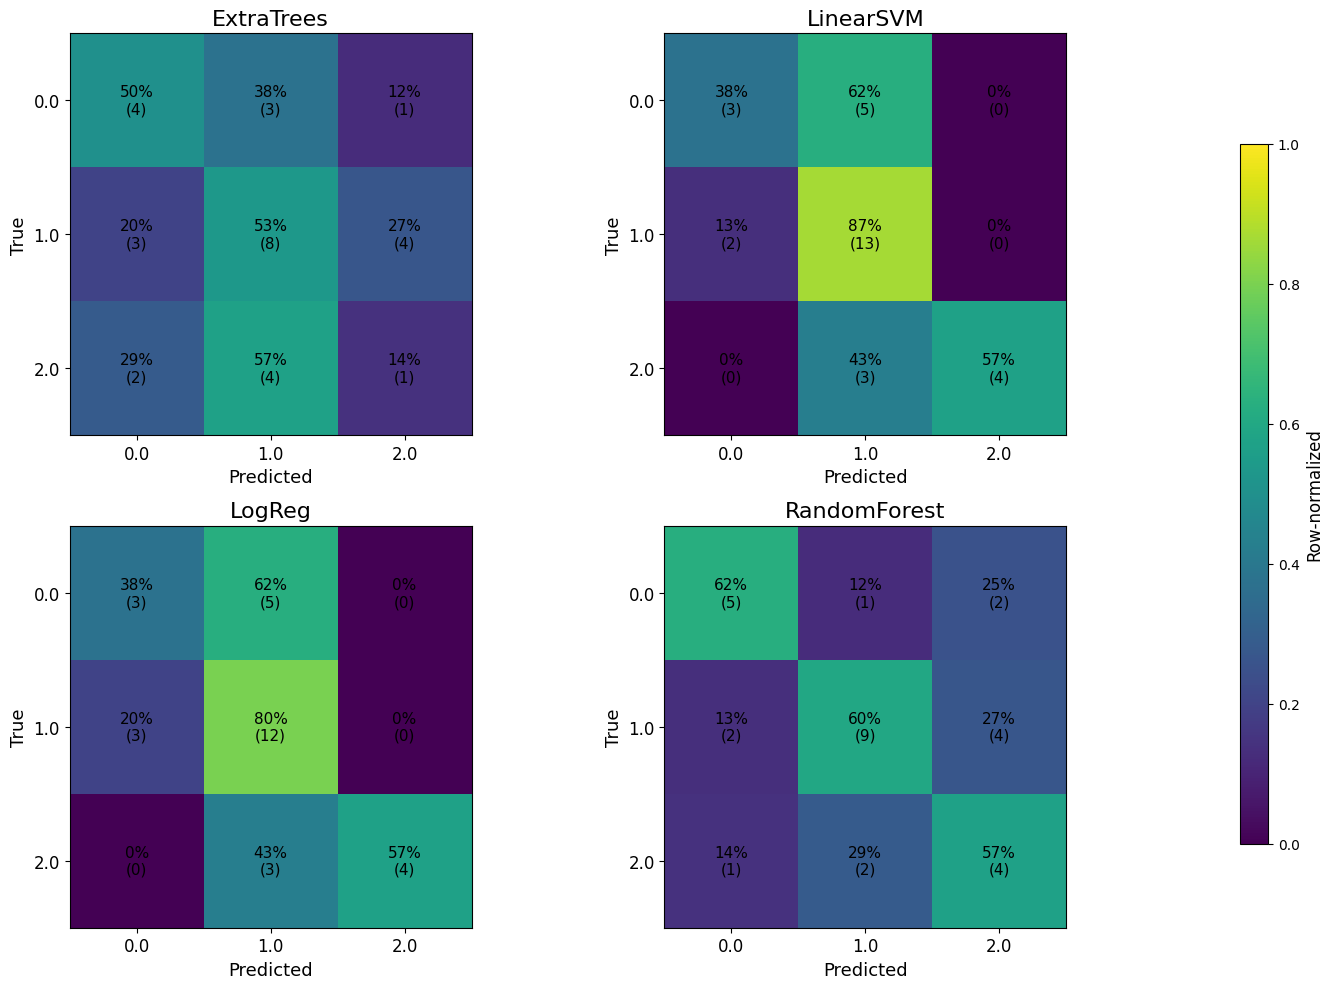

In [94]:


labels = np.sort(np.unique(np.concatenate([np.array(Y_c_test), np.array(Y_c_train)])))

# Use a larger canvas and reserve space on the right for the colorbar.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

last_im = None
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_c_test)

    cm = confusion_matrix(Y_c_test, y_pred, labels=labels)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    last_im = ax.imshow(cm_norm, vmin=0, vmax=1)

    ax.set_title(name, fontsize=16)
    ax.set_xlabel("Predicted", fontsize=13)
    ax.set_ylabel("True", fontsize=13)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_yticklabels(labels, fontsize=12)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{cm_norm[i, j]*100:.0f}%\n({cm[i, j]})",
                    ha="center", va="center", fontsize=11)

# Leave a right margin for the colorbar
plt.tight_layout(rect=[0, 0, 0.92, 1])

# Add a dedicated colorbar axis in that margin
cax = fig.add_axes([0.94, 0.15, 0.02, 0.70])  # [left, bottom, width, height]
cbar = fig.colorbar(last_im, cax=cax)
cbar.set_label("Row-normalized", fontsize=12)

plt.savefig(fig_path("confusion_matrices_models.png"), dpi=400, bbox_inches="tight")
plt.show()

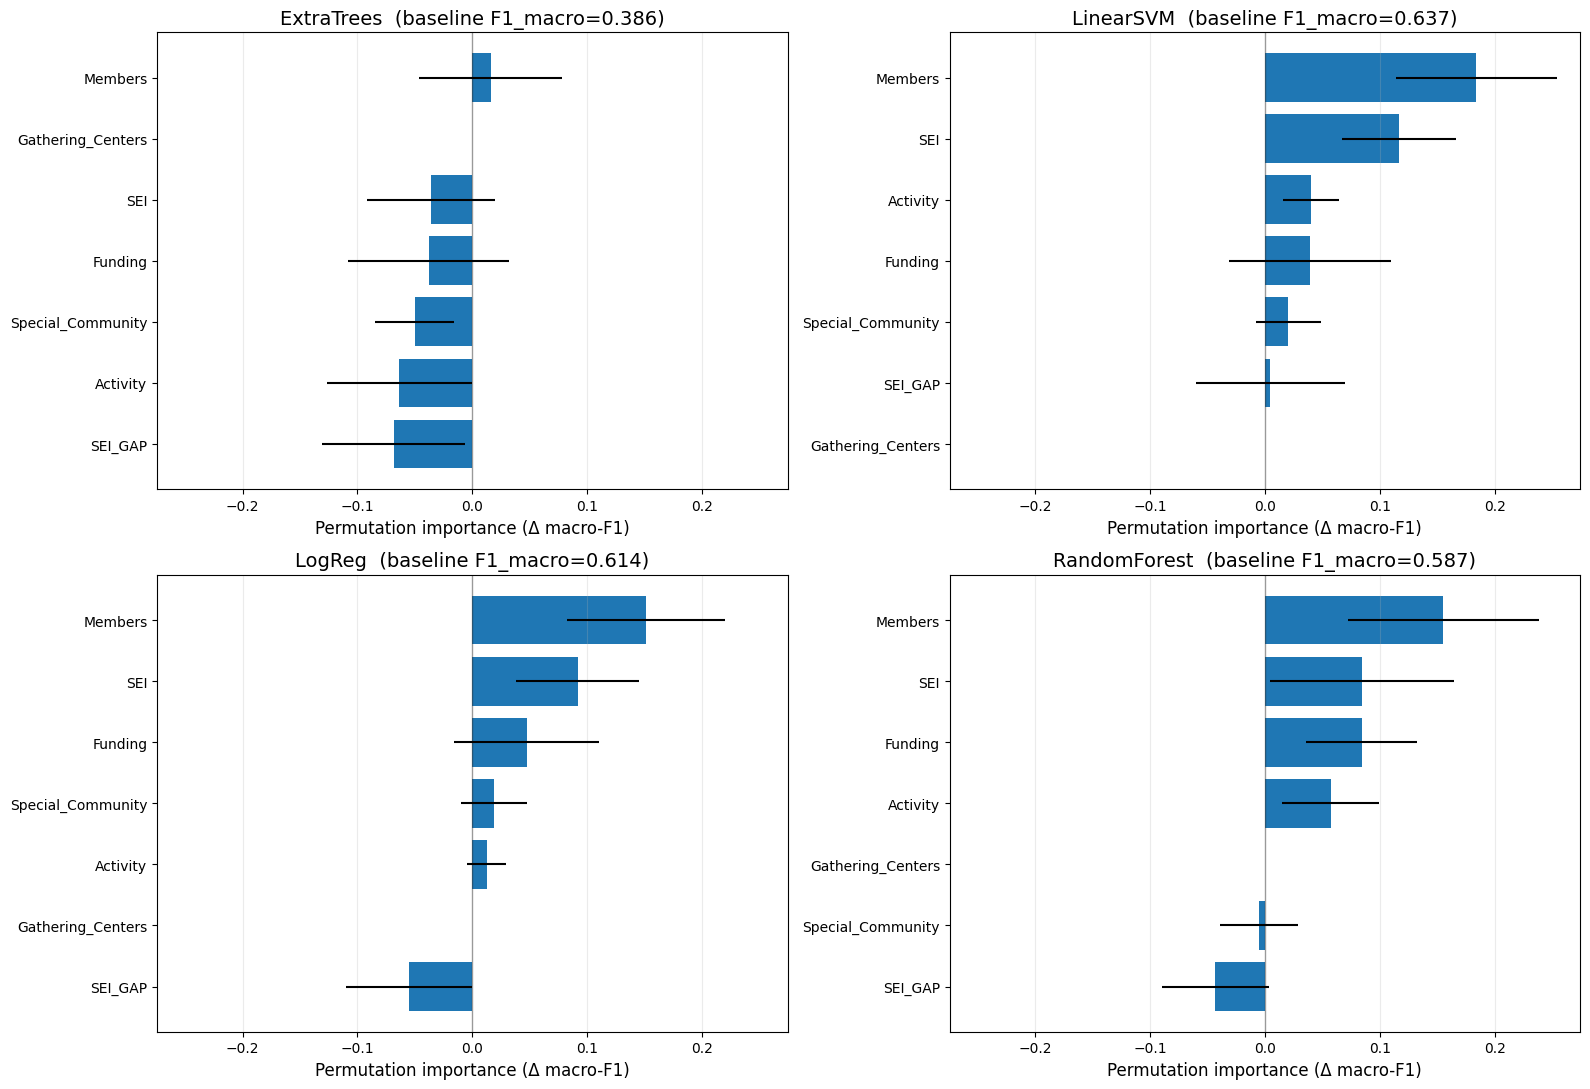

In [95]:



def feature_names(X):
    if hasattr(X, "columns"):
        return list(X.columns)
    return [f"f{i}" for i in range(X.shape[1])]

feat_names = feature_names(X_c_test)

TOP_K = 15
N_REPEATS = 25
SCORING = "f1_macro"

# =========================
# 1) Compute + store importances first
# =========================
plot_data = {}
global_min = 0.0
global_max = 0.0

for name, model in models.items():
    base_pred = model.predict(X_c_test)
    base_f1 = f1_score(Y_c_test, base_pred, average="macro")

    r = permutation_importance(
        model, X_c_test, Y_c_test,
        n_repeats=N_REPEATS,
        random_state=15,
        scoring=SCORING,
        n_jobs=-1
    )

    imp = r.importances_mean
    imp_std = r.importances_std

    idx = np.argsort(imp)[::-1][:TOP_K]
    imp_top = imp[idx]
    std_top = imp_std[idx]
    names_top = [feat_names[i] for i in idx]

    # store (keep descending; we'll reverse only for barh plotting)
    plot_data[name] = (names_top, imp_top, std_top, base_f1)

    # update global bounds (include error bars)
    global_min = min(global_min, float(np.min(imp_top - std_top)))
    global_max = max(global_max, float(np.max(imp_top + std_top)))

# Make symmetric scale around 0 (nice for comparing negatives/positives)
max_abs = max(abs(global_min), abs(global_max))
pad = 0.08 * max_abs if max_abs > 0 else 0.01
xlim = (-max_abs - pad, max_abs + pad)

# =========================
# 2) Plot with fixed xlim for all panels
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.ravel()

for ax, (name, (names_top, imp_top, std_top, base_f1)) in zip(axes, plot_data.items()):
    # reverse so the biggest is on top in barh
    names_plot = names_top[::-1]
    imp_plot = imp_top[::-1]
    std_plot = std_top[::-1]

    ax.barh(names_plot, imp_plot, xerr=std_plot)
    ax.axvline(0, color="black", lw=1, alpha=0.35)

    ax.set_xlim(*xlim)  # <-- SAME SCALE for everyone
    ax.set_title(f"{name}  (baseline F1_macro={base_f1:.3f})", fontsize=14)
    ax.set_xlabel("Permutation importance (Δ macro-F1)", fontsize=12)
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.savefig(fig_path("feature_importance_models.png"), dpi=400, bbox_inches="tight")
plt.show()

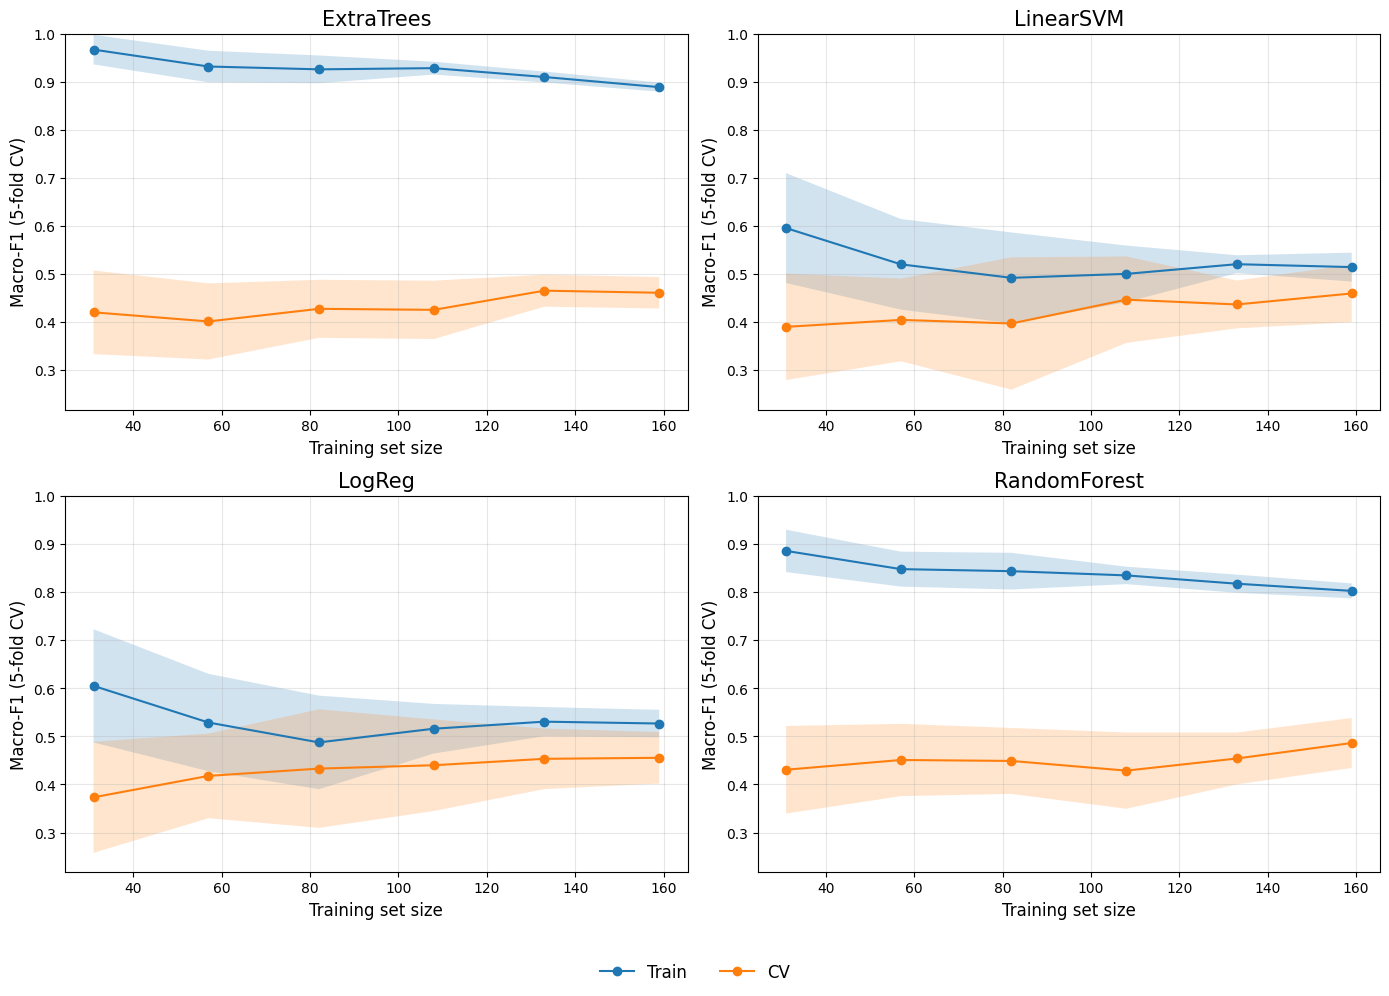

In [96]:

# =========================
# Re-estimate the models for the learning-curve analysis.
# =========================
models = {
    "ExtraTrees": ExtraTreesClassifier(random_state=15),
    "LinearSVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(random_state=15))
    ]),
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=15))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        random_state=15,
        class_weight="balanced",
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=13)
train_sizes = np.linspace(0.2, 1.0, 6)

# =========================
# 1) Compute curves first (to get global y-limits)
# =========================
curves = {}
global_min = np.inf
global_max = -np.inf

for name, model in models.items():
    ts, train_scores, cv_scores = learning_curve(
        estimator=model,
        X=X_clean,
        y=Y_clean,
        train_sizes=train_sizes,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        shuffle=True,
        random_state=13
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    cv_mean    = cv_scores.mean(axis=1)
    cv_std     = cv_scores.std(axis=1)

    curves[name] = (ts, train_mean, train_std, cv_mean, cv_std)

    global_min = min(global_min,
                     float(np.min(train_mean - train_std)),
                     float(np.min(cv_mean - cv_std)))
    global_max = max(global_max,
                     float(np.max(train_mean + train_std)),
                     float(np.max(cv_mean + cv_std)))

# nice padding + clamp to [0, 1]
pad = 0.04
ymin = max(0.0, global_min - pad)
ymax = min(1.0, global_max + pad)

# =========================
# 2) Plot with fixed y-limits
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (name, (ts, train_mean, train_std, cv_mean, cv_std)) in zip(axes, curves.items()):
    ax.plot(ts, train_mean, marker="o", label="Train")
    ax.plot(ts, cv_mean, marker="o", label="CV")
    ax.fill_between(ts, train_mean - train_std, train_mean + train_std, alpha=0.2)
    ax.fill_between(ts, cv_mean - cv_std, cv_mean + cv_std, alpha=0.2)

    ax.set_title(name, fontsize=15)
    ax.set_xlabel("Training set size", fontsize=12)
    ax.set_ylabel("Macro-F1 (5-fold CV)", fontsize=12)
    ax.set_ylim(ymin, ymax)          # <-- SAME SCALE
    ax.grid(alpha=0.3)

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, fontsize=12)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(fig_path("learning_curves_models.png"), dpi=400, bbox_inches="tight")
plt.show()